In [1]:
n_sigma_cut = 0.5 # main force for the PID

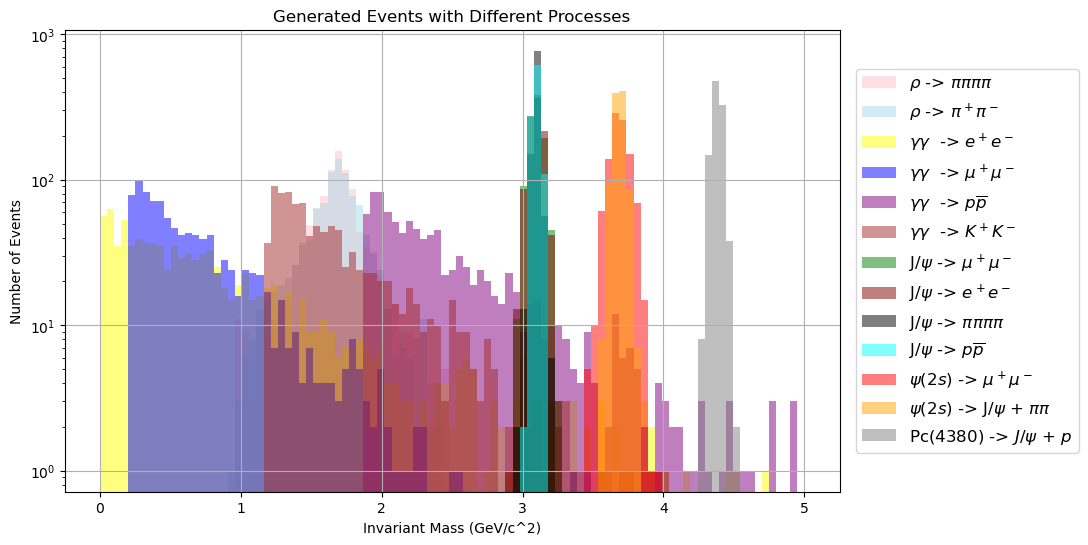

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Event generation parameters
n_photon_photon = 2144429
n_jpsi = 124800
n_psi2S_muons = 2320
n_psi2S_jpsi_pions = 2120
n_pq1 = 14
#n_pq2 = 25
n_pp_kaon = 16920
n_jpsi_protons = 2440
n_jpsi_4pi = 10330
#n_jpsi_3pi = 500
n_photon_photon_proton = 10840 
n_photon_photon_electron = 2971120
n_jpsi_electrons = 84640 #Run 3 & 4
n_rhoprime = 2886800
n_rho_4pi = 31950960

n_training= 10000

# Constants (GeV/c^2)
m_muon = 0.105658  # Muon mass
m_jpsi = 3.0969    # J/psi mass
m_psi2S = 3.6861   # Psi(2S) mass
m_pion = 0.13957   # Charged pion mass
m_proton= .938 
m_pentaquark= 4.38
m_electron= .0005
m_kaon= 0.49367
m_rho = 0.775
m_rho_prime = 1.465
m_rho_1700 = 1.7 

def isotropic_two_body_decay(mother_mass, daughter_mass1, daughter_mass2):
    E1 = (mother_mass**2 + daughter_mass1**2 - daughter_mass2**2) / (2 * mother_mass)
    E2 = (mother_mass**2 + daughter_mass2**2 - daughter_mass1**2) / (2 * mother_mass)
    p = np.sqrt(E1**2 - daughter_mass1**2)
    p = tpc_momentum_resolution(p)
    theta = np.arccos(2 * np.random.rand() - 1)
    phi = 2 * np.pi * np.random.rand()
    p1 = np.array([p * np.sin(theta) * np.cos(phi), p * np.sin(theta) * np.sin(phi), p * np.cos(theta)])
    p2 = -p1
    return p1, p2, E1, E2

def tpc_momentum_resolution(momentum):
    a = 0.005
    b = 0.01
    resolution = np.sqrt(a**2 + (b * momentum)**2)
    smeared_momentum = momentum * (1 + np.random.normal(0, resolution))
    return smeared_momentum

def generate_photon_photon_events(n_events):
    masses = np.random.exponential(0.5, n_events) + 2 * m_muon  # Invariant mass distribution
    events = []
    for mass in masses:
        smearedTracks = []
        muon1_p, muon2_p, _, _ = isotropic_two_body_decay(mass, m_muon, m_muon)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(muon1_p)
        smearedTracks.append(muon2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

def generate_jpsi_events(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        muon1_p, muon2_p, E1, E2 = isotropic_two_body_decay(m_jpsi, m_muon, m_muon)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(muon1_p)
        smearedTracks.append(muon2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

#NEW Rho Prime-------------------

def breit_wigner(m0, gamma, size=1):
    return m0 + 0.5 * gamma * np.tan(np.pi * (np.random.rand(size) - 0.5))

def relativistic_breit_wigner(m0, gamma, size=1):
    """
    Sample using relativistic Breit-Wigner:
    P(m) ∝ 1 / [(m^2 - m0^2)^2 + (m0 * gamma)^2]
    """
    m = np.zeros(size)
    for i in range(size):
        accepted = False
        while not accepted:
            # Sample uniformly in a window around the peak
            m_candidate = np.random.uniform(m0 - 3*gamma, m0 + 3*gamma)
            
            bw = 1.0 / ((m_candidate**2 - m0**2)**2 + (m0 * gamma)**2)
            bw_max = 1.0 / ((0)**2 + (m0 * gamma)**2)  # peak
            
            if np.random.rand() < bw / bw_max:
                m[i] = m_candidate
                accepted = True
    return m

def generate_rhoprime_events(n_events, m=1.7, gamma=0.250):
    events = []
    for _ in range(n_events):
        masses_rho_prime = relativistic_breit_wigner(m, gamma, size=1)[0]
        if masses_rho_prime < 2 * m_pion:
            continue
        pion1_p, pion2_p, E1, E2 = isotropic_two_body_decay(masses_rho_prime, m_pion, m_pion)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        events.append([pion1_p, pion2_p])
        # events.append(mass)
    return np.array(events)

def generate_psi2S_muons_events(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        muon1_p, muon2_p, _, _ = isotropic_two_body_decay(m_psi2S, m_muon, m_muon)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(muon1_p)
        smearedTracks.append(muon2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

def generate_psi2S_jpsi_pions_events(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        jpsi_p, pion_p, jpsi_E, pion_E = isotropic_two_body_decay(m_psi2S, m_jpsi, 2 * m_pion)
        muon1_p, muon2_p, muon1_E, muon2_E = isotropic_two_body_decay(m_jpsi, m_muon, m_muon)
        # jpsi_p = tpc_momentum_resolution(np.linalg.norm(jpsi_p))
        # pion_p = tpc_momentum_resolution(np.linalg.norm(pion_p))
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(muon1_p)
        smearedTracks.append(muon2_p)
        smearedTracks.append(pion_p)
        smearedTracks.append(pion_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

def generate_jpsi_protons_events(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        proton1_p, proton2_p, _, _ = isotropic_two_body_decay(m_jpsi, m_proton, m_proton)
        # proton1_p = tpc_momentum_resolution(np.linalg.norm(proton1_p))
        # proton2_p = tpc_momentum_resolution(np.linalg.norm(proton2_p))
        smearedTracks.append(proton1_p)
        smearedTracks.append(proton2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)
#generate_jpsi_protons_events(n_events)

#NEW jpsi->ee
def generate_jpsi_electrons_events(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        electron1_p, electron2_p, _, _ = isotropic_two_body_decay(m_jpsi, m_electron, m_electron)
        # proton1_p = tpc_momentum_resolution(np.linalg.norm(proton1_p))
        # proton2_p = tpc_momentum_resolution(np.linalg.norm(proton2_p))
        smearedTracks.append(electron1_p)
        smearedTracks.append(electron2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

def generate_pp_kaon_events(n_events):
    masses = np.random.exponential(0.5, n_events) + 2 * m_kaon + 0.2 # Invariant mass distribution
    events = []
    for mass in masses:
        smearedTracks = []
        pp_kaon1_p, pp_kaon2_p, _, _ = isotropic_two_body_decay(mass, m_kaon, m_kaon)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(pp_kaon1_p)
        smearedTracks.append(pp_kaon2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

#-----------New gamma + gamma -> proton + proton

def generate_photon_photon_proton_events(n_events):
    masses = np.random.exponential(0.595, n_events) + 2 * m_proton  # Invariant mass distribution
    events = []
    for mass in masses:
        smearedTracks = []
        proton1_p, proton2_p, _, _ = isotropic_two_body_decay(mass, m_proton, m_proton)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(proton1_p)
        smearedTracks.append(proton2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

#-----------New gamma + gamma -> electrons

def generate_photon_photon_electron_events(n_events):
    masses = np.random.exponential(0.925, n_events) + 2 * m_electron  # Invariant mass distribution
    events = []
    for mass in masses:
        smearedTracks = []
        electron1_p, electron2_p, _, _ = isotropic_two_body_decay(mass, m_electron, m_electron)
        # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
        # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
        smearedTracks.append(electron1_p)
        smearedTracks.append(electron2_p)
        events.append(smearedTracks)
        # events.append(mass)
    return np.array(events)

def isotropic_three_body_decay(mother_mass, daughter_mass1, daughter_mass2, daughter_mass3):
    """
    Simulates an isotropic three-body decay, distributing energy and momentum according to phase space constraints.
    Returns the momenta and energies of the three daughter particles.
    """
    # Total energy available for distribution after accounting for minimum required energy
    total_energy_available = (mother_mass - daughter_mass1 - daughter_mass2 - daughter_mass3)
    
    if total_energy_available <= 0:
        raise ValueError("Insufficient mass for a three-body decay.")

    # Randomly divide the available energy between the three daughters
    available_energy1 = np.random.uniform(0, total_energy_available)
    available_energy2 = np.random.uniform(0, total_energy_available - available_energy1)
    available_energy3 = total_energy_available - available_energy1 - available_energy2
    
    E1 = daughter_mass1 + available_energy1
    E2 = daughter_mass2 + available_energy2
    E3 = daughter_mass3 + available_energy3

    # Compute the momenta from the energies
    p1 = np.sqrt(E1**2 - daughter_mass1**2)
    p2 = np.sqrt(E2**2 - daughter_mass2**2)
    p3 = np.sqrt(E3**2 - daughter_mass3**2)
    
    # Random angles for isotropic decay
    theta1 = np.arccos(2 * np.random.rand() - 1)
    phi1 = 2 * np.pi * np.random.rand()
    
    theta2 = np.arccos(2 * np.random.rand() - 1)
    phi2 = 2 * np.pi * np.random.rand()
    
    # Calculate the momenta in 3D (isotropic decay)
    p1_vec = np.array([p1 * np.sin(theta1) * np.cos(phi1), p1 * np.sin(theta1) * np.sin(phi1), p1 * np.cos(theta1)])
    p2_vec = np.array([p2 * np.sin(theta2) * np.cos(phi2), p2 * np.sin(theta2) * np.sin(phi2), p2 * np.cos(theta2)])
    p3_vec = -p1_vec - p2_vec  # Momentum conservation
    
    return p1_vec, p2_vec, p3_vec, E1, E2, E3


def boost_to_lab_frame(momentum, boost_vector):
    """
    Boosts the momentum of a particle to the lab frame using the boost vector.
    """
    # Check if the boost vector is effectively zero (no boost needed)
    if np.linalg.norm(boost_vector) < 1e-10:
        print("error1")
        return momentum
    
    beta = boost_vector / np.linalg.norm(boost_vector)
    beta_norm_sq = np.linalg.norm(beta)**2
    
    # Ensure that beta_norm_sq < 1 (speed of light constraint)
    if beta_norm_sq >= 1.0:
        print("error2")
        return momentum  # No valid boost
    
    gamma = 1.0 / np.sqrt(1 - beta_norm_sq)
    dot_product = np.dot(momentum, beta)
    energy = np.sqrt(np.linalg.norm(momentum)**2 + m_muon**2)
    
    boosted_energy = gamma * (energy + dot_product)
    boosted_momentum = momentum + (gamma - 1) * dot_product / beta_norm_sq * beta + gamma * energy * beta
    
    return boosted_momentum

def boost_along_axis(momentum, beta, axis):
    """
    Boosts a particle along a single axis.
    
    Parameters:
    - momentum: 3D momentum vector of the particle to be boosted
    - beta: velocity (as a fraction of the speed of light) along the chosen axis
    - axis: axis along which to boost ('x', 'y', or 'z')
    
    Returns:
    - boosted_momentum: the 3D momentum vector after the boost along the given axis
    """
    if abs(beta) >= 1:
        print("error2")
        raise ValueError("Beta must be less than 1 for a valid boost.")
    
    gamma = 1.0 / np.sqrt(1 - beta**2)
    
    # Boost along the x-axis
    if axis == 'x':
        energy = np.sqrt(np.linalg.norm(momentum)**2 + m_muon**2)
        boosted_px = gamma * (momentum[0] + beta * energy)
        boosted_energy = gamma * (energy + beta * momentum[0])
        boosted_momentum = np.array([boosted_px, momentum[1], momentum[2]])
    
    # Boost along the y-axis
    elif axis == 'y':
        energy = np.sqrt(np.linalg.norm(momentum)**2 + m_muon**2)
        boosted_py = gamma * (momentum[1] + beta * energy)
        boosted_energy = gamma * (energy + beta * momentum[1])
        boosted_momentum = np.array([momentum[0], boosted_py, momentum[2]])
    
    # Boost along the z-axis
    elif axis == 'z':
        energy = np.sqrt(np.linalg.norm(momentum)**2 + m_muon**2)
        boosted_pz = gamma * (momentum[2] + beta * energy)
        boosted_energy = gamma * (energy + beta * momentum[2])
        boosted_momentum = np.array([momentum[0], momentum[1], boosted_pz])
    
    else:
        raise ValueError("Axis must be 'x', 'y', or 'z'.")
    
    return boosted_momentum, boosted_energy

def boost_to_lab_frame_separate(momentum, boost_vector):
    """
    Boosts the particle's 3D momentum vector using separate boosts along the x, y, and z axes.
    
    Parameters:
    - momentum: 3D momentum vector of the particle
    - boost_vector: 3D velocity vector (as a fraction of the speed of light)
    
    Returns:
    - boosted_momentum: the 3D momentum vector after boosting along x, y, and z
    """
    boosted_momentum = momentum
    # Boost along x
    boosted_momentum, _ = boost_along_axis(boosted_momentum, boost_vector[0], 'x')
    # Boost along y
    boosted_momentum, _ = boost_along_axis(boosted_momentum, boost_vector[1], 'y')
    # Boost along z
    boosted_momentum, _ = boost_along_axis(boosted_momentum, boost_vector[2], 'z')
    
    px, py, pz = boosted_momentum
    p_total = np.sqrt(px**2 + py**2 + pz**2)
    
    # Calculate new theta (polar angle)
    theta_prime = np.arccos(pz / p_total) if p_total > 0 else 0.0
    
    # Calculate new phi (azimuthal angle)
    phi_prime = np.arctan2(py, px)

    return boosted_momentum, theta_prime, phi_prime


def generate_psi2S_jpsi_pions_events_fixed(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
        jpsi_p, pion1_p, pion2_p, jpsi_E, pion1_E, pion2_E = isotropic_three_body_decay(m_psi2S, m_jpsi, m_pion, m_pion)
        
        # Step 2: J/psi -> 2 muons in the rest frame of J/psi
        muon1_p_rest, muon2_p_rest, _, _ = isotropic_two_body_decay(m_jpsi, m_muon, m_muon)
        
        # Boost the muons back to the lab frame using the momentum of the J/psi from Step 1
        muon1_p_lab = boost_to_lab_frame(muon1_p_rest, jpsi_p)
        muon2_p_lab = boost_to_lab_frame(muon2_p_rest, jpsi_p)
        
        smearedTracks.append(muon1_p_lab)
        smearedTracks.append(muon2_p_lab)
        smearedTracks.append(pion1_p)
        smearedTracks.append(pion2_p)
        events.append(smearedTracks)
    
    return np.array(events)

def isotropic_two_body_decay_no_smearing(mother_mass, daughter_mass1, daughter_mass2):
    """
    Isotropic two-body decay without smearing.
    """
    E1 = (mother_mass**2 + daughter_mass1**2 - daughter_mass2**2) / (2 * mother_mass)
    E2 = (mother_mass**2 + daughter_mass2**2 - daughter_mass1**2) / (2 * mother_mass)
    p = np.sqrt(E1**2 - daughter_mass1**2)
    
    theta = np.arccos(2 * np.random.rand() - 1)
    phi = 2 * np.pi * np.random.rand()
    p1 = np.array([p * np.sin(theta) * np.cos(phi), p * np.sin(theta) * np.sin(phi), p * np.cos(theta)])
    p2 = -p1
    return p1, p2, E1, E2

def tpc_momentum_resolution_3d(momentum_vec):
    """
    Applies TPC momentum resolution smearing to each component of the momentum vector.
    """
    smeared_momentum_vec = np.zeros(3)
    for i in range(3):
        momentum = momentum_vec[i]
        a = 0.005
        b = 0.01
        resolution = np.sqrt(a**2 + (b * momentum)**2)
        smeared_momentum_vec[i] = momentum * (1 + np.random.normal(0, resolution))
    return smeared_momentum_vec

def generate_psi2S_jpsi_pions_events_smearing_after_boost(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
        jpsi_p, pion1_p, pion2_p, jpsi_E, pion1_E, pion2_E = isotropic_three_body_decay(m_psi2S, m_jpsi, m_pion, m_pion)
        
        # Step 2: J/psi -> 2 muons in the rest frame of J/psi (without smearing)
        muon1_p_rest, muon2_p_rest, _, _ = isotropic_two_body_decay_no_smearing(m_jpsi, m_muon, m_muon)
        
        # Step 3: Boost the muons to the lab frame
        muon1_p_lab = boost_to_lab_frame(muon1_p_rest, jpsi_p)
        muon2_p_lab = boost_to_lab_frame(muon2_p_rest, jpsi_p)
        
        # Step 4: Apply smearing to the muons after boosting to the lab frame (component-wise)
        muon1_p_lab_smeared = tpc_momentum_resolution_3d(muon1_p_lab)
        muon2_p_lab_smeared = tpc_momentum_resolution_3d(muon2_p_lab)
        
        # Append the smeared muons and pions to the event
        smearedTracks.append(muon1_p_lab_smeared)
        smearedTracks.append(muon2_p_lab_smeared)
        smearedTracks.append(pion1_p)
        smearedTracks.append(pion2_p)
        events.append(smearedTracks)
    
    return np.array(events)

# def plot_event_distribution(events_photon_photon, events_jpsi, events_psi2S_muons, events_psi2S_jpsi_pions, events_jpsi_protons, events_pp_kaons, events_pq):
#     plt.figure(figsize=(10, 6))
#     bins = np.linspace(0, 5, 100)
#     plt.hist(events_photon_photon, bins, alpha=0.5, label='Photon+Photon -> 2 muons', color='blue')
#     plt.hist(events_jpsi, bins, alpha=0.5, label='J/psi -> 2 muons', color='green')
#     plt.hist(events_psi2S_muons, bins, alpha=0.5, label='psi(2S) -> 2 muons', color='red')
#     plt.hist(events_psi2S_jpsi_pions, bins, alpha=0.5, label='psi(2S) -> J/psi + 2 pions', color='orange')
#     plt.hist(events_jpsi_protons, bins, alpha=0.5, label='J/psi -> 2 protons', color='cyan')
#     plt.hist(events_pp_kaons, bins, alpha=0.5, label='Photon+Photon -> 2 kaons', color='brown')
#     plt.hist(events_pq, bins, alpha=0.5, label='pentaquark(2S) -> J/psi + 1 proton', color='gray')
#     plt.xlabel('Invariant Mass (GeV/c^2)')
#     plt.yscale('log')  # Log scale for y-axis
#     plt.ylabel('Number of Events')
#     plt.title('Generated Events with Different Processes')
#     plt.legend(loc='upper right')
#     plt.grid(True)
#     plt.show()

def plot_event_distribution(events_rho_4pions, events_rhoprime, events_photon_photon_electron, events_photon_photon, events_photon_photon_proton, events_pp_kaons, events_jpsi, events_jpsi_electrons, events_jpsi_4pions, events_jpsi_protons, events_psi2S_muons, events_psi2S_jpsi_pions, events_pq):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 5, 100)
    plt.hist(events_rho_4pions, bins, alpha=0.5, label=r'$\rho$ -> $\pi \pi \pi \pi$', color='pink')
    plt.hist(events_rhoprime, bins, alpha=0.5, label=r'$\rho$ -> $\pi^+ \pi^-$', color='lightblue')
    plt.hist(events_photon_photon_electron, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $e^+ e^-$', color='yellow')
    plt.hist(events_photon_photon, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $\mu^+ \mu^-$', color='blue')
    plt.hist(events_photon_photon_proton, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $p \overline{p}$', color='purple')
    plt.hist(events_pp_kaons, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $K^+ K^-$', color='brown')
    plt.hist(events_jpsi, bins, alpha=0.5, label=r'J/$\psi$ -> $\mu^+ \mu^-$', color='green')
    plt.hist(events_jpsi_electrons, bins, alpha=0.5, label=r'J/$\psi$ -> $e^+ e^-$', color='maroon')
    plt.hist(events_jpsi_4pions, bins, alpha=0.5, label=r'J/$\psi$ -> $\pi \pi \pi \pi$', color='black')
    plt.hist(events_jpsi_protons, bins, alpha=0.5, label=r'J/$\psi$ -> $p \overline{p}$', color='cyan')
    plt.hist(events_psi2S_muons, bins, alpha=0.5, label=r'$\psi(2s)$ -> $\mu^+ \mu^-$', color='red')
    plt.hist(events_psi2S_jpsi_pions, bins, alpha=0.5, label=r'$\psi(2s)$ -> J/$\psi$ + $\pi \pi$', color='orange')
    plt.hist(events_pq, bins, alpha=0.5, label=r'Pc(4380) -> $J/ \psi$ + $p$', color='gray')

    plt.xlabel('Invariant Mass (GeV/c^2)')
    plt.yscale('log')  # Log scale for y-axis
    plt.ylabel('Number of Events')
    plt.title('Generated Events with Different Processes')
    plt.savefig('all_final_masses.pdf')
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),   # 1.02 pushes it just outside the right edge
        fancybox=True,
        shadow=False,
        ncol=1,                       # vertical list (recommended for side placement)
        fontsize=12,
        markerscale=1.3
    )
    #plt.legend(loc='upper right', fontsize = 10)
    plt.grid(True)
    plt.show()

#plt.rcParams.update({'font.size': 15})


def compute_invariant_mass(tracks):
    total_energy = 0
    total_momentum = np.array([0.0, 0.0, 0.0])
    count = 0
    for track in tracks:
        count += 1
        momentum = np.array(track)  # Track is just a momentum array (3-momentum)
        mass = m_muon  # We assume all tracks are muons, adjust as needed for pions etc.
        if count > 2:
            mass = m_pion

        energy = np.sqrt(np.linalg.norm(momentum)**2 + mass**2)  # Total energy of the track
        total_energy += energy
        total_momentum += momentum
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared >= 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_kaon(tracks):
    total_energy = 0
    total_momentum = np.array([0.0, 0.0, 0.0])
    count = 0
    for track in tracks:
        count += 1
        momentum = np.array(track)  # Track is just a momentum array (3-momentum)
        mass = m_kaon  # We assume all tracks are muons, adjust as needed for pions etc.
        if count > 2:
            mass = m_pion

        energy = np.sqrt(np.linalg.norm(momentum)**2 + mass**2)  # Total energy of the track
        total_energy += energy
        total_momentum += momentum
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared >= 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_jpsi_proton(tracks):
    total_energy = 0
    total_momentum = np.array([0.0, 0.0, 0.0])
    count = 0
    for track in tracks:
        count += 1
        momentum = np.array(track)  # Track is just a momentum array (3-momentum)
        mass = m_proton  # We assume all tracks are muons, adjust as needed for pions etc.
        if count > 2:
            mass = m_pion

        energy = np.sqrt(np.linalg.norm(momentum)**2 + mass**2)  # Total energy of the track
        total_energy += energy
        total_momentum += momentum
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared >= 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_electron(tracks):
    total_energy = 0
    total_momentum = np.array([0.0, 0.0, 0.0])
    count = 0
    for track in tracks:
        count += 1
        momentum = np.array(track)  # Track is just a momentum array (3-momentum)
        mass = m_electron  # We assume all tracks are muons, adjust as needed for pions etc.
        if count > 2:
            mass = m_pion

        energy = np.sqrt(np.linalg.norm(momentum)**2 + mass**2)  # Total energy of the track
        total_energy += energy
        total_momentum += momentum
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared >= 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_pion(tracks):
    total_energy = 0
    total_momentum = np.array([0.0, 0.0, 0.0])
    count = 0
    for track in tracks:
        count += 1
        momentum = np.array(track)  # Track is just a momentum array (3-momentum)
        mass = m_pion  # We assume all tracks are muons, adjust as needed for pions etc.
        if count > 2:
            mass = m_pion

        energy = np.sqrt(np.linalg.norm(momentum)**2 + mass**2)  # Total energy of the track
        total_energy += energy
        total_momentum += momentum
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared >= 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_masses_for_events_jpsi_proton(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_jpsi_proton(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events_kaon(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_kaon(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events_pion(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_pion(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events_electron(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_electron(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events(events):
    """
    Computes the invariant mass for a list of events, where each event contains a list of tracks.
    
    Parameters:
    - events: A list of events, where each event is a list of tracks.
              Each track is a dictionary containing:
              - 'momentum': a numpy array representing the 3-momentum of the track
              - 'mass': the mass of the particle
    
    Returns:
    - invariant_masses: A list of invariant masses, one for each event.
    """
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def isotropic_two_body_decay_with_angles(mother_mass, daughter_mass1, daughter_mass2):
    """
    Isotropic two-body decay with angle saving (theta, phi).
    Returns momenta, energies, and angles.
    """
    E1 = (mother_mass**2 + daughter_mass1**2 - daughter_mass2**2) / (2 * mother_mass)
    E2 = (mother_mass**2 + daughter_mass2**2 - daughter_mass1**2) / (2 * mother_mass)
    p = np.sqrt(E1**2 - daughter_mass1**2)
    
    theta = np.arccos(2 * np.random.rand() - 1)
    phi = 2 * np.pi * np.random.rand()
    p1 = np.array([p * np.sin(theta) * np.cos(phi), p * np.sin(theta) * np.sin(phi), p * np.cos(theta)])
    p2 = -p1
    
    return p1, p2, E1, E2, theta, phi

def reconstruct_3d_momentum(smeared_p, theta, phi):
    """
    Reconstructs the 3D momentum components using the smeared momentum magnitude and saved angles (theta, phi).
    """
    px = smeared_p * np.sin(theta) * np.cos(phi)
    py = smeared_p * np.sin(theta) * np.sin(phi)
    pz = smeared_p * np.cos(theta)
    
    return np.array([px, py, pz])

def calculate_boost_vector(momentum, energy):
    """
    Calculates the velocity (beta) from the momentum and energy to be used as the boost vector.
    
    Parameters:
    - momentum: 3D momentum vector of the particle
    - energy: total energy of the particle
    
    Returns:
    - beta: 3D velocity vector (beta = p / E)
    """
    beta = momentum / energy
    return beta

def generate_psi2S_jpsi_pions_events_smearing_after_boost_with_angles(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
        jpsi_p, pion1_p, pion2_p, jpsi_E, pion1_E, pion2_E = isotropic_three_body_decay(m_psi2S, m_jpsi, m_pion, m_pion)
        
        # Step 2: J/psi -> 2 muons in the rest frame of J/psi (with angles saved)
        muon1_p_rest, muon2_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_jpsi, m_muon, m_muon)
        
        # Step 3: Boost the muons to the lab frame
        boost_vector = calculate_boost_vector(jpsi_p, jpsi_E)

        muon1_p_lab, theta_prime, phi_prime = boost_to_lab_frame_separate(muon1_p_rest, boost_vector)
        muon2_p_lab, theta_second, phi_second = boost_to_lab_frame_separate(muon2_p_rest, boost_vector)
        
        # Step 4: Apply smearing to the momentum magnitudes only (not components yet)
        smeared_muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p_lab))
        smeared_muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p_lab))

        
        # Step 5: Reconstruct the 3D momenta using the smeared magnitude and original angles
        muon1_p_lab_smeared = reconstruct_3d_momentum(smeared_muon1_p, theta_prime, phi_prime) #<- correct
        muon2_p_lab_smeared = reconstruct_3d_momentum(smeared_muon2_p, theta_second, phi_second) #<- correct
        
        # Append the smeared muons and pions to the event
        smearedTracks.append(muon1_p_lab_smeared)
        smearedTracks.append(muon2_p_lab_smeared)
        smearedTracks.append(pion1_p)
        smearedTracks.append(pion2_p)
        smearedTracks.append(np.sqrt(np.linalg.norm(smeared_muon1_p)**2 + m_muon*m_muon))
        smearedTracks.append(np.sqrt(np.linalg.norm(smeared_muon2_p)**2 + m_muon*m_muon))
        smearedTracks.append(pion1_E)
        smearedTracks.append(pion2_E)

        # events.append([muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, pion1_E, pion2_E, pion1_E, pion2_E])
        events.append(smearedTracks)
    
    return events
    # return np.array(events)


def generate_pentaquark_jpsi_muons_events_smearing_after_boost_with_angles(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
        jpsi_p, proton_p, jpsi_E, proton_E = isotropic_two_body_decay(m_pentaquark, m_jpsi, m_proton)
        
        # Step 2: J/psi -> 2 muons in the rest frame of J/psi (with angles saved)
        muon1_p_rest, muon2_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_jpsi, m_muon, m_muon)
        
        # Step 3: Boost the muons to the lab frame
        boost_vector = calculate_boost_vector(jpsi_p, jpsi_E)

        muon1_p_lab, theta_prime, phi_prime = boost_to_lab_frame_separate(muon1_p_rest, boost_vector)
        muon2_p_lab, theta_second, phi_second = boost_to_lab_frame_separate(muon2_p_rest, boost_vector)
        
        # Step 4: Apply smearing to the momentum magnitudes only (not components yet)
        smeared_muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p_lab))
        smeared_muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p_lab))

        # Step 5: Reconstruct the 3D momenta using the smeared magnitude and original angles
        muon1_p_lab_smeared = reconstruct_3d_momentum(smeared_muon1_p, theta_prime, phi_prime) #<- correct
        muon2_p_lab_smeared = reconstruct_3d_momentum(smeared_muon2_p, theta_second, phi_second) #<- correct
        
        # Append the smeared muons and pions to the event
        smearedTracks.append(muon1_p_lab_smeared)
        smearedTracks.append(muon2_p_lab_smeared)
        smearedTracks.append(proton_p)
        smearedTracks.append(np.sqrt(np.linalg.norm(smeared_muon1_p)**2 + m_muon*m_muon))
        smearedTracks.append(np.sqrt(np.linalg.norm(smeared_muon2_p)**2 + m_muon*m_muon))
        smearedTracks.append(proton_E)

        # events.append([muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, pion1_E, pion2_E, pion1_E, pion2_E])
        events.append(smearedTracks)
    
    return events
#generate_pentaquark_jpsi_muons_events_smearing_after_boost_with_angles(n_pentaquark)

# def generate_jpsi_four_pions(n_events):
#     events = []
#     for _ in range(n_events):
#         smearedTracks = []
        
#         # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
#         jpsi_p, pion1_p, pion2_p, jpsi_E, pion1_E, pion2_E = isotropic_three_body_decay(m_jpsi, m_rho, m_pion, m_pion)
        
#         # Step 2: J/psi -> 2 muons in the rest frame of J/psi (with angles saved)
#         pion3_p_rest, pion4_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_rho, m_pion, m_pion)
        
#         # Step 3: Boost the muons to the lab frame
#         boost_vector = calculate_boost_vector(jpsi_p, jpsi_E)

#         pion3_p_lab, theta_prime, phi_prime = boost_to_lab_frame_separate(pion3_p_rest, boost_vector)
#         pion4_p_lab, theta_second, phi_second = boost_to_lab_frame_separate(pion4_p_rest, boost_vector)
        
#         # Step 4: Apply smearing to the momentum magnitudes only (not components yet)
#         smeared_pion3_p = tpc_momentum_resolution(np.linalg.norm(pion3_p_lab))
#         smeared_pion4_p = tpc_momentum_resolution(np.linalg.norm(pion4_p_lab))

        
#         # Step 5: Reconstruct the 3D momenta using the smeared magnitude and original angles
#         smeared_pion3_p_lab = reconstruct_3d_momentum(smeared_pion3_p, theta_prime, phi_prime) #<- correct
#         smeared_pion4_p_lab = reconstruct_3d_momentum(smeared_pion4_p, theta_second, phi_second) #<- correct
        
#         # Append the smeared muons and pions to the event
#         smearedTracks.append(smeared_pion3_p_lab)
#         smearedTracks.append(smeared_pion4_p_lab)
#         smearedTracks.append(pion1_p)
#         smearedTracks.append(pion2_p)
#         smearedTracks.append(np.sqrt(np.linalg.norm(smeared_pion3_p_lab)**2 + m_pion*m_pion))
#         smearedTracks.append(np.sqrt(np.linalg.norm(smeared_pion4_p_lab)**2 + m_pion*m_pion))
#         smearedTracks.append(pion1_E)
#         smearedTracks.append(pion2_E)

#         # events.append([muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, pion1_E, pion2_E, pion1_E, pion2_E])
#         events.append(smearedTracks)
    
#     return events

def lorentz_boost(p_vec, mass, beta):
    """
    Boosts a particle's 4-vector from its rest frame to the lab frame using a Lorentz transformation.
    
    Parameters:
      p_vec: 3D numpy array of the particle's momentum in the rest frame.
      mass: Mass of the particle.
      beta: 3D numpy array representing the boost velocity vector (v/c). Its norm must be less than 1.
    
    Returns:
      E_prime: Boosted energy.
      p_prime: Boosted 3-momentum (numpy array).
    """
    beta2 = np.dot(beta, beta)
    if beta2 >= 1:
        raise ValueError("Beta must be less than 1.")
    gamma = 1.0 / np.sqrt(1 - beta2)
    # Energy in the particle's rest frame (before boost)
    E = np.sqrt(np.linalg.norm(p_vec)**2 + mass**2)
    p_dot_beta = np.dot(p_vec, beta)
    # Lorentz transformation for the time component
    E_prime = gamma * (E + p_dot_beta)
    # Lorentz transformation for the spatial part
    p_prime = p_vec + ((gamma - 1) * p_dot_beta / beta2 + gamma * E) * beta
    return E_prime, p_prime

def generate_jpsi_four_pions(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: J/ψ decays to ρ + 2 pions (three-body decay)
        # Here, the first daughter is interpreted as the ρ.
        # The decay returns: [rho momentum, pion1 momentum, pion2 momentum, rho energy, pion1 energy, pion2 energy]
        rho_p, pion1_p, pion2_p, rho_E, pion1_E, pion2_E = isotropic_three_body_decay(m_jpsi, m_rho, m_pion, m_pion)
        
        # Step 2: ρ decays to two pions in its rest frame (with angles saved).
        # Here, we generate the two pions from the ρ decay in the ρ rest frame.
        pion3_p_rest, pion4_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_rho, m_pion, m_pion)
        
        # Step 3: Compute the boost vector for the ρ.
        # Use the ρ's lab momentum and energy to get the velocity: beta = p/E.
        beta = rho_p / rho_E
        
        # Step 4: Boost the ρ decay products using the new Lorentz boost function.
        # This will naturally accelerate one pion (if its momentum is aligned with beta)
        # and decelerate the other (if anti-aligned).
        E3_lab, pion3_p_lab = lorentz_boost(pion3_p_rest, m_pion, beta)
        E4_lab, pion4_p_lab = lorentz_boost(pion4_p_rest, m_pion, beta)
        
        # Step 5: Optionally apply momentum smearing (if desired) to the boosted momenta.
        # Here we smear only the magnitude and then reconstruct the 3D vector with the same direction.
        p3_lab_mag = np.linalg.norm(pion3_p_lab)
        p4_lab_mag = np.linalg.norm(pion4_p_lab)
        smeared_p3_mag = tpc_momentum_resolution(p3_lab_mag)
        smeared_p4_mag = tpc_momentum_resolution(p4_lab_mag)
        
        # Obtain the angles from the boosted momentum
        theta3 = np.arccos(pion3_p_lab[2] / p3_lab_mag) if p3_lab_mag > 0 else 0.0
        phi3 = np.arctan2(pion3_p_lab[1], pion3_p_lab[0])
        theta4 = np.arccos(pion4_p_lab[2] / p4_lab_mag) if p4_lab_mag > 0 else 0.0
        phi4 = np.arctan2(pion4_p_lab[1], pion4_p_lab[0])
        
        # Reconstruct the smeared momentum vectors with the same directions.
        smeared_pion3_p_lab = reconstruct_3d_momentum(smeared_p3_mag, theta3, phi3)
        smeared_pion4_p_lab = reconstruct_3d_momentum(smeared_p4_mag, theta4, phi4)
        
        # Recalculate energies for the smeared momenta (using pion mass)
        E3_smeared = np.sqrt(np.linalg.norm(smeared_pion3_p_lab)**2 + m_pion**2)
        E4_smeared = np.sqrt(np.linalg.norm(smeared_pion4_p_lab)**2 + m_pion**2)
        
        # Step 6: Construct the final event.
        # Final state: the two pions from the ρ decay (smeared) and the two pions directly from the three-body decay.
        # Also, keep the energy values for invariant mass reconstruction.
        # The event list is organized as: [pion3_lab (smeared), pion4_lab (smeared), pion1 (from three-body), pion2 (from three-body),
        #                                 E3_smeared, E4_smeared, pion1_E, pion2_E]
        smearedTracks.extend([smeared_pion3_p_lab, smeared_pion4_p_lab, pion1_p, pion2_p,
                              E3_smeared, E4_smeared, pion1_E, pion2_E])
        events.append(smearedTracks)
    
    return events


def generate_rho_four_pions(n_events, m=1.7, gamma=0.250):
    events = []
    for _ in range(n_events):
        masses_rho_prime = relativistic_breit_wigner(m, gamma, size=1)[0]
        if masses_rho_prime < 2 * m_pion:
            continue
        smearedTracks = []
        # Step 1: J/ψ decays to ρ + 2 pions (three-body decay)
        # Here, the first daughter is interpreted as the ρ.
        # The decay returns: [rho momentum, pion1 momentum, pion2 momentum, rho energy, pion1 energy, pion2 energy]
        rho_p, pion1_p, pion2_p, rho_E, pion1_E, pion2_E = isotropic_three_body_decay(m_rho_1700, m_rho, m_pion, m_pion)
        
        # Step 2: ρ decays to two pions in its rest frame (with angles saved).
        # Here, we generate the two pions from the ρ decay in the ρ rest frame.
        pion3_p_rest, pion4_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_rho, m_pion, m_pion)
        
        # Step 3: Compute the boost vector for the ρ.
        # Use the ρ's lab momentum and energy to get the velocity: beta = p/E.
        beta = rho_p / rho_E
        
        # Step 4: Boost the ρ decay products using the new Lorentz boost function.
        # This will naturally accelerate one pion (if its momentum is aligned with beta)
        # and decelerate the other (if anti-aligned).
        E3_lab, pion3_p_lab = lorentz_boost(pion3_p_rest, m_pion, beta)
        E4_lab, pion4_p_lab = lorentz_boost(pion4_p_rest, m_pion, beta)
        
        # Step 5: Optionally apply momentum smearing (if desired) to the boosted momenta.
        # Here we smear only the magnitude and then reconstruct the 3D vector with the same direction.
        p3_lab_mag = np.linalg.norm(pion3_p_lab)
        p4_lab_mag = np.linalg.norm(pion4_p_lab)
        smeared_p3_mag = tpc_momentum_resolution(p3_lab_mag)
        smeared_p4_mag = tpc_momentum_resolution(p4_lab_mag)
        
        # Obtain the angles from the boosted momentum
        theta3 = np.arccos(pion3_p_lab[2] / p3_lab_mag) if p3_lab_mag > 0 else 0.0
        phi3 = np.arctan2(pion3_p_lab[1], pion3_p_lab[0])
        theta4 = np.arccos(pion4_p_lab[2] / p4_lab_mag) if p4_lab_mag > 0 else 0.0
        phi4 = np.arctan2(pion4_p_lab[1], pion4_p_lab[0])
        
        # Reconstruct the smeared momentum vectors with the same directions.
        smeared_pion3_p_lab = reconstruct_3d_momentum(smeared_p3_mag, theta3, phi3)
        smeared_pion4_p_lab = reconstruct_3d_momentum(smeared_p4_mag, theta4, phi4)
        
        # Recalculate energies for the smeared momenta (using pion mass)
        E3_smeared = np.sqrt(np.linalg.norm(smeared_pion3_p_lab)**2 + m_pion**2)
        E4_smeared = np.sqrt(np.linalg.norm(smeared_pion4_p_lab)**2 + m_pion**2)
        
        # Step 6: Construct the final event.
        # Final state: the two pions from the ρ decay (smeared) and the two pions directly from the three-body decay.
        # Also, keep the energy values for invariant mass reconstruction.
        # The event list is organized as: [pion3_lab (smeared), pion4_lab (smeared), pion1 (from three-body), pion2 (from three-body),
        #                                 E3_smeared, E4_smeared, pion1_E, pion2_E]
        # smearedTracks.extend([smeared_pion3_p_lab, smeared_pion4_p_lab, pion1_p, pion2_p,
        #                       E3_smeared, E4_smeared, pion1_E, pion2_E])
        # events.append(smearedTracks)
        # events.append([smeared_pion3_p_lab, smeared_pion4_p_lab, pion1_p, pion2_p, E3_smeared, E4_smeared, pion1_E, pion2_E])
        # return np.array(events)


        smearedTracks.extend([smeared_pion3_p_lab, smeared_pion4_p_lab, pion1_p, pion2_p,
                              E3_smeared, E4_smeared, pion1_E, pion2_E])
        events.append(smearedTracks)
    
    return events


    # def generate_rhoprime_events(n_events, m=1.7, gamma=0.250):
    # events = []
    # for _ in range(n_events):
    #     masses_rho_prime = relativistic_breit_wigner(m, gamma, size=1)[0]
    #     if masses_rho_prime < 2 * m_pion:
    #         continue
    #     pion1_p, pion2_p, E1, E2 = isotropic_two_body_decay(masses_rho_prime, m_pion, m_pion)
    #     # muon1_p = tpc_momentum_resolution(np.linalg.norm(muon1_p))
    #     # muon2_p = tpc_momentum_resolution(np.linalg.norm(muon2_p))
    #     events.append([pion1_p, pion2_p])
    #     # events.append(mass)
    # return np.array(events)

def generate_psi2S_jpsi_pions_events_new(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
        jpsi_p, pion1_p, pion2_p, jpsi_E, pion1_E, pion2_E = isotropic_three_body_decay(m_psi2S, m_jpsi, m_pion, m_pion)
        
        # Step 2: J/psi -> 2 muons in the rest frame of J/psi (with angles saved)
        muon1_p_rest, muon2_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_jpsi, m_muon, m_muon)
        
        beta = jpsi_p / jpsi_E

        E1_lab, muon1_p_lab = lorentz_boost(muon1_p_rest, m_muon, beta)
        E2_lab, muon2_p_lab = lorentz_boost(muon2_p_rest, m_muon, beta)

        p1_lab_mag = np.linalg.norm(muon1_p_lab)
        p2_lab_mag = np.linalg.norm(muon2_p_lab)
        smeared_p1_mag = tpc_momentum_resolution(p1_lab_mag)
        smeared_p2_mag = tpc_momentum_resolution(p2_lab_mag)

        theta1 = np.arccos(muon1_p_lab[2] / p1_lab_mag) if p1_lab_mag > 0 else 0.0
        phi1 = np.arctan2(muon1_p_lab[1], muon1_p_lab[0])
        theta2 = np.arccos(muon2_p_lab[2] / p2_lab_mag) if p2_lab_mag > 0 else 0.0
        phi2 = np.arctan2(muon2_p_lab[1], muon2_p_lab[0])

        smeared_muon1_p_lab = reconstruct_3d_momentum(smeared_p1_mag, theta1, phi1)
        smeared_muon2_p_lab = reconstruct_3d_momentum(smeared_p2_mag, theta2, phi2)

        E1_smeared = np.sqrt(np.linalg.norm(smeared_muon1_p_lab)**2 + m_muon**2)
        E2_smeared = np.sqrt(np.linalg.norm(smeared_muon2_p_lab)**2 + m_muon**2)

        smearedTracks.extend([smeared_muon1_p_lab, smeared_muon2_p_lab, pion1_p, pion2_p,
                              E1_smeared, E2_smeared, pion1_E, pion2_E])
        events.append(smearedTracks)
    
    return events


def generate_pentaquark_events_new(n_events):
    events = []
    for _ in range(n_events):
        smearedTracks = []
        
        # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
        jpsi_p, proton_p, jpsi_E, proton_E = isotropic_two_body_decay(m_pentaquark, m_jpsi, m_proton)
        
        # Step 2: J/psi -> 2 muons in the rest frame of J/psi (with angles saved)
        muon1_p_rest, muon2_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_jpsi, m_muon, m_muon)
        
        # Step 3: Boost the muons to the lab frame
        beta = jpsi_p / jpsi_E

        E1_lab, muon1_p_lab = lorentz_boost(muon1_p_rest, m_muon, beta)
        E2_lab, muon2_p_lab = lorentz_boost(muon2_p_rest, m_muon, beta)

        p1_lab_mag = np.linalg.norm(muon1_p_lab)
        p2_lab_mag = np.linalg.norm(muon2_p_lab)
        smeared_p1_mag = tpc_momentum_resolution(p1_lab_mag)
        smeared_p2_mag = tpc_momentum_resolution(p2_lab_mag)

        theta1 = np.arccos(muon1_p_lab[2] / p1_lab_mag) if p1_lab_mag > 0 else 0.0
        phi1 = np.arctan2(muon1_p_lab[1], muon1_p_lab[0])
        theta2 = np.arccos(muon2_p_lab[2] / p2_lab_mag) if p2_lab_mag > 0 else 0.0
        phi2 = np.arctan2(muon2_p_lab[1], muon2_p_lab[0])

        smeared_muon1_p_lab = reconstruct_3d_momentum(smeared_p1_mag, theta1, phi1)
        smeared_muon2_p_lab = reconstruct_3d_momentum(smeared_p2_mag, theta2, phi2)

        E1_smeared = np.sqrt(np.linalg.norm(smeared_muon1_p_lab)**2 + m_muon**2)
        E2_smeared = np.sqrt(np.linalg.norm(smeared_muon2_p_lab)**2 + m_muon**2)

        smearedTracks.extend([smeared_muon1_p_lab, smeared_muon2_p_lab, proton_p,
                              E1_smeared, E2_smeared, proton_E])
        events.append(smearedTracks)
    
    return events


# def generate_jpsi_3pions_events(n_events):
#     events = []
#     for _ in range(n_events):
#         smearedTracks = []
        
#         # Step 1: psi(2S) -> J/psi + 2 charged pions (3-body decay)
#         rho_p, pion1_p, rho_E, pion1_E = isotropic_two_body_decay(m_jpsi, m_rho, m_pion)
        
#         # Step 2: J/psi -> 2 muons in the rest frame of J/psi (with angles saved)
#         pion2_p_rest, pion3_p_rest, _, _, theta1, phi1 = isotropic_two_body_decay_with_angles(m_rho, m_pion, m_pion)
        
#         # Step 3: Boost the muons to the lab frame
#         boost_vector = calculate_boost_vector(rho_p, rho_E)

#         pion2_p_lab, theta_prime, phi_prime = boost_to_lab_frame_separate(pion2_p_rest, boost_vector)
#         pion3_p_lab, theta_second, phi_second = boost_to_lab_frame_separate(pion3_p_rest, boost_vector)
        
#         smeared_pion2_p = tpc_momentum_resolution(np.linalg.norm(pion2_p_lab))
#         smeared_pion3_p = tpc_momentum_resolution(np.linalg.norm(pion3_p_lab))

#         # Step 5: Reconstruct the 3D momenta using the smeared magnitude and original angles
#         pion2_p_lab_smeared = reconstruct_3d_momentum(smeared_pion2_p, theta_prime, phi_prime) #<- correct
#         pion3_p_lab_smeared = reconstruct_3d_momentum(smeared_pion3_p, theta_second, phi_second) #<- correct
        
#         # Append the smeared muons and pions to the event
#         smearedTracks.append(pion2_p_lab_smeared)
#         smearedTracks.append(pion3_p_lab_smeared)
#         smearedTracks.append(pion1_p)
#         smearedTracks.append(np.sqrt(np.linalg.norm(smeared_pion2_p)**2 + m_pion*m_pion))
#         smearedTracks.append(np.sqrt(np.linalg.norm(smeared_pion3_p)**2 + m_pion*m_pion))
#         smearedTracks.append(pion1_E)

#         # events.append([muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, pion1_E, pion2_E, pion1_E, pion2_E])
#         events.append(smearedTracks)

#     return events

# def generate_jpsi_3pions_events(n_events):
#     events = []
#     for _ in range(n_events):
#         smearedTracks = []
        
#         # Step 1: J/ψ -> ρ + π (two-body decay)
#         # The first daughter is the ρ, the second is the "direct" pion.
#         rho_p, pion_direct_p, rho_E, pion_direct_E = isotropic_two_body_decay(m_jpsi, m_rho, m_pion)
        
#         # Step 2: ρ -> π + π in the ρ rest frame (with angles saved)
#         pion1_p_rest, pion2_p_rest, _, _, theta, phi = isotropic_two_body_decay_with_angles(m_rho, m_pion, m_pion)
        
#         # Step 3: Compute the boost for the ρ decay products using the ρ's four-momentum.
#         # (Beta = p/E for the ρ.)
#         beta = rho_p / rho_E
        
#         # Use our dedicated Lorentz boost function to boost each pion from the ρ rest frame to the lab frame.
#         E1_lab, pion1_p_lab = lorentz_boost(pion1_p_rest, m_pion, beta)
#         E2_lab, pion2_p_lab = lorentz_boost(pion2_p_rest, m_pion, beta)
        
#         # Step 4: (Optional) Apply momentum smearing to the boosted momenta.
#         p1_lab_mag = np.linalg.norm(pion1_p_lab)
#         p2_lab_mag = np.linalg.norm(pion2_p_lab)
#         smeared_p1_mag = tpc_momentum_resolution(p1_lab_mag)
#         smeared_p2_mag = tpc_momentum_resolution(p2_lab_mag)
        
#         # Extract the original directions from the boosted momenta.
#         theta1 = np.arccos(pion1_p_lab[2] / p1_lab_mag) if p1_lab_mag > 0 else 0.0
#         phi1 = np.arctan2(pion1_p_lab[1], pion1_p_lab[0])
#         theta2 = np.arccos(pion2_p_lab[2] / p2_lab_mag) if p2_lab_mag > 0 else 0.0
#         phi2 = np.arctan2(pion2_p_lab[1], pion2_p_lab[0])
        
#         # Reconstruct the smeared momentum vectors.
#         smeared_pion1_lab = reconstruct_3d_momentum(smeared_p1_mag, theta1, phi1)
#         smeared_pion2_lab = reconstruct_3d_momentum(smeared_p2_mag, theta2, phi2)
        
#         # Recalculate the energies for these pions.
#         E1_smeared = np.sqrt(np.linalg.norm(smeared_pion1_lab)**2 + m_pion**2)
#         E2_smeared = np.sqrt(np.linalg.norm(smeared_pion2_lab)**2 + m_pion**2)
        
#         # Step 5: Process the direct pion.
#         # Optionally, you can smear its momentum as well.
#         p_direct = np.linalg.norm(pion_direct_p)
#         smeared_direct = tpc_momentum_resolution(p_direct)
#         theta_direct = np.arccos(pion_direct_p[2] / p_direct) if p_direct > 0 else 0.0
#         phi_direct = np.arctan2(pion_direct_p[1], pion_direct_p[0])
#         smeared_pion_direct = reconstruct_3d_momentum(smeared_direct, theta_direct, phi_direct)
#         E_direct_smeared = np.sqrt(np.linalg.norm(smeared_pion_direct)**2 + m_pion**2)
        
#         # Final event: three pions with their four-vector information.
#         # Here we store a tuple: ([p1, p2, p_direct], [E1, E2, E_direct])
#         # event["momenta"] = [smeared_pion1_lab, smeared_pion2_lab, smeared_pion_direct]
#         # event["energies"] = [E1_smeared, E2_smeared, E_direct_smeared]
#         smearedTracks.extend([smeared_pion1_lab, smeared_pion2_lab, smeared_pion_direct, E1_smeared, E2_smeared, E_direct_smeared])
#         events.append(smearedTracks)

#         # events.append(event)
    
#     return events

# def compute_invariant_mass_jpsi_3pi(event):
#     # event contains:
#     #   event["momenta"]: list of 3 numpy arrays for 3-momenta
#     #   event["energies"]: list of corresponding energies.
#     total_E = sum(event["energies"])
#     total_p = event["momenta"][0] + event["momenta"][1] + event["momenta"][2]
#     inv_mass_sq = total_E**2 - np.linalg.norm(total_p)**2
#     if inv_mass_sq > 0:
#         return np.sqrt(inv_mass_sq)
#     else:
#         print("errorInv in 3pi")
#         return np.nan


def compute_invariant_mass_psi2s_2(all):
    muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, m1_E, m2_E, p1_E, p2_E  = all
    total_energy = m1_E + m2_E + p1_E + p2_E
    total_momentum = muon1_p_lab_smeared + muon2_p_lab_smeared + pion1_p + pion2_p
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared > 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_pq_2(all):
    muon1_p_lab_smeared, muon2_p_lab_smeared, proton_p, m1_E, m2_E, p_E,  = all
    total_energy = m1_E + m2_E + p_E 
    total_momentum = muon1_p_lab_smeared + muon2_p_lab_smeared + proton_p 
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared > 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_jpsi_4pi(all):
    pion1_p_lab_smeared, pion2_p_lab_smeared, pion3_p, pion4_p, p1_E, p2_E, p3_E, p4_E  = all
    total_energy = p1_E + p2_E + p3_E + p4_E 
    total_momentum = pion1_p_lab_smeared + pion2_p_lab_smeared + pion3_p + pion4_p 
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared > 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_mass_jpsi_3pi(all):
    pion1_p_lab_smeared, pion2_p_lab_smeared, pion3_p, p1_E, p2_E, p3_E  = all
    total_energy = p1_E + p2_E + p3_E  
    total_momentum = pion1_p_lab_smeared + pion2_p_lab_smeared + pion3_p  
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared > 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("errorInv")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass


def compute_invariant_masses_for_events_psi2s(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_psi2s_2(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events_pq(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_pq_2(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events_jpsi_3pi(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_jpsi_3pi(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

def compute_invariant_masses_for_events_jpsi_4pi(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_jpsi_4pi(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses


# Steering function for generating events
def generate_all_events():
    events_photon_photon_electron = generate_photon_photon_electron_events(1000)
    events_photon_photon = generate_photon_photon_events(1000)
    events_jpsi = generate_jpsi_events(1000)
    events_psi2S_muons = generate_psi2S_muons_events(1000)
    events_psi2S_jpsi_pions = generate_psi2S_jpsi_pions_events_new(1000)
    events_pp_kaons = generate_pp_kaon_events(1000)
    events_jpsi_protons = generate_jpsi_protons_events(1000)
    events_pq = generate_pentaquark_events_new(1000)
    events_jpsi_4pions = generate_jpsi_four_pions(1000)
    events_photon_photon_proton = generate_photon_photon_proton_events(1000)
    events_jpsi_electrons = generate_jpsi_electrons_events(1000)
    events_rho_4pions = generate_rhoprime_events(1000)
    events_rhoprime = generate_rhoprime_events(1000)

    # events_jpsi_rho = generate_jpsi_rho_events(n_jpsi_4pi)
    #events_jpsi_3pions = generate_jpsi_3pions_events(n_jpsi_3pi)

    photon_photon_electron = compute_invariant_masses_for_events_electron(events_photon_photon_electron)
    photon_photon = compute_invariant_masses_for_events(events_photon_photon)
    photon_photon_proton = compute_invariant_masses_for_events_jpsi_proton(events_photon_photon_proton)
    photon_photon_kaons     = compute_invariant_masses_for_events_kaon(events_pp_kaons)

    rho_4pi  = compute_invariant_masses_for_events_pion(events_rho_4pions)
    rho_prime  = compute_invariant_masses_for_events_pion(events_rhoprime)

    jpsi          = compute_invariant_masses_for_events(events_jpsi)
    jpsi_electrons  = compute_invariant_masses_for_events_electron(events_jpsi_electrons)
    jpsi_4pi      = compute_invariant_masses_for_events_jpsi_4pi(events_jpsi_4pions)
    jpsi_protons  = compute_invariant_masses_for_events_jpsi_proton(events_jpsi_protons)
 
    psi2s_muons   = compute_invariant_masses_for_events(events_psi2S_muons)
    psi2s_jpsi_pi = compute_invariant_masses_for_events_psi2s(events_psi2S_jpsi_pions)

    pentaquark    = compute_invariant_masses_for_events_pq(events_pq)

    #jpsi_rho      = compute_invariant_masses_for_events_jpsi_rho(events_jpsi_rho)
    #jpsi_3pi      = compute_invariant_masses_for_events_jpsi_3pi(events_jpsi_3pions)


    plot_event_distribution(rho_4pi, rho_prime, photon_photon_electron, photon_photon, photon_photon_proton, photon_photon_kaons, jpsi, jpsi_electrons, jpsi_4pi, jpsi_protons, psi2s_muons, psi2s_jpsi_pi, pentaquark)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events()

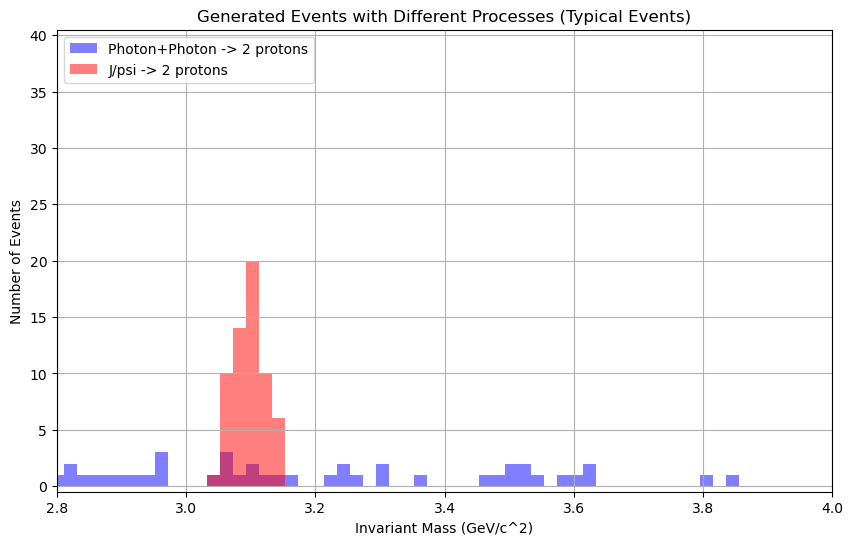

In [3]:
def plot_event_distribution_proton(events_photon_photon_proton, events_jpsi_protons):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 5, 250)
    plt.hist(events_photon_photon_proton, bins=bins, alpha=0.5, label='Photon+Photon -> 2 protons', color='blue')
    plt.hist(events_jpsi_protons, bins=bins, alpha=0.5, label='J/psi -> 2 protons', color='red')
    plt.xlabel('Invariant Mass (GeV/c^2)')
    #plt.yscale('log')  # Log scale for y-axis
    plt.xlim(2.8,4)
    plt.ylabel('Number of Events')
    plt.ylim(-0.5,40.5)
    plt.title('Generated Events with Different Processes (Typical Events)')
    plt.legend(loc='upper left', fontsize = 10)
    plt.grid(True)
    plt.show()

#plt.rcParams.update({'font.size': 15})

def generate_all_events_proton():
    events_photon_photon_proton = generate_photon_photon_proton_events(271)
    events_jpsi_protons = generate_jpsi_protons_events(61)
    

    photon_photon_proton = compute_invariant_masses_for_events_jpsi_proton(events_photon_photon_proton)
    jpsi_protons  = compute_invariant_masses_for_events_jpsi_proton(events_jpsi_protons)
    
    plot_event_distribution_proton(photon_photon_proton, jpsi_protons)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events_proton()

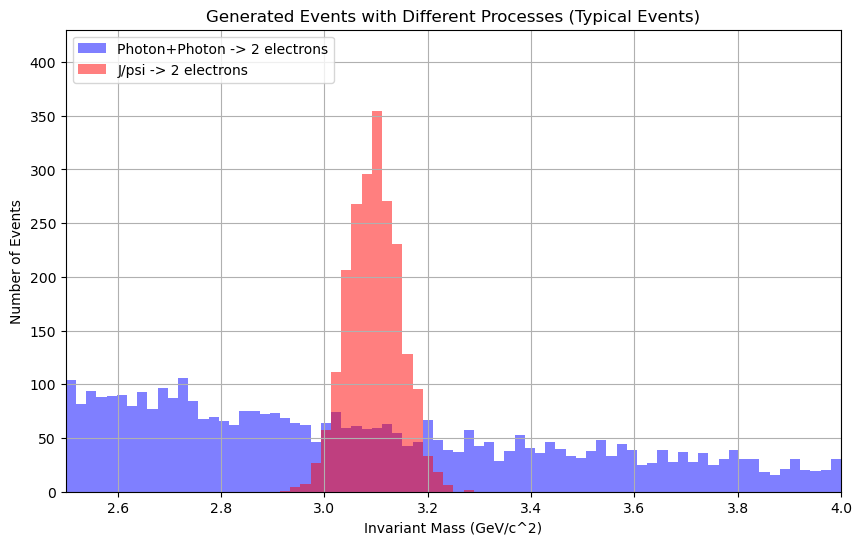

In [4]:
n_pp_electron_run2 = 74278
n_jpsi_electron_run2 = 2116


def plot_event_distribution_electron(events_photon_photon_electron, events_jpsi_electrons):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(2.5, 4, 77)
    plt.hist(events_photon_photon_electron, bins=bins, alpha=0.5, label='Photon+Photon -> 2 electrons', color='blue')
    plt.hist(events_jpsi_electrons, bins=bins, alpha=0.5, label='J/psi -> 2 electrons', color='red')
    plt.xlabel('Invariant Mass (GeV/c^2)')
    #plt.yscale('log')  # Log scale for y-axis
    plt.xlim(2.5,4)
    plt.ylabel('Number of Events')
    plt.ylim(0,430)
    plt.title('Generated Events with Different Processes (Typical Events)')
    plt.legend(loc='upper left', fontsize = 10)
    plt.grid(True)
    plt.show()

#plt.rcParams.update({'font.size': 15})

def generate_all_events_electron():
    events_photon_photon_proton = generate_photon_photon_electron_events(n_pp_electron_run2)
    events_jpsi_electrons = generate_jpsi_electrons_events(n_jpsi_electron_run2)
    

    photon_photon_electron = compute_invariant_masses_for_events_electron(events_photon_photon_proton)
    jpsi_electrons  = compute_invariant_masses_for_events_electron(events_jpsi_electrons)
    
    plot_event_distribution_electron(photon_photon_electron, jpsi_electrons)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events_electron()

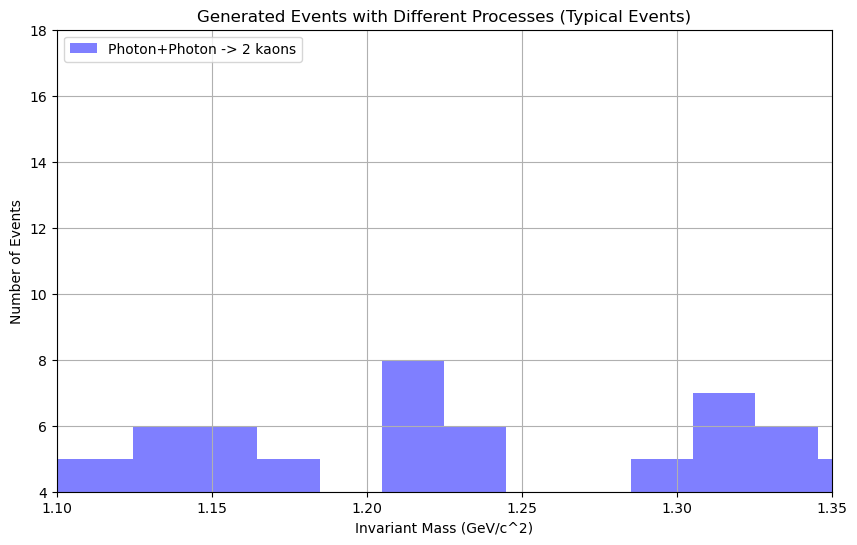

In [5]:
def plot_event_distribution_kaon(events_photon_photon_kaon):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 5, 250)
    plt.hist(events_photon_photon_kaon, bins=bins, alpha=0.5, label='Photon+Photon -> 2 kaons', color='blue')
    plt.xlabel('Invariant Mass (GeV/c^2)')
    #plt.yscale('log')  # Log scale for y-axis
    plt.xlim(1.1,1.35)
    plt.ylabel('Number of Events')
    plt.ylim(4,18)
    plt.title('Generated Events with Different Processes (Typical Events)')
    plt.legend(loc='upper left', fontsize = 10)
    plt.grid(True)
    plt.show()

#plt.rcParams.update({'font.size': 15})

def generate_all_events_kaon():
    events_photon_photon_kaon = generate_pp_kaon_events(423)
    
    photon_photon_kaon = compute_invariant_masses_for_events(events_photon_photon_kaon)
    
    plot_event_distribution_kaon(photon_photon_kaon)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events_kaon()

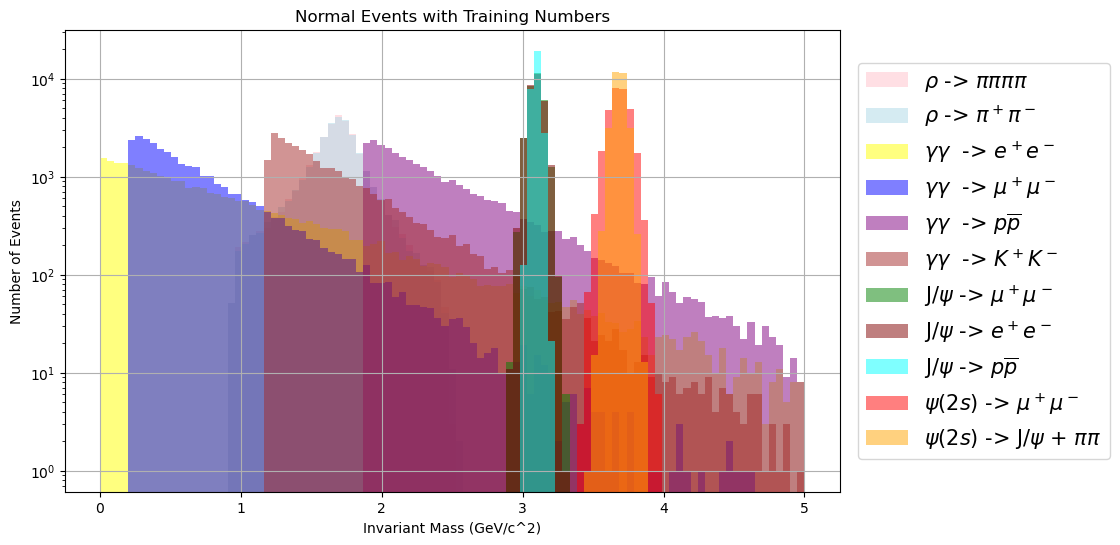

In [6]:
def plot_event_distribution_training(events_rho_4pions, events_rhoprime, events_photon_photon_electron, events_photon_photon, events_photon_photon_proton, events_pp_kaons, events_jpsi, events_jpsi_electrons, events_jpsi_protons, events_psi2S_muons, events_psi2S_jpsi_pions):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 5, 100)
    plt.hist(events_rho_4pions, bins, alpha=0.5, label=r'$\rho$ -> $\pi \pi \pi \pi$', color='pink')
    plt.hist(events_rhoprime, bins, alpha=0.5, label=r'$\rho$ -> $\pi^+ \pi^-$', color='lightblue')
    plt.hist(events_photon_photon_electron, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $e^+ e^-$', color='yellow')
    plt.hist(events_photon_photon, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $\mu^+ \mu^-$', color='blue')
    plt.hist(events_photon_photon_proton, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $p \overline{p}$', color='purple')
    plt.hist(events_pp_kaons, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $K^+ K^-$', color='brown')
    plt.hist(events_jpsi, bins, alpha=0.5, label=r'J/$\psi$ -> $\mu^+ \mu^-$', color='green')
    plt.hist(events_jpsi_electrons, bins, alpha=0.5, label=r'J/$\psi$ -> $e^+ e^-$', color='maroon')
    plt.hist(events_jpsi_protons, bins, alpha=0.5, label=r'J/$\psi$ -> $p \overline{p}$', color='cyan')
    plt.hist(events_psi2S_muons, bins, alpha=0.5, label=r'$\psi(2s)$ -> $\mu^+ \mu^-$', color='red')
    plt.hist(events_psi2S_jpsi_pions, bins, alpha=0.5, label=r'$\psi(2s)$ -> J/$\psi$ + $\pi \pi$', color='orange')

    plt.xlabel('Invariant Mass (GeV/c^2)')
    plt.yscale('log')  # Log scale for y-axis
    plt.ylabel('Number of Events')
    plt.title('Normal Events with Training Numbers')
    #plt.savefig('all_final_masses.pdf')
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),   # 1.02 pushes it just outside the right edge
        fancybox=True,
        shadow=False,
        ncol=1,                       # vertical list (recommended for side placement)
        fontsize=15,
        markerscale=1.3
    )
    #plt.legend(loc='upper right', fontsize = 10)
    plt.grid(True)
    plt.show()

def generate_all_events_training():
    events_photon_photon_electron = generate_photon_photon_electron_events(30000)
    events_photon_photon = generate_photon_photon_events(30000)
    events_jpsi = generate_jpsi_events(30000)
    events_psi2S_muons = generate_psi2S_muons_events(30000)
    events_psi2S_jpsi_pions = generate_psi2S_jpsi_pions_events_new(30000)
    events_pp_kaons = generate_pp_kaon_events(30000)
    events_jpsi_protons = generate_jpsi_protons_events(30000)
    events_photon_photon_proton = generate_photon_photon_proton_events(30000)
    events_jpsi_electrons = generate_jpsi_electrons_events(30000)
    events_rho_4pions = generate_rhoprime_events(30000)
    events_rhoprime = generate_rhoprime_events(30000)

    # events_jpsi_rho = generate_jpsi_rho_events(n_jpsi_4pi)
    #events_jpsi_3pions = generate_jpsi_3pions_events(n_jpsi_3pi)

    photon_photon_electron = compute_invariant_masses_for_events_electron(events_photon_photon_electron)
    photon_photon = compute_invariant_masses_for_events(events_photon_photon)
    photon_photon_proton = compute_invariant_masses_for_events_jpsi_proton(events_photon_photon_proton)
    photon_photon_kaons     = compute_invariant_masses_for_events_kaon(events_pp_kaons)

    rho_4pi  = compute_invariant_masses_for_events_pion(events_rho_4pions)
    rho_prime  = compute_invariant_masses_for_events_pion(events_rhoprime)

    jpsi          = compute_invariant_masses_for_events(events_jpsi)
    jpsi_electrons  = compute_invariant_masses_for_events_electron(events_jpsi_electrons)
    jpsi_protons  = compute_invariant_masses_for_events_jpsi_proton(events_jpsi_protons)
 
    psi2s_muons   = compute_invariant_masses_for_events(events_psi2S_muons)
    psi2s_jpsi_pi = compute_invariant_masses_for_events_psi2s(events_psi2S_jpsi_pions)


    #jpsi_rho      = compute_invariant_masses_for_events_jpsi_rho(events_jpsi_rho)
    #jpsi_3pi      = compute_invariant_masses_for_events_jpsi_3pi(events_jpsi_3pions)


    plot_event_distribution_training(rho_4pi, rho_prime, photon_photon_electron, photon_photon, photon_photon_proton, photon_photon_kaons, jpsi, jpsi_electrons, jpsi_protons, psi2s_muons, psi2s_jpsi_pi)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events_training()

In [7]:
"""
def plot_event_distribution_no_exotica(events_rho_4pions, events_rhoprime, events_photon_photon_electron, events_photon_photon, events_photon_photon_proton, events_pp_kaons, events_jpsi, events_jpsi_electrons, events_jpsi_protons, events_psi2S_muons, events_psi2S_jpsi_pions):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 5, 100)
    plt.hist(events_rho_4pions, bins, alpha=0.5, label=r'$\rho$ -> $\pi \pi \pi \pi$', color='pink')
    plt.hist(events_rhoprime, bins, alpha=0.5, label=r'$\rho$ -> $\pi^+ \pi^-$', color='lightblue')
    plt.hist(events_photon_photon_electron, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $e^+ e^-$', color='yellow')
    plt.hist(events_photon_photon, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $\mu^+ \mu^-$', color='blue')
    plt.hist(events_photon_photon_proton, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $p \overline{p}$', color='purple')
    plt.hist(events_pp_kaons, bins, alpha=0.5, label=r'$\gamma \gamma$  -> $K^+ K^-$', color='brown')
    plt.hist(events_jpsi, bins, alpha=0.5, label=r'J/$\psi$ -> $\mu^+ \mu^-$', color='green')
    plt.hist(events_jpsi_electrons, bins, alpha=0.5, label=r'J/$\psi$ -> $e^+ e^-$', color='maroon')
    plt.hist(events_jpsi_protons, bins, alpha=0.5, label=r'J/$\psi$ -> $p \overline{p}$', color='cyan')
    plt.hist(events_psi2S_muons, bins, alpha=0.5, label=r'$\psi(2s)$ -> $\mu^+ \mu^-$', color='red')
    plt.hist(events_psi2S_jpsi_pions, bins, alpha=0.5, label=r'$\psi(2s)$ -> J/$\psi$ + $\pi \pi$', color='orange')

    plt.xlabel('Invariant Mass (GeV/c^2)')
    plt.yscale('log')  # Log scale for y-axis
    plt.ylabel('Number of Events')
    plt.ylim(0.5, 8000000)
    plt.title('Normal Events with ALICE-like Numbers')
    #plt.savefig('all_final_masses.pdf')
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),   # 1.02 pushes it just outside the right edge
        fancybox=True,
        shadow=False,
        ncol=1,                       # vertical list (recommended for side placement)
        fontsize=15,
        markerscale=1.3
    )
    #plt.legend(loc='upper right', fontsize = 10)
    plt.grid(True)
    plt.show()

def generate_all_events_no_exotica():
    events_photon_photon_electron = generate_photon_photon_electron_events(n_photon_photon_electron)
    events_photon_photon = generate_photon_photon_events(n_photon_photon)
    events_jpsi = generate_jpsi_events(n_jpsi)
    events_psi2S_muons = generate_psi2S_muons_events(n_psi2S_muons)
    events_psi2S_jpsi_pions = generate_psi2S_jpsi_pions_events_new(n_psi2S_jpsi_pions)
    events_pp_kaons = generate_pp_kaon_events(n_pp_kaon)
    events_jpsi_protons = generate_jpsi_protons_events(n_jpsi_protons)
    events_photon_photon_proton = generate_photon_photon_proton_events(n_photon_photon_proton)
    events_jpsi_electrons = generate_jpsi_electrons_events(n_jpsi_electrons)
    events_rho_4pions = generate_rhoprime_events(n_rho_4pi)
    events_rhoprime = generate_rhoprime_events(n_rhoprime)

    # events_jpsi_rho = generate_jpsi_rho_events(n_jpsi_4pi)
    #events_jpsi_3pions = generate_jpsi_3pions_events(n_jpsi_3pi)

    photon_photon_electron = compute_invariant_masses_for_events_electron(events_photon_photon_electron)
    photon_photon = compute_invariant_masses_for_events(events_photon_photon)
    photon_photon_proton = compute_invariant_masses_for_events_jpsi_proton(events_photon_photon_proton)
    photon_photon_kaons     = compute_invariant_masses_for_events_kaon(events_pp_kaons)

    rho_4pi  = compute_invariant_masses_for_events_pion(events_rho_4pions)
    rho_prime  = compute_invariant_masses_for_events_pion(events_rhoprime)

    jpsi          = compute_invariant_masses_for_events(events_jpsi)
    jpsi_electrons  = compute_invariant_masses_for_events_electron(events_jpsi_electrons)
    jpsi_protons  = compute_invariant_masses_for_events_jpsi_proton(events_jpsi_protons)
 
    psi2s_muons   = compute_invariant_masses_for_events(events_psi2S_muons)
    psi2s_jpsi_pi = compute_invariant_masses_for_events_psi2s(events_psi2S_jpsi_pions)


    #jpsi_rho      = compute_invariant_masses_for_events_jpsi_rho(events_jpsi_rho)
    #jpsi_3pi      = compute_invariant_masses_for_events_jpsi_3pi(events_jpsi_3pions)


    plot_event_distribution_no_exotica(rho_4pi, rho_prime, photon_photon_electron, photon_photon, photon_photon_proton, photon_photon_kaons, jpsi, jpsi_electrons, jpsi_protons, psi2s_muons, psi2s_jpsi_pi)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events_no_exotica()
"""

"\ndef plot_event_distribution_no_exotica(events_rho_4pions, events_rhoprime, events_photon_photon_electron, events_photon_photon, events_photon_photon_proton, events_pp_kaons, events_jpsi, events_jpsi_electrons, events_jpsi_protons, events_psi2S_muons, events_psi2S_jpsi_pions):\n    plt.figure(figsize=(10, 6))\n    bins = np.linspace(0, 5, 100)\n    plt.hist(events_rho_4pions, bins, alpha=0.5, label=r'$\rho$ -> $\\pi \\pi \\pi \\pi$', color='pink')\n    plt.hist(events_rhoprime, bins, alpha=0.5, label=r'$\rho$ -> $\\pi^+ \\pi^-$', color='lightblue')\n    plt.hist(events_photon_photon_electron, bins, alpha=0.5, label=r'$\\gamma \\gamma$  -> $e^+ e^-$', color='yellow')\n    plt.hist(events_photon_photon, bins, alpha=0.5, label=r'$\\gamma \\gamma$  -> $\\mu^+ \\mu^-$', color='blue')\n    plt.hist(events_photon_photon_proton, bins, alpha=0.5, label=r'$\\gamma \\gamma$  -> $p \\overline{p}$', color='purple')\n    plt.hist(events_pp_kaons, bins, alpha=0.5, label=r'$\\gamma \\gamma$  -> $K^+

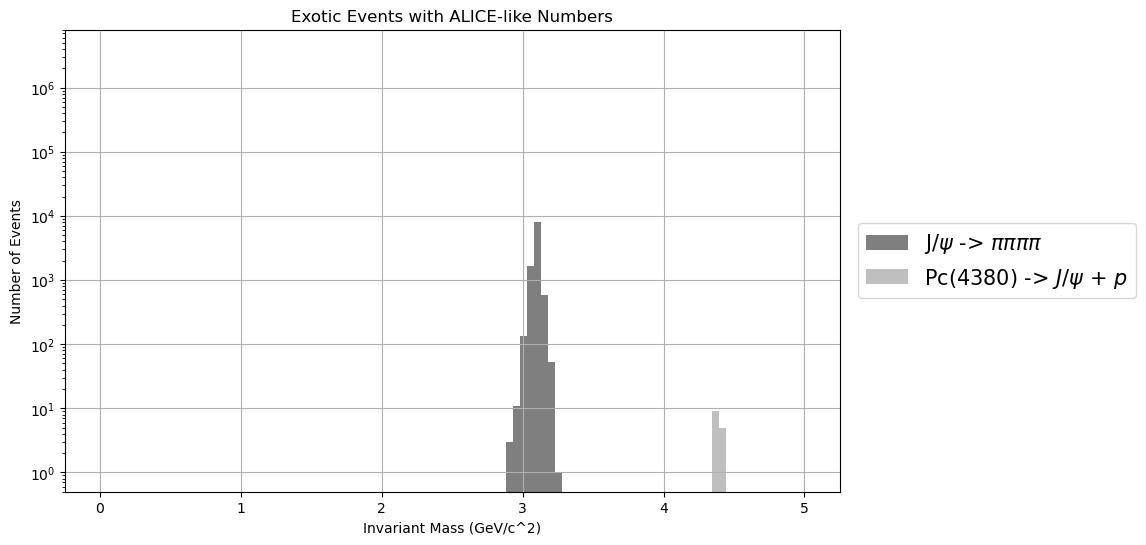

In [8]:
def plot_event_distribution_exotica(events_jpsi_4pions, events_pq):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 5, 100)
    plt.hist(events_jpsi_4pions, bins, alpha=0.5, label=r'J/$\psi$ -> $\pi \pi \pi \pi$', color='black')
    plt.hist(events_pq, bins, alpha=0.5, label=r'Pc(4380) -> $J/ \psi$ + $p$', color='gray')

    plt.xlabel('Invariant Mass (GeV/c^2)')
    plt.yscale('log')  # Log scale for y-axis
    plt.ylabel('Number of Events')
    plt.ylim(0.5, 8000000)
    plt.title('Exotic Events with ALICE-like Numbers')
    #plt.savefig('all_final_masses.pdf')
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),   # 1.02 pushes it just outside the right edge
        fancybox=True,
        shadow=False,
        ncol=1,                       # vertical list (recommended for side placement)
        fontsize=15,
        markerscale=1.3
    )
    #plt.legend(loc='upper right', fontsize = 10)
    plt.grid(True)
    plt.show()

def generate_all_events_exotica():
    events_pq = generate_pentaquark_events_new(n_pq1)
    events_jpsi_4pions = generate_jpsi_four_pions(n_jpsi_4pi)

    jpsi_4pi      = compute_invariant_masses_for_events_jpsi_4pi(events_jpsi_4pions)
    pentaquark    = compute_invariant_masses_for_events_pq(events_pq)

    #jpsi_rho      = compute_invariant_masses_for_events_jpsi_rho(events_jpsi_rho)
    #jpsi_3pi      = compute_invariant_masses_for_events_jpsi_3pi(events_jpsi_3pions)


    plot_event_distribution_exotica(jpsi_4pi, pentaquark)
    #plot_event_distribution1(jpsi_4pi)

# Run the generation and plotting
generate_all_events_exotica()

[176.76398048802866, 205.22013644539655, 213.97010450462645, 225.6299477712511, 197.13238022537203, 226.42178138254957, 220.19751880129644, 229.13198979732275, 237.56381905864072, 183.8087637388657, 273.7946101488882, 286.8159360566669, 199.29868041595785, 200.7806621070265, 219.09684258098923, 211.45502882888758, 245.7523779400454, 248.68174451066207, 205.32482527404719, 219.65547367243113, 233.70495981486806, 212.59415435036752, 215.6623082901006, 219.14056443394875, 211.33612038805202, 209.5883131397694, 218.1363520301746, 169.18721414650514, 208.19195230771845, 260.7307914710459, 246.80691478209798, 230.90950035313836, 183.6812399302521, 223.05567212175495, 210.60595403044906, 205.83113351096225, 236.2780372015103, 205.07112842567, 225.71592679555104, 189.80305586026017, 264.4974953706611, 220.25960816146613, 229.83500357056027, 195.1628035990621, 216.45983031169064, 223.41815458649398, 217.84495959052342, 210.5467691467153, 260.02748235357853, 237.8438794426545, 233.51107976911683

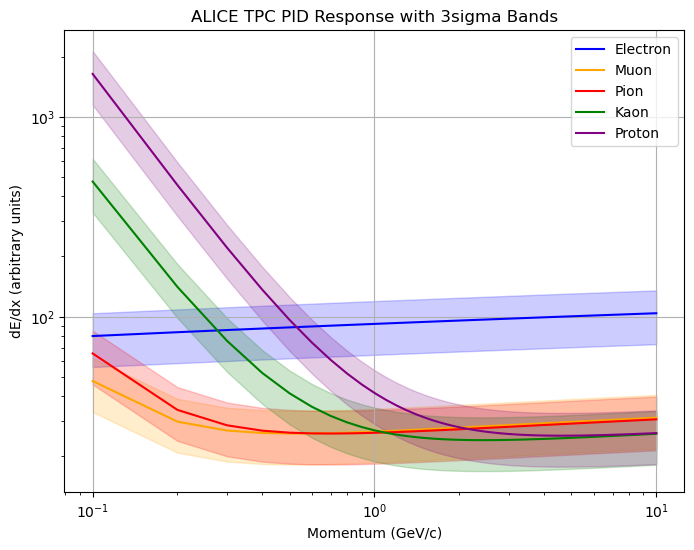

In [9]:
#PID PLOT WITH BANDS
import numpy as np
import matplotlib.pyplot as plt

def bethe_bloch(momentum, mass, charge=1):
    # Constants for Bethe-Bloch approximation
    K = 0.307075  # MeV mol^-1 cm^2
    Z = charge  # Particle charge
    I = 0.000016  # Mean excitation potential (MeV)
    m_e = 0.511  # Electron mass in MeV/c^2
    rho = 1  # Density of the material (relative to water, for simplicity)

    # Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)
    
    # Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17
    
    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }
    
    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3
    
    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):

    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)
    
    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)
    
    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6
    
    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)
    
    return random_dEdx

 # Example usage
momentum = .3  # Example momentum in GeV/c
particle_type = 'proton'  # Example particle type
x=1000 #Amount of random numbers

rn=[]
for _ in range(x):

    if (particle_type == 'electron'):
        stretch_factor=1
    elif (particle_type == 'muon'):
        stretch_factor=.41
    elif (particle_type == 'pion'):
        stretch_factor=.41
    elif (particle_type == 'kaon'):
        stretch_factor=.38
    elif (particle_type == 'proton'):
        stretch_factor=.40

    random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
    rn.append(random_value)
print(rn)

xvalues=[]
for _ in range(x):
    xvalues.append(momentum)
print(xvalues)

def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }
    
    plt.figure(figsize=(8, 6))
    
    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)
    
   # plt.plot(xvalues,rn, color= 'black')
    
    plt.xlabel('Momentum (GeV/c)')
    plt.ylabel('dE/dx (arbitrary units)')
    plt.xscale('log')  # Log scale for x-axis
    plt.yscale('log')  # Log scale for y-axis
    plt.title('ALICE TPC PID Response with 3sigma Bands')
    plt.legend()
    plt.grid(True)
    #plt.savefig("PID_empty.pdf")
    plt.show()
    
# Generate a momentum range and plot
momentum_range = np.linspace(0.1, 10, 100)  # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)


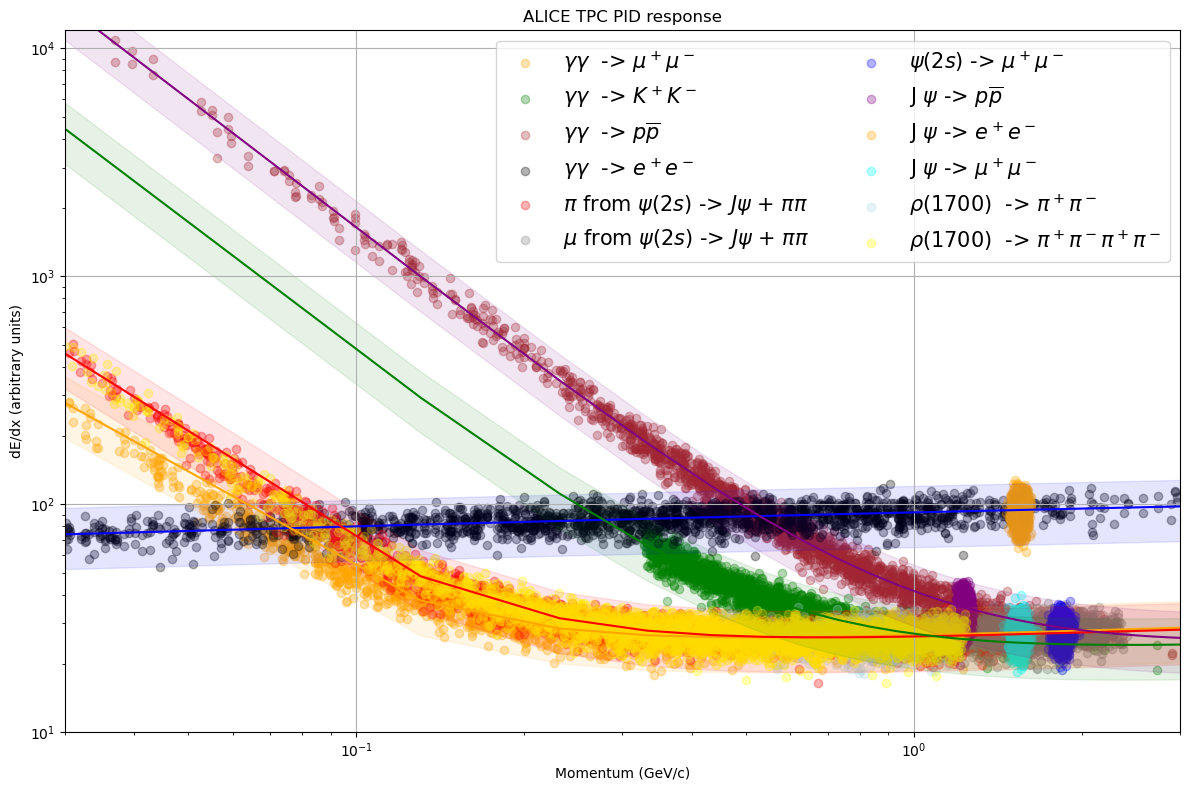

In [10]:
n_events = 1000

# plt.rcParams.update({'font.size': 15})

#Generate Jpsi events
jpsimuon_events = generate_jpsi_events(n_events)
jpsimuon1_dEdx = []
jpsimuon2_dEdx = []
jpsimuon1_momenta = []
jpsimuon2_momenta = []

# Iterate over events and calculate PID response for muons
for event in jpsimuon_events:
    jpsimuon1_p, jpsimuon2_p = event  # Extract momenta of muons
    
    # Calculate momentum magnitudes
    jpsimuon1_momentum = np.linalg.norm(jpsimuon1_p)
    jpsimuon2_momentum = np.linalg.norm(jpsimuon2_p)
    
    # Append momenta for later use
    jpsimuon1_momenta.append(jpsimuon1_momentum)
    jpsimuon1_momenta.append(jpsimuon2_momentum)
    
    # Calculate PID response (dE/dx) for each muon
    dEdx_jpsimuon1 = gaussian_tpc_response(jpsimuon1_momentum, 'muon', stretch_factor=0.41)
    dEdx_jpsimuon2 = gaussian_tpc_response(jpsimuon2_momentum, 'muon', stretch_factor=0.41)
    
    # Store the dE/dx values
    jpsimuon1_dEdx.append(dEdx_jpsimuon1)
    jpsimuon1_dEdx.append(dEdx_jpsimuon2)

# Generate photon-photon events
photonmuon_events = generate_photon_photon_events(n_events)
photonmuon1_dEdx = []
photonmuon2_dEdx = []
photonmuon1_momenta = []
photonmuon2_momenta = []

# Iterate over events and calculate PID response for muons
for event in photonmuon_events:
    photonmuon1_p, photonmuon2_p = event  # Extract momenta of muons

    # Calculate momentum magnitudes
    photonmuon1_momentum = np.linalg.norm(photonmuon1_p)
    photonmuon2_momentum = np.linalg.norm(photonmuon2_p)
    
    # Append momenta for later use
    photonmuon1_momenta.append(photonmuon1_momentum)
    photonmuon1_momenta.append(photonmuon2_momentum)
    
    # Calculate PID response (dE/dx) with Gaussian variations for each muon
    dEdx_photonmuon1 = gaussian_tpc_response(photonmuon1_momentum, 'muon', stretch_factor=0.41)
    dEdx_photonmuon2 = gaussian_tpc_response(photonmuon2_momentum, 'muon', stretch_factor=0.41)
    
    # Store the dE/dx values
    photonmuon1_dEdx.append(dEdx_photonmuon1)
    photonmuon1_dEdx.append(dEdx_photonmuon2)

#Generate psi2s muon events
psi2smuon_events = generate_psi2S_muons_events(n_events)
psi2smuon1_dEdx = []
psi2smuon2_dEdx = []
psi2smuon1_momenta = []
psi2smuon2_momenta = []

for event in psi2smuon_events:
    psi2smuon1_p, psi2smuon2_p = event  # Extract momenta of muons

    # Calculate momentum magnitudes
    psi2smuon1_momentum = np.linalg.norm(psi2smuon1_p)
    psi2smuon2_momentum = np.linalg.norm(psi2smuon2_p)
    
    # Append momenta for later use
    psi2smuon1_momenta.append(psi2smuon1_momentum)
    psi2smuon1_momenta.append(psi2smuon2_momentum)
    
    # Calculate PID response (dE/dx) with Gaussian variations for each muon
    dEdx_psi2smuon1 = gaussian_tpc_response(psi2smuon1_momentum, 'muon', stretch_factor=0.41)
    dEdx_psi2smuon2 = gaussian_tpc_response(psi2smuon2_momentum, 'muon', stretch_factor=0.41)
    
    # Store the dE/dx values
    psi2smuon1_dEdx.append(dEdx_psi2smuon1)
    psi2smuon1_dEdx.append(dEdx_psi2smuon2)


#Generate psi2s muon pion events
psi2s_jpsi_pions_events = generate_psi2S_jpsi_pions_events_smearing_after_boost_with_angles(n_events)
psi2s_jpsi_muon1_dEdx = []
psi2s_jpsi_muon2_dEdx = []
psi2s_jpsi_pion1_dEdx = []
psi2s_jpsi_pion2_dEdx = []
psi2s_jpsi_muon1_momenta = []
psi2s_jpsi_muon2_momenta = []
psi2s_jpsi_pion1_momenta = []
psi2s_jpsi_pion2_momenta = []

for event in psi2s_jpsi_pions_events:
    psi2s_jpsi_muon1_p, psi2s_jpsi_muon2_p, psi2s_jpsi_pion1_p, psi2s_jpsi_pion2_p, *_ = event

    psi2s_jpsi_muon1_momentum = np.linalg.norm(psi2s_jpsi_muon1_p)
    psi2s_jpsi_muon2_momentum = np.linalg.norm(psi2s_jpsi_muon2_p)
    psi2s_jpsi_pion1_momentum = np.linalg.norm(psi2s_jpsi_pion1_p)
    psi2s_jpsi_pion2_momentum = np.linalg.norm(psi2s_jpsi_pion2_p)

    psi2s_jpsi_muon1_momenta.append(psi2s_jpsi_muon1_momentum)
    psi2s_jpsi_muon1_momenta.append(psi2s_jpsi_muon2_momentum)
    psi2s_jpsi_pion1_momenta.append(psi2s_jpsi_pion1_momentum)
    psi2s_jpsi_pion1_momenta.append(psi2s_jpsi_pion2_momentum)    

    dEdx_psi2s_jpsi_muon1 = gaussian_tpc_response(psi2s_jpsi_muon1_momentum, 'muon', stretch_factor=0.41)
    dEdx_psi2s_jpsi_muon2 = gaussian_tpc_response(psi2s_jpsi_muon2_momentum, 'muon', stretch_factor=0.41)
    dEdx_psi2s_jpsi_pion1 = gaussian_tpc_response(psi2s_jpsi_pion1_momentum, 'pion', stretch_factor=0.41)
    dEdx_psi2s_jpsi_pion2 = gaussian_tpc_response(psi2s_jpsi_pion2_momentum, 'pion', stretch_factor=0.41)

    psi2s_jpsi_muon1_dEdx.append(dEdx_psi2s_jpsi_muon1)
    psi2s_jpsi_muon1_dEdx.append(dEdx_psi2s_jpsi_muon2)
    psi2s_jpsi_pion1_dEdx.append(dEdx_psi2s_jpsi_pion1)
    psi2s_jpsi_pion1_dEdx.append(dEdx_psi2s_jpsi_pion2)

# Generate photon-photon kaon events
photonkaon_events = generate_pp_kaon_events(n_events)
photonkaon1_dEdx = []
photonkaon2_dEdx = []
photonkaon1_momenta = []
photonkaon2_momenta = []

# Iterate over events and calculate PID response for kaons
for event in photonkaon_events:
    photonkaon1_p, photonkaon2_p = event  # Extract momenta of kaons

    # Calculate momentum magnitudes
    photonkaon1_momentum = np.linalg.norm(photonkaon1_p)
    photonkaon2_momentum = np.linalg.norm(photonkaon2_p)
    
    # Append momenta for later use
    photonkaon1_momenta.append(photonkaon1_momentum)
    photonkaon1_momenta.append(photonkaon2_momentum)
    
    # Calculate PID response (dE/dx) with Gaussian variations for each kaon
    dEdx_photonkaon1 = gaussian_tpc_response(photonkaon1_momentum, 'kaon', stretch_factor=0.38)
    dEdx_photonkaon2 = gaussian_tpc_response(photonkaon2_momentum, 'kaon', stretch_factor=0.38)
    
    # Store the dE/dx values
    photonkaon1_dEdx.append(dEdx_photonkaon1)
    photonkaon1_dEdx.append(dEdx_photonkaon2)

# Generate photon-photon proton events
photonproton_events = generate_photon_photon_proton_events(n_events)
photonproton1_dEdx = []
photonproton2_dEdx = []
photonproton1_momenta = []
photonproton2_momenta = []

# Iterate over events and calculate PID response for kaons
for event in photonproton_events:
    photonproton1_p, photonproton2_p = event  # Extract momenta of kaons

    # Calculate momentum magnitudes
    photonproton1_momentum = np.linalg.norm(photonproton1_p)
    photonproton2_momentum = np.linalg.norm(photonproton2_p)
    
    # Append momenta for later use
    photonproton1_momenta.append(photonproton1_momentum)
    photonproton1_momenta.append(photonproton2_momentum)
    
    # Calculate PID response (dE/dx) with Gaussian variations for each kaon
    dEdx_photonproton1 = gaussian_tpc_response(photonproton1_momentum, 'proton', stretch_factor=0.4)
    dEdx_photonproton2 = gaussian_tpc_response(photonproton2_momentum, 'proton', stretch_factor=0.4)
    
    # Store the dE/dx values
    photonproton1_dEdx.append(dEdx_photonproton1)
    photonproton1_dEdx.append(dEdx_photonproton2)

# Generate photon-photon electron events
photonelectron_events = generate_photon_photon_electron_events(n_events)
photonelectron1_dEdx = []
photonelectron2_dEdx = []
photonelectron1_momenta = []
photonelectron2_momenta = []

# Iterate over events and calculate PID response for kaons
for event in photonelectron_events:
    photonelectron1_p, photonelectron2_p = event  # Extract momenta of kaons

    # Calculate momentum magnitudes
    photonelectron1_momentum = np.linalg.norm(photonelectron1_p)
    photonelectron2_momentum = np.linalg.norm(photonelectron2_p)
    
    # Append momenta for later use
    photonelectron1_momenta.append(photonelectron1_momentum)
    photonelectron1_momenta.append(photonelectron2_momentum)
    
    # Calculate PID response (dE/dx) with Gaussian variations for each kaon
    dEdx_photonelectron1 = gaussian_tpc_response(photonelectron1_momentum, 'electron', stretch_factor=1)
    dEdx_photonelectron2 = gaussian_tpc_response(photonelectron2_momentum, 'electron', stretch_factor=1)
    
    # Store the dE/dx values
    photonelectron1_dEdx.append(dEdx_photonelectron1)
    photonelectron1_dEdx.append(dEdx_photonelectron2)


#Generate Jpsi proton events
jpsiproton_events = generate_jpsi_protons_events(n_events)
jpsiproton1_dEdx = []
jpsiproton2_dEdx = []
jpsiproton1_momenta = []
jpsiproton2_momenta = []

# Iterate over events and calculate PID response for protons
for event in jpsiproton_events:
    jpsiproton1_p, jpsiproton2_p = event  # Extract momenta of protons
    
    # Calculate momentum magnitudes
    jpsiproton1_momentum = np.linalg.norm(jpsiproton1_p)
    jpsiproton2_momentum = np.linalg.norm(jpsiproton2_p)
    
    # Append momenta for later use
    jpsiproton1_momenta.append(jpsiproton1_momentum)
    jpsiproton1_momenta.append(jpsiproton2_momentum)
    
    # Calculate PID response (dE/dx) for each muon
    dEdx_jpsiproton1 = gaussian_tpc_response(jpsiproton1_momentum, 'proton', stretch_factor=0.4)
    dEdx_jpsiproton2 = gaussian_tpc_response(jpsiproton2_momentum, 'proton', stretch_factor=0.4)
    
    # Store the dE/dx values
    jpsiproton1_dEdx.append(dEdx_jpsiproton1)
    jpsiproton1_dEdx.append(dEdx_jpsiproton2)


#Generate Jpsi electron events
jpsielectron_events = generate_jpsi_electrons_events(n_events)
jpsielectron1_dEdx = []
jpsielectron2_dEdx = []
jpsielectron1_momenta = []
jpsielectron2_momenta = []

# Iterate over events and calculate PID response for electron
for event in jpsielectron_events:
    jpsielectron1_p, jpsielectron2_p = event  # Extract momenta of electron
    
    # Calculate momentum magnitudes
    jpsielectron1_momentum = np.linalg.norm(jpsielectron1_p)
    jpsielectron2_momentum = np.linalg.norm(jpsielectron2_p)
    
    # Append momenta for later use
    jpsielectron1_momenta.append(jpsielectron1_momentum)
    jpsielectron1_momenta.append(jpsielectron2_momentum)
    
    # Calculate PID response (dE/dx) for each muon
    dEdx_jpsielectron1 = gaussian_tpc_response(jpsielectron1_momentum, 'electron', stretch_factor=1)
    dEdx_jpsielectron2 = gaussian_tpc_response(jpsielectron2_momentum, 'electron', stretch_factor=1)
    
    # Store the dE/dx values
    jpsielectron1_dEdx.append(dEdx_jpsielectron1)
    jpsielectron1_dEdx.append(dEdx_jpsielectron2)

#Generate pentaquark muon proton events
pentaquark_muons_proton_events = generate_pentaquark_jpsi_muons_events_smearing_after_boost_with_angles(n_events)
pentaquark_muon1_dEdx = []
pentaquark_muon2_dEdx = []
pentaquark_proton_dEdx = []
pentaquark_muon1_momenta = []
pentaquark_muon2_momenta = []
pentaquark_proton_momenta = []

for event in pentaquark_muons_proton_events:
    pentaquark_muon1_p, pentaquark_muon2_p, pentaquark_proton_p, *_ = event

    pentaquark_muon1_momentum = np.linalg.norm(pentaquark_muon1_p)
    pentaquark_muon2_momentum = np.linalg.norm(pentaquark_muon2_p)
    pentaquark_proton_momentum = np.linalg.norm(pentaquark_proton_p)

    pentaquark_muon1_momenta.append(pentaquark_muon1_momentum)
    pentaquark_muon1_momenta.append(pentaquark_muon2_momentum)
    pentaquark_proton_momenta.append(pentaquark_proton_momentum)
  
    dEdx_pentaquark_muon1 = gaussian_tpc_response(pentaquark_muon1_momentum, 'muon', stretch_factor=0.41)
    dEdx_pentaquark_muon2 = gaussian_tpc_response(pentaquark_muon2_momentum, 'muon', stretch_factor=0.41)
    dEdx_pentaquark_proton = gaussian_tpc_response(pentaquark_proton_momentum, 'proton', stretch_factor=0.4)
  
    pentaquark_muon1_dEdx.append(dEdx_pentaquark_muon1)
    pentaquark_muon1_dEdx.append(dEdx_pentaquark_muon2)
    pentaquark_proton_dEdx.append(dEdx_pentaquark_proton)

#Generate Jpsi events
rhopion_events = generate_rhoprime_events(n_events)
rhopion1_dEdx = []
rhopion2_dEdx = []
rhopion1_momenta = []
rhopion2_momenta = []

# Iterate over events and calculate PID response for muons
for event in rhopion_events:
    rhopion1_p, rhopion2_p = event  # Extract momenta of muons
    
    # Calculate momentum magnitudes
    rhopion1_momentum = np.linalg.norm(rhopion1_p)
    rhopion2_momentum = np.linalg.norm(rhopion2_p)
    
    # Append momenta for later use
    rhopion1_momenta.append(rhopion1_momentum)
    rhopion1_momenta.append(rhopion2_momentum)
    
    # Calculate PID response (dE/dx) for each muon
    dEdx_rhopion1 = gaussian_tpc_response(rhopion1_momentum, 'pion', stretch_factor=0.41)
    dEdx_rhopion2 = gaussian_tpc_response(rhopion2_momentum, 'pion', stretch_factor=0.41)
    
    # Store the dE/dx values
    rhopion1_dEdx.append(dEdx_rhopion1)
    rhopion1_dEdx.append(dEdx_rhopion2)


#Generate psi2s muon pion events
rho_four_pions_events = generate_rho_four_pions(n_events)
rho_four_pion1_dEdx = []
rho_four_pion2_dEdx = []
rho_four_pion3_dEdx = []
rho_four_pion4_dEdx = []
rho_four_pion1_momenta = []
rho_four_pion2_momenta = []
rho_four_pion3_momenta = []
rho_four_pion4_momenta = []

for event in rho_four_pions_events:
    rho_four_pion1_p, rho_four_pion2_p, rho_four_pion3_p, rho_four_pion4_p, *_ = event

    rho_four_pion1_momentum = np.linalg.norm(rho_four_pion1_p)
    rho_four_pion2_momentum = np.linalg.norm(rho_four_pion2_p)
    rho_four_pion3_momentum = np.linalg.norm(rho_four_pion3_p)
    rho_four_pion4_momentum = np.linalg.norm(rho_four_pion4_p)

    rho_four_pion1_momenta.append(rho_four_pion1_momentum)
    rho_four_pion1_momenta.append(rho_four_pion2_momentum)
    rho_four_pion1_momenta.append(rho_four_pion3_momentum)
    rho_four_pion1_momenta.append(rho_four_pion4_momentum)    

    dEdx_rho_four_pion1 = gaussian_tpc_response(rho_four_pion1_momentum, 'pion', stretch_factor=0.41)
    dEdx_rho_four_pion2 = gaussian_tpc_response(rho_four_pion2_momentum, 'pion', stretch_factor=0.41)
    dEdx_rho_four_pion3 = gaussian_tpc_response(rho_four_pion3_momentum, 'pion', stretch_factor=0.41)
    dEdx_rho_four_pion4 = gaussian_tpc_response(rho_four_pion4_momentum, 'pion', stretch_factor=0.41)

    rho_four_pion1_dEdx.append(dEdx_rho_four_pion1)
    rho_four_pion1_dEdx.append(dEdx_rho_four_pion2)
    rho_four_pion1_dEdx.append(dEdx_rho_four_pion3)
    rho_four_pion1_dEdx.append(dEdx_rho_four_pion4)


#Generate psi2s muon pion events
jpsi_four_pions_events = generate_jpsi_four_pions(n_events)
jpsi_four_pion1_dEdx = []
jpsi_four_pion2_dEdx = []
jpsi_four_pion3_dEdx = []
jpsi_four_pion4_dEdx = []
jpsi_four_pion1_momenta = []
jpsi_four_pion2_momenta = []
jpsi_four_pion3_momenta = []
jpsi_four_pion4_momenta = []

for event in jpsi_four_pions_events:
    jpsi_four_pion1_p, jpsi_four_pion2_p, jpsi_four_pion3_p, jpsi_four_pion4_p, *_ = event

    jpsi_four_pion1_momentum = np.linalg.norm(jpsi_four_pion1_p)
    jpsi_four_pion2_momentum = np.linalg.norm(jpsi_four_pion2_p)
    jpsi_four_pion3_momentum = np.linalg.norm(jpsi_four_pion3_p)
    jpsi_four_pion4_momentum = np.linalg.norm(jpsi_four_pion4_p)

    jpsi_four_pion1_momenta.append(jpsi_four_pion1_momentum)
    jpsi_four_pion1_momenta.append(jpsi_four_pion2_momentum)
    jpsi_four_pion1_momenta.append(jpsi_four_pion3_momentum)
    jpsi_four_pion1_momenta.append(jpsi_four_pion4_momentum)    

    dEdx_jpsi_four_pion1 = gaussian_tpc_response(jpsi_four_pion1_momentum, 'pion', stretch_factor=0.41)
    dEdx_jpsi_four_pion2 = gaussian_tpc_response(jpsi_four_pion2_momentum, 'pion', stretch_factor=0.41)
    dEdx_jpsi_four_pion3 = gaussian_tpc_response(jpsi_four_pion3_momentum, 'pion', stretch_factor=0.41)
    dEdx_jpsi_four_pion4 = gaussian_tpc_response(jpsi_four_pion4_momentum, 'pion', stretch_factor=0.41)

    jpsi_four_pion1_dEdx.append(dEdx_jpsi_four_pion1)
    jpsi_four_pion1_dEdx.append(dEdx_jpsi_four_pion2)
    jpsi_four_pion1_dEdx.append(dEdx_jpsi_four_pion3)
    jpsi_four_pion1_dEdx.append(dEdx_jpsi_four_pion4)


# Plot the results
plt.figure(figsize=(12, 8)) 

#Photon Muon 
plt.scatter(photonmuon1_momenta, photonmuon1_dEdx, color='orange', alpha=.3, label=r'$\gamma \gamma$  -> $\mu^+ \mu^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Muon 2 PID Response')
plt.grid(True)
plt.legend()

#photon Kaon dE/dx vs Momentum
plt.scatter(photonkaon1_momenta, photonkaon1_dEdx, color='green', alpha=.3, label=r'$\gamma \gamma$  -> $K^+ K^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Kaon PID Response')
plt.grid(True)
plt.legend()

#photon proton dE/dx vs Momentum
plt.scatter(photonproton1_momenta, photonproton1_dEdx, color='brown', alpha=.3, label=r'$\gamma \gamma$  -> $p \overline{p}$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Proton PID Response')
plt.grid(True)
plt.legend()

#photon proton dE/dx vs Momentum
plt.scatter(photonelectron1_momenta, photonelectron1_dEdx, color='black', alpha=.3, label=r'$\gamma \gamma$  -> $e^+ e^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Electron PID Response')
plt.grid(True)
plt.legend()

# Scatter plot for Pions
plt.scatter(psi2s_jpsi_pion1_momenta, psi2s_jpsi_pion1_dEdx, color='red', alpha=0.3, label=r'$\pi$ from $\psi (2s)$ -> $J \psi$ + $\pi \pi$')
plt.xlabel('Event Index')
plt.ylabel('Momentum (GeV/c)')
plt.title('Momentum Distribution for Muons from psi(2S) J/psi Events')
plt.legend()
plt.grid(True)

# Scatter plot for Muons
plt.scatter(psi2s_jpsi_muon1_momenta, psi2s_jpsi_muon1_dEdx, color='grey', alpha=0.3, label=r'$\mu$ from $\psi (2s)$ -> $J \psi$ + $\pi \pi$')
plt.xlabel('Event Index')
plt.ylabel('Momentum (GeV/c)')
plt.title('Momentum Distribution for Muons from psi(2S) J/psi Events')
plt.legend()
plt.grid(True)

#Psi2s Muon 
plt.scatter(psi2smuon1_momenta, psi2smuon1_dEdx, color='blue', alpha=.3, label=r'$\psi (2s)$ -> $\mu^+ \mu^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Muon 2 PID Response')
plt.grid(True)
plt.legend()

#Jpsi Proton dE/dx vs Momentum
plt.scatter(jpsiproton1_momenta, jpsiproton1_dEdx, color='purple', alpha=.3, label=r'J $\psi$ -> $p \overline{p}$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Proton 1 PID Response')
plt.grid(True)
plt.legend()

#Jpsi Electron dE/dx vs Momentum
plt.scatter(jpsielectron1_momenta, jpsielectron1_dEdx, color='orange', alpha=.3, label=r'J $\psi$ -> $e^+ e^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Proton 1 PID Response')
plt.grid(True)
plt.legend()

#Jpsi Muon dE/dx vs Momentum
plt.scatter(jpsimuon1_momenta, jpsimuon1_dEdx, color='cyan', alpha=.3, label=r'J $\psi$ -> $\mu^+ \mu^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Muon 1 PID Response')
plt.grid(True)
plt.legend()

#rho 2pi 
plt.scatter(rhopion1_momenta, rhopion1_dEdx, color='lightblue', alpha=.3, label=r'$\rho(1700)$  -> $\pi^+ \pi^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Pion 1 PID Response')
plt.grid(True)
plt.legend()

#rho 4pi 
plt.scatter(rho_four_pion1_momenta, rho_four_pion1_dEdx, color='yellow', alpha=.3, label=r'$\rho(1700)$  -> $\pi^+ \pi^- \pi^+ \pi^-$')
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.title('Pion 1 PID Response')
plt.grid(True)
plt.legend()

# #jpsi 4pi 
# plt.scatter(jpsi_four_pion1_momenta, jpsi_four_pion1_dEdx, color='pink', alpha=.3, label=r'J $\psi$ -> $\pi^+ \pi^- \pi^+ \pi^-$')
# plt.xlabel('Momentum (GeV/c)')
# plt.ylabel('dE/dx (arbitrary units)')
# plt.title('Pion 1 PID Response')
# plt.grid(True)
# plt.legend()

# #Scatter plot for Pentaquark Muons
# plt.scatter(pentaquark_muon1_momenta, pentaquark_muon1_dEdx, color='maroon', alpha=0.3, label=r'$\mu$ from pentaquark')
# plt.xlabel('Event Index')
# plt.ylabel('Momentum (GeV/c)')
# plt.title('Momentum Distribution for Muons from Pentaquark Events')
# plt.legend()
# plt.grid(True)

# # Scatter plot for Pentaquark Proton 
# plt.scatter(pentaquark_proton_momenta, pentaquark_proton_dEdx, color='lightgreen', alpha=0.3, label=r'p from pentaquark')
# plt.xlabel('Event Index')
# plt.ylabel('Momentum (GeV/c)')
# plt.title('Momentum Distribution for Proton from Pentaquark Events')
# plt.legend()
# plt.grid(True)


particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }
    
    
momentum_range = np.linspace(0.03, 10, 100)   
for particle, settings in particle_types.items():
    response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
    plt.plot(momentum_range, response, label = '_nolegend_', color=settings['color'])
    plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.1)
    # plt.legend()
    
   # plt.plot(xvalues,rn, color= 'black')
    

plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.xscale('log')
plt.yscale('log')
plt.xlim([0.03, 3])
plt.ylim([10, 12000])
plt.title('ALICE TPC PID response')
plt.legend(loc='upper right', ncol = 2, fontsize=15) #, fontsize="15"
plt.grid(True)

# Get current axes and create a legend with 2 columns
# ax = plt.gca()
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2)
# ax.set_xlim([0.03, 3])
# ax.set_ylim([10, 100000])

# Adjust layout to reserve space for the legend (e.g. top 10% of the figure)
plt.tight_layout() #rect=[0, 0, 1, 0.9]
plt.show()



# Creation of Dataframes

## Generation 1

In [11]:

import pandas as pd

n_training = 10000

data_for_pp_muons_gen1 = []
pp_muons_events = generate_photon_photon_events(n_photon_photon)
for event_id, event in enumerate(pp_muons_events):
    muon1_p, muon2_p = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    data_for_pp_muons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    data_for_pp_muons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
df_pp_muons_gen1 = pd.DataFrame(data_for_pp_muons_gen1)

data_for_jpsimuons_gen1= []
jpsi_muons_events = generate_jpsi_events(n_jpsi)
for event_id, event in enumerate(jpsi_muons_events):
    muon1_p, muon2_p = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    data_for_jpsimuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    data_for_jpsimuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
df_jpsimuons_gen1 = pd.DataFrame(data_for_jpsimuons_gen1)

data_for_jpsiprotons_gen1= []
jpsi_protons_events = generate_jpsi_protons_events(n_jpsi_protons)
for event_id, event in enumerate(jpsi_protons_events):
    proton1_p, proton2_p = event
    proton1_E = np.sqrt(np.linalg.norm(proton1_p)**2 + m_proton**2)
    proton2_E = np.sqrt(np.linalg.norm(proton2_p)**2 + m_proton**2)
    data_for_jpsiprotons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton1_p[0], "py": proton1_p[1], "pz": proton1_p[2], "Energy": proton1_E})
    data_for_jpsiprotons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton2_p[0], "py": proton2_p[1], "pz": proton2_p[2], "Energy": proton2_E})
df_jpsiprotons_gen1 = pd.DataFrame(data_for_jpsiprotons_gen1)

data_for_jpsielectrons_gen1= []
jpsi_electrons_events = generate_jpsi_electrons_events(n_jpsi_electrons)
for event_id, event in enumerate(jpsi_electrons_events):
    electron1_p, electron2_p = event
    electron1_E = np.sqrt(np.linalg.norm(electron1_p)**2 + m_electron**2)
    electron2_E = np.sqrt(np.linalg.norm(electron2_p)**2 + m_electron**2)
    data_for_jpsielectrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron1_p[0], "py": electron1_p[1], "pz": electron1_p[2], "Energy": electron1_E})
    data_for_jpsielectrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron2_p[0], "py": electron2_p[1], "pz": electron2_p[2], "Energy": electron2_E})
df_jpsielectrons_gen1 = pd.DataFrame(data_for_jpsielectrons_gen1)

data_for_psi2smuons_gen1 = []
psi2s_muons_events = generate_psi2S_muons_events(n_psi2S_muons)
for event_id, event in enumerate(psi2s_muons_events):
    muon1_p, muon2_p = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    data_for_psi2smuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    data_for_psi2smuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
df_psi2smuons_gen1 = pd.DataFrame(data_for_psi2smuons_gen1)

data_for_pp_kaons_gen1 = []
pp_kaons_events = generate_pp_kaon_events(n_pp_kaon)
for event_id, event in enumerate(pp_kaons_events):
    kaon1_p, kaon2_p = event
    kaon1_E = np.sqrt(np.linalg.norm(kaon1_p)**2 + m_kaon**2)
    kaon2_E = np.sqrt(np.linalg.norm(kaon2_p)**2 + m_kaon**2)
    data_for_pp_kaons_gen1.append({"EventID": event_id, "Particle": "kaon", "px": kaon1_p[0], "py": kaon1_p[1], "pz": kaon1_p[2], "Energy": kaon1_E})
    data_for_pp_kaons_gen1.append({"EventID": event_id, "Particle": "kaon", "px": kaon2_p[0], "py": kaon2_p[1], "pz": kaon2_p[2], "Energy": kaon2_E})
df_pp_kaons_gen1 = pd.DataFrame(data_for_pp_kaons_gen1)

data_for_pp_protons_gen1 = []
pp_protons_events = generate_photon_photon_proton_events(n_photon_photon_proton)
for event_id, event in enumerate(pp_protons_events):
    proton1_p, proton2_p = event
    proton1_E = np.sqrt(np.linalg.norm(proton1_p)**2 + m_proton**2)
    proton2_E = np.sqrt(np.linalg.norm(proton2_p)**2 + m_proton**2)
    data_for_pp_protons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton1_p[0], "py": proton1_p[1], "pz": proton1_p[2], "Energy": proton1_E})
    data_for_pp_protons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton2_p[0], "py": proton2_p[1], "pz": proton2_p[2], "Energy": proton2_E})
df_pp_protons_gen1 = pd.DataFrame(data_for_pp_protons_gen1)

data_for_pp_electrons_gen1 = []
pp_electrons_events = generate_photon_photon_electron_events(n_photon_photon_electron)
for event_id, event in enumerate(pp_electrons_events):
    electron1_p, electron2_p = event
    electron1_E = np.sqrt(np.linalg.norm(electron1_p)**2 + m_electron**2)
    electron2_E = np.sqrt(np.linalg.norm(electron2_p)**2 + m_electron**2)
    data_for_pp_electrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron1_p[0], "py": electron1_p[1], "pz": electron1_p[2], "Energy": electron1_E})
    data_for_pp_electrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron2_p[0], "py": electron2_p[1], "pz": electron2_p[2], "Energy": electron2_E})
df_pp_electrons_gen1 = pd.DataFrame(data_for_pp_electrons_gen1)

data_for_psi2s_muons_pions_gen1 = []
psi2s_muons_pions_events = generate_psi2S_jpsi_pions_events_smearing_after_boost_with_angles(n_psi2S_jpsi_pions)
for event_id, event in enumerate(psi2s_muons_pions_events):
    muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, m1_E, m2_E, p1_E, p2_E = event
    data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p_lab_smeared[0], "py": muon1_p_lab_smeared[1], "pz": muon1_p_lab_smeared[2], "Energy": m1_E})
    data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p_lab_smeared[0], "py": muon2_p_lab_smeared[1], "pz": muon2_p_lab_smeared[2], "Energy": m2_E})
    data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p[0], "py": pion1_p[1], "pz": pion1_p[2], "Energy": p1_E})
    data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p[0], "py": pion2_p[1], "pz": pion2_p[2], "Energy": p2_E})
df_psi2s_muons_pions_gen1 = pd.DataFrame(data_for_psi2s_muons_pions_gen1)
df_psi2s_muons_pions_gen1.head()

data_for_pentaquark_gen1 = []
pentaquark_events = generate_pentaquark_jpsi_muons_events_smearing_after_boost_with_angles(n_pq1)
for event_id, event in enumerate(pentaquark_events):
    muon1_p, muon2_p, proton_p, _, _, _ = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    proton_E = np.sqrt(np.linalg.norm(proton1_p)**2 + m_proton**2)
    data_for_pentaquark_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    data_for_pentaquark_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
    data_for_pentaquark_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton_p[0], "py": proton_p[1], "pz": proton_p[2], "Energy": proton_E})
df_pentaquark_gen1 = pd.DataFrame(data_for_pentaquark_gen1)

data_for_jpsi_four_pions_gen1 = []
jpsi_four_pions_events = generate_jpsi_four_pions(n_jpsi_4pi)
for event_id, event in enumerate(jpsi_four_pions_events):
    pion1_p_lab_smeared, pion2_p_lab_smeared, pion3_p, pion4_p, p1_E, p2_E, p3_E, p4_E = event
    data_for_jpsi_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p_lab_smeared[0], "py": pion1_p_lab_smeared[1], "pz": pion1_p_lab_smeared[2], "Energy": p1_E})
    data_for_jpsi_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p_lab_smeared[0], "py": pion2_p_lab_smeared[1], "pz": pion2_p_lab_smeared[2], "Energy": p2_E})
    data_for_jpsi_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion3_p[0], "py": pion3_p[1], "pz": pion3_p[2], "Energy": p3_E})
    data_for_jpsi_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion4_p[0], "py": pion4_p[1], "pz": pion4_p[2], "Energy": p4_E})
df_jpsi_four_pions_gen1 = pd.DataFrame(data_for_jpsi_four_pions_gen1)

data_for_rho_gen1= []
rho_events = generate_rhoprime_events(n_rhoprime)
for event_id, event in enumerate(rho_events):
    pion1_p, pion2_p = event
    pion1_E = np.sqrt(np.linalg.norm(pion1_p)**2 + m_pion**2)
    pion2_E = np.sqrt(np.linalg.norm(pion2_p)**2 + m_pion**2)
    data_for_rho_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p[0], "py": pion1_p[1], "pz": pion1_p[2], "Energy": pion1_E})
    data_for_rho_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p[0], "py": pion2_p[1], "pz": pion2_p[2], "Energy": pion2_E})
df_rho_gen1 = pd.DataFrame(data_for_rho_gen1)

data_for_rho_four_pions_gen1 = []
rho_four_pions_events = generate_rho_four_pions(n_rho_4pi)
for event_id, event in enumerate(rho_four_pions_events):
    pion1_p_lab_smeared, pion2_p_lab_smeared, pion3_p, pion4_p, p1_E, p2_E, p3_E, p4_E = event
    data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p_lab_smeared[0], "py": pion1_p_lab_smeared[1], "pz": pion1_p_lab_smeared[2], "Energy": p1_E})
    data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p_lab_smeared[0], "py": pion2_p_lab_smeared[1], "pz": pion2_p_lab_smeared[2], "Energy": p2_E})
    data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion3_p[0], "py": pion3_p[1], "pz": pion3_p[2], "Energy": p3_E})
    data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion4_p[0], "py": pion4_p[1], "pz": pion4_p[2], "Energy": p4_E})
df_rho_four_pions_gen1 = pd.DataFrame(data_for_rho_four_pions_gen1)
df_rho_four_pions_gen1

,EventID,Particle,px,py,pz,Energy
0,0,pion,0.055870,0.507518,-0.687448,0.867618
1,0,pion,0.029926,0.410987,0.138868,0.456694
2,0,pion,0.075265,0.106542,0.094567,0.213164
3,0,pion,-0.161107,-1.024303,0.458778,0.161517
4,1,pion,-0.172821,0.078238,-0.291527,0.374774
...,...,...,...,...,...,...
23999995,5999998,pion,0.151156,0.611199,-0.139907,0.392851
23999996,5999999,pion,-0.148965,-0.089093,0.566817,0.609007
23999997,5999999,pion,-0.448612,0.228093,-0.020060,0.522648
23999998,5999999,pion,0.095750,-0.031341,0.059914,0.182263


In [12]:
training_data_for_pp_muons_gen1 = []
training_pp_muons_events = generate_photon_photon_events(n_training)
for event_id, event in enumerate(training_pp_muons_events):
    muon1_p, muon2_p = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    training_data_for_pp_muons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    training_data_for_pp_muons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
training_df_for_pp_muons_gen1 = pd.DataFrame(training_data_for_pp_muons_gen1)

training_data_for_jpsimuons_gen1= []
training_jpsi_muons_events = generate_jpsi_events(n_training)
for event_id, event in enumerate(training_jpsi_muons_events):
    muon1_p, muon2_p = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    training_data_for_jpsimuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    training_data_for_jpsimuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
training_df_jpsimuons_gen1 = pd.DataFrame(training_data_for_jpsimuons_gen1)

training_data_for_jpsielectrons_gen1= []
training_jpsi_electrons_events = generate_jpsi_electrons_events(n_training)
for event_id, event in enumerate(training_jpsi_electrons_events):
    electron1_p, electron2_p = event
    electron1_E = np.sqrt(np.linalg.norm(electron1_p)**2 + m_electron**2)
    electron2_E = np.sqrt(np.linalg.norm(electron2_p)**2 + m_electron**2)
    training_data_for_jpsielectrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron1_p[0], "py": electron1_p[1], "pz": electron1_p[2], "Energy": electron1_E})
    training_data_for_jpsielectrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron2_p[0], "py": electron2_p[1], "pz": electron2_p[2], "Energy": electron2_E})
training_df_jpsielectrons_gen1 = pd.DataFrame(training_data_for_jpsielectrons_gen1)

training_data_for_jpsiprotons_gen1= []
training_jpsi_protons_events = generate_jpsi_protons_events(n_training)
for event_id, event in enumerate(training_jpsi_protons_events):
    proton1_p, proton2_p = event
    proton1_E = np.sqrt(np.linalg.norm(proton1_p)**2 + m_proton**2)
    proton2_E = np.sqrt(np.linalg.norm(proton2_p)**2 + m_proton**2)
    training_data_for_jpsiprotons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton1_p[0], "py": proton1_p[1], "pz": proton1_p[2], "Energy": proton1_E})
    training_data_for_jpsiprotons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton2_p[0], "py": proton2_p[1], "pz": proton2_p[2], "Energy": proton2_E})
training_df_jpsiprotons_gen1 = pd.DataFrame(training_data_for_jpsiprotons_gen1)

training_data_for_psi2smuons_gen1 = []
training_psi2s_muons_events = generate_psi2S_muons_events(n_training)
for event_id, event in enumerate(training_psi2s_muons_events):
    muon1_p, muon2_p = event
    muon1_E = np.sqrt(np.linalg.norm(muon1_p)**2 + m_muon**2)
    muon2_E = np.sqrt(np.linalg.norm(muon2_p)**2 + m_muon**2)
    training_data_for_psi2smuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p[0], "py": muon1_p[1], "pz": muon1_p[2], "Energy": muon1_E})
    training_data_for_psi2smuons_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p[0], "py": muon2_p[1], "pz": muon2_p[2], "Energy": muon2_E})
training_df_psi2smuons_gen1 = pd.DataFrame(training_data_for_psi2smuons_gen1)

training_data_for_pp_kaons_gen1 = []
training_pp_kaons_events = generate_pp_kaon_events(n_training)
for event_id, event in enumerate(training_pp_kaons_events):
    kaon1_p, kaon2_p = event
    kaon1_E = np.sqrt(np.linalg.norm(kaon1_p)**2 + m_kaon**2)
    kaon2_E = np.sqrt(np.linalg.norm(kaon2_p)**2 + m_kaon**2)
    training_data_for_pp_kaons_gen1.append({"EventID": event_id, "Particle": "kaon", "px": kaon1_p[0], "py": kaon1_p[1], "pz": kaon1_p[2], "Energy": kaon1_E})
    training_data_for_pp_kaons_gen1.append({"EventID": event_id, "Particle": "kaon", "px": kaon2_p[0], "py": kaon2_p[1], "pz": kaon2_p[2], "Energy": kaon2_E})
training_df_pp_kaons_gen1 = pd.DataFrame(training_data_for_pp_kaons_gen1)

training_data_for_pp_protons_gen1 = []
training_pp_protons_events = generate_photon_photon_proton_events(n_training)
for event_id, event in enumerate(training_pp_protons_events):
    proton1_p, proton2_p = event
    proton1_E = np.sqrt(np.linalg.norm(proton1_p)**2 + m_proton**2)
    proton2_E = np.sqrt(np.linalg.norm(proton2_p)**2 + m_proton**2)
    training_data_for_pp_protons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton1_p[0], "py": proton1_p[1], "pz": proton1_p[2], "Energy": proton1_E})
    training_data_for_pp_protons_gen1.append({"EventID": event_id, "Particle": "proton", "px": proton2_p[0], "py": proton2_p[1], "pz": proton2_p[2], "Energy": proton2_E})
training_df_pp_protons_gen1 = pd.DataFrame(training_data_for_pp_protons_gen1)

training_data_for_pp_electrons_gen1 = []
training_pp_electrons_events = generate_photon_photon_electron_events(n_training)
for event_id, event in enumerate(training_pp_electrons_events):
    electron1_p, electron2_p = event
    electron1_E = np.sqrt(np.linalg.norm(electron1_p)**2 + m_electron**2)
    electron2_E = np.sqrt(np.linalg.norm(electron2_p)**2 + m_electron**2)
    training_data_for_pp_electrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron1_p[0], "py": electron1_p[1], "pz": electron1_p[2], "Energy": electron1_E})
    training_data_for_pp_electrons_gen1.append({"EventID": event_id, "Particle": "electron", "px": electron2_p[0], "py": electron2_p[1], "pz": electron2_p[2], "Energy": electron2_E})
training_df_pp_electrons_gen1 = pd.DataFrame(training_data_for_pp_electrons_gen1)

training_data_for_psi2s_muons_pions_gen1 = []
training_psi2s_muons_pions_events = generate_psi2S_jpsi_pions_events_smearing_after_boost_with_angles(n_training)
for event_id, event in enumerate(training_psi2s_muons_pions_events):
    muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, m1_E, m2_E, p1_E, p2_E = event
    training_data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon1_p_lab_smeared[0], "py": muon1_p_lab_smeared[1], "pz": muon1_p_lab_smeared[2], "Energy": m1_E})
    training_data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "muon", "px": muon2_p_lab_smeared[0], "py": muon2_p_lab_smeared[1], "pz": muon2_p_lab_smeared[2], "Energy": m2_E})
    training_data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p[0], "py": pion1_p[1], "pz": pion1_p[2], "Energy": p1_E})
    training_data_for_psi2s_muons_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p[0], "py": pion2_p[1], "pz": pion2_p[2], "Energy": p2_E})
training_df_psi2s_muons_pions_gen1 = pd.DataFrame(training_data_for_psi2s_muons_pions_gen1)
training_df_psi2s_muons_pions_gen1.head()

training_data_for_rho_gen1= []
training_rho_events = generate_rhoprime_events(n_training)
for event_id, event in enumerate(training_rho_events):
    pion1_p, pion2_p = event
    pion1_E = np.sqrt(np.linalg.norm(pion1_p)**2 + m_pion**2)
    pion2_E = np.sqrt(np.linalg.norm(pion2_p)**2 + m_pion**2)
    training_data_for_rho_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p[0], "py": pion1_p[1], "pz": pion1_p[2], "Energy": pion1_E})
    training_data_for_rho_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p[0], "py": pion2_p[1], "pz": pion2_p[2], "Energy": pion2_E})
training_df_rho_gen1 = pd.DataFrame(training_data_for_rho_gen1)
training_df_rho_gen1

training_data_for_rho_four_pions_gen1 = []
training_rho_four_pions_events = generate_rho_four_pions(n_training)
for event_id, event in enumerate(training_rho_four_pions_events):
    pion1_p_lab_smeared, pion2_p_lab_smeared, pion3_p, pion4_p, p1_E, p2_E, p3_E, p4_E = event
    training_data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion1_p_lab_smeared[0], "py": pion1_p_lab_smeared[1], "pz": pion1_p_lab_smeared[2], "Energy": p1_E})
    training_data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion2_p_lab_smeared[0], "py": pion2_p_lab_smeared[1], "pz": pion2_p_lab_smeared[2], "Energy": p2_E})
    training_data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion3_p[0], "py": pion3_p[1], "pz": pion3_p[2], "Energy": p3_E})
    training_data_for_rho_four_pions_gen1.append({"EventID": event_id, "Particle": "pion", "px": pion4_p[0], "py": pion4_p[1], "pz": pion4_p[2], "Energy": p4_E})
training_df_rho_four_pions_gen1 = pd.DataFrame(training_data_for_rho_four_pions_gen1)
training_df_rho_four_pions_gen1


,EventID,Particle,px,py,pz,Energy
0,0,pion,0.155439,0.418466,0.396226,0.612985
1,0,pion,0.644885,-0.085605,0.205418,0.696334
2,0,pion,-0.030980,0.023191,-0.148430,0.207386
3,0,pion,-0.766798,-0.358294,-0.453908,0.184112
4,1,pion,-0.091313,0.114287,0.024207,0.203630
...,...,...,...,...,...,...
39995,9998,pion,-0.630377,0.144530,0.835362,0.214798
39996,9999,pion,-0.335474,0.137511,0.010039,0.388629
39997,9999,pion,-0.073920,0.132559,-0.772864,0.799897
39998,9999,pion,-0.142035,-0.112108,0.208497,0.309343


In [13]:
df_pp_protons_gen1.head()

,EventID,Particle,px,py,pz,Energy
0,0,proton,-0.192187,-1.413795,-0.180942,1.717072
1,0,proton,0.192187,1.413795,0.180942,1.717072
2,1,proton,-0.267733,0.503507,0.532500,1.220082
3,1,proton,0.267733,-0.503507,-0.532500,1.220082
4,2,proton,-0.438461,-0.329905,-0.437438,1.171444


## Generation 2 

In [14]:
stretch_factors = {
    'electron': 1.0,
    'muon': .41,
    'pion': .41,
    'kaon': .38,
    'proton': .4
}

#NSIGMA AWAY FROM EACH PARTICLE
def calculate_nsigma(momentum, dEdx_observed, stretch_factors=None, error_fraction=0.3):
  
    if stretch_factors is None:
        stretch_factors = {
            'electron': 1.0,
            'muon': .41,
            'pion': .41,
            'kaon': .38,
            'proton': .40
        }
    
    particle_types = ['electron', 'muon', 'pion', 'kaon', 'proton']
    nsigma_dict = {}

    for particle in particle_types:
        stretch_factor = stretch_factors.get(particle, 1.0)
        dEdx_expected, _, _ = tpc_pid_response(momentum, particle, stretch_factor)
        sigma = dEdx_expected * error_fraction  # Standard deviation as a fraction of the expected dE/dx
        nsigma = (dEdx_observed - dEdx_expected) / sigma
        nsigma_dict[particle] = nsigma
    
    return nsigma_dict


# Apply the calculate_nsigma function and expand the results into separate columns
nsigma_columns = ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']


In [15]:
df_jpsimuons_gen2 = df_jpsimuons_gen1.copy()
df_jpsimuons_gen2['Momentum']= np.sqrt(df_jpsimuons_gen2['px']**2 + df_jpsimuons_gen2['py']**2 + df_jpsimuons_gen2['pz']**2)
df_jpsimuons_gen2['PID Signal'] = df_jpsimuons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]), axis=1)
df_jpsimuons_gen2[nsigma_columns] = df_jpsimuons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_jpsimuons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,muon,-1.246365,-0.770157,-0.529559,1.561462,1.557883,27.937259,-2.346463,0.063763,0.126840,0.443870,-0.310672
1,0,muon,1.246365,0.770157,0.529559,1.561462,1.557883,30.096117,-2.270202,0.326275,0.394226,0.735754,-0.077095
2,1,muon,-1.496930,-0.034570,-0.296227,1.530003,1.526350,28.675971,-2.319221,0.158471,0.222889,0.534855,-0.261330
3,1,muon,1.496930,0.034570,0.296227,1.530003,1.526350,27.362237,-2.365680,-0.001499,0.059968,0.357642,-0.402068
4,2,muon,-0.657499,0.395403,-1.322642,1.532709,1.529063,29.117994,-2.303690,0.211865,0.277306,0.595288,-0.211250
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249595,124797,muon,0.177232,0.188747,-1.512177,1.537817,1.534183,22.553431,-2.535968,-0.588016,-0.537286,-0.289241,-0.911150
249596,124798,muon,-0.189036,1.470817,0.413226,1.543035,1.539414,27.496162,-2.361403,0.012859,0.074760,0.379325,-0.375411
249597,124798,muon,0.189036,-1.470817,-0.413226,1.543035,1.539414,32.473714,-2.185457,0.618611,0.691717,1.051417,0.160053
249598,124799,muon,0.337863,0.328193,1.448143,1.526481,1.522820,28.866233,-2.312361,0.182194,0.247001,0.559471,-0.244481


In [16]:
training_df_jpsimuons_gen2 = training_df_jpsimuons_gen1.copy()
training_df_jpsimuons_gen2['Momentum']= np.sqrt(training_df_jpsimuons_gen2['px']**2 + training_df_jpsimuons_gen2['py']**2 + training_df_jpsimuons_gen2['pz']**2)
training_df_jpsimuons_gen2['PID Signal'] = training_df_jpsimuons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]), axis=1)
training_df_jpsimuons_gen2[nsigma_columns] = training_df_jpsimuons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_jpsimuons_gen2.head()

In [17]:
df_jpsiprotons_gen2 = df_jpsiprotons_gen1.copy()
df_jpsiprotons_gen2['Momentum']= np.sqrt(df_jpsiprotons_gen2['px']**2 + df_jpsiprotons_gen2['py']**2 + df_jpsiprotons_gen2['pz']**2)
df_jpsiprotons_gen2['PID Signal'] = df_jpsiprotons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_jpsiprotons_gen2[nsigma_columns] = df_jpsiprotons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_jpsiprotons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,proton,0.478687,0.688340,-0.899813,1.546758,1.229885,34.545133,-2.096872,0.933875,1.005336,1.168393,-0.073226
1,0,proton,-0.478687,-0.688340,0.899813,1.546758,1.229885,35.813693,-2.051467,1.090575,1.164660,1.333704,0.046491
2,1,proton,0.163049,1.102397,0.553495,1.558225,1.244276,39.334057,-1.926381,1.521801,1.603667,1.804761,0.408207
3,1,proton,-0.163049,-1.102397,-0.553495,1.558225,1.244276,36.362957,-2.032655,1.155068,1.230751,1.416655,0.125590
4,2,proton,0.881100,-0.516937,-0.686453,1.547456,1.230763,34.710497,-2.091003,0.954106,1.025936,1.190616,-0.056017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4875,2437,proton,-1.193303,-0.009497,0.305912,1.548383,1.231927,40.415700,-1.886883,1.658509,1.742188,1.935235,0.485131
4876,2438,proton,0.610863,-0.944102,0.554118,1.565686,1.253607,36.706643,-2.020911,1.195309,1.271998,1.468768,0.175835
4877,2438,proton,-0.610863,0.944102,-0.554118,1.565686,1.253607,43.802043,-1.767220,2.070696,2.162209,2.397015,0.854158
4878,2439,proton,-1.036052,-0.027573,0.662187,1.546771,1.229901,35.264622,-2.071120,1.022747,1.095696,1.262165,-0.005296


In [18]:
training_df_jpsiprotons_gen2 = training_df_jpsiprotons_gen1.copy()
training_df_jpsiprotons_gen2['Momentum']= np.sqrt(training_df_jpsiprotons_gen2['px']**2 + training_df_jpsiprotons_gen2['py']**2 + training_df_jpsiprotons_gen2['pz']**2)
training_df_jpsiprotons_gen2['PID Signal'] = training_df_jpsiprotons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_jpsiprotons_gen2[nsigma_columns] = training_df_jpsiprotons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
training_df_jpsiprotons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,proton,-0.958830,-0.487398,0.551718,1.530081,1.208844,37.755336,-1.980662,1.335560,1.412922,1.568645,0.187315
1,0,proton,0.958830,0.487398,-0.551718,1.530081,1.208844,32.747965,-2.160062,0.716339,0.783441,0.918511,-0.279617
2,1,proton,0.219680,1.186110,0.168712,1.537344,1.218023,41.205549,-1.857676,1.759763,1.844553,2.025348,0.529404
3,1,proton,-0.219680,-1.186110,-0.168712,1.537344,1.218023,33.895260,-2.119473,0.856195,0.925943,1.074663,-0.155885
4,2,proton,1.149598,-0.250006,-0.410315,1.559577,1.245968,40.334122,-1.890719,1.644807,1.728813,1.936849,0.506852
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,9997,proton,1.036952,-0.461995,0.495824,1.553832,1.238770,39.534735,-1.918851,1.547963,1.630058,1.826299,0.416025
19996,9998,proton,-0.859441,0.888985,0.116095,1.556360,1.241938,33.257803,-2.143599,0.772285,0.841438,1.009375,-0.173795
19997,9998,proton,0.859441,-0.888985,-0.116095,1.556360,1.241938,34.415292,-2.102192,0.915175,0.986735,1.160516,-0.063832
19998,9999,proton,-0.726353,0.870617,0.460922,1.542030,1.223933,35.540302,-2.060906,1.058168,1.131495,1.293357,0.009514


In [19]:
df_jpsielectrons_gen2 = df_jpsielectrons_gen1.copy()
df_jpsielectrons_gen2['Momentum']= np.sqrt(df_jpsielectrons_gen2['px']**2 + df_jpsielectrons_gen2['py']**2 + df_jpsielectrons_gen2['pz']**2)
df_jpsielectrons_gen2['PID Signal'] = df_jpsielectrons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_jpsielectrons_gen2[nsigma_columns] = df_jpsielectrons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_jpsielectrons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,electron,-1.492612,-0.258239,0.080187,1.516907,1.516907,103.941025,0.343757,9.328676,9.561795,10.677405,7.767495
1,0,electron,1.492612,0.258239,-0.080187,1.516907,1.516907,83.272295,-0.387434,6.810829,6.997592,7.891362,5.560089
2,1,electron,0.785426,0.168078,1.239976,1.477392,1.477392,87.704973,-0.226077,7.370005,7.565284,8.450517,5.908489
3,1,electron,-0.785426,-0.168078,-1.239976,1.477392,1.477392,100.202981,0.216709,8.895237,9.118343,10.129722,7.225453
4,2,electron,0.027041,0.626407,-1.393440,1.528002,1.528002,102.884951,0.304928,9.193795,9.424981,10.546868,7.694413
...,...,...,...,...,...,...,...,...,...,...,...,...,...
169275,84637,electron,0.266058,-1.243684,0.916131,1.567429,1.567429,94.387646,-0.000260,8.139146,8.352561,9.436556,6.908490
169276,84638,electron,0.043185,-0.624098,1.433142,1.563733,1.563733,102.222502,0.276881,9.093458,9.324461,10.493058,7.746279
169277,84638,electron,-0.043185,0.624098,-1.433142,1.563733,1.563733,81.094899,-0.469288,6.525057,6.708316,7.635385,5.456317
169278,84639,electron,-0.848508,1.235623,-0.416557,1.555715,1.555715,88.528551,-0.205862,7.432532,7.632346,8.634184,6.238623


In [20]:
training_df_jpsielectrons_gen2 = training_df_jpsielectrons_gen1.copy()
training_df_jpsielectrons_gen2['Momentum']= np.sqrt(training_df_jpsielectrons_gen2['px']**2 + training_df_jpsielectrons_gen2['py']**2 + training_df_jpsielectrons_gen2['pz']**2)
training_df_jpsielectrons_gen2['PID Signal'] = training_df_jpsielectrons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_jpsielectrons_gen2[nsigma_columns] = training_df_jpsielectrons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
training_df_jpsielectrons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,electron,1.398221,0.147920,0.695740,1.568744,1.568744,92.364855,-0.071841,7.892637,8.101519,9.164004,6.692957
1,0,electron,-1.398221,-0.147920,-0.695740,1.568744,1.568744,83.155551,-0.397031,6.773343,6.961399,7.917948,5.693279
2,1,electron,0.570630,-0.856920,-1.157001,1.548736,1.548736,97.047804,0.095952,8.472186,8.690990,9.779356,7.137172
3,1,electron,-0.570630,0.856920,1.157001,1.548736,1.548736,103.544543,0.325522,9.262491,9.495943,10.657168,7.838106
4,2,electron,-1.209229,-0.943517,-0.106018,1.537432,1.537432,104.545744,0.362398,9.390660,9.625944,10.780859,7.906216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,9997,electron,0.601782,-0.079376,-1.405656,1.531114,1.531114,85.636904,-0.305346,7.092248,7.284777,8.222643,5.854853
19996,9998,electron,0.514476,0.321896,1.424107,1.548026,1.548026,88.061675,-0.221503,7.379392,7.577914,8.564583,6.165561
19997,9998,electron,-0.514476,-0.321896,-1.424107,1.548026,1.548026,106.498080,0.429983,9.622185,9.862269,11.055506,8.154229
19998,9999,electron,-1.294007,-0.415655,0.686588,1.522704,1.522704,83.943226,-0.364326,6.889901,7.078356,7.986872,5.648733


In [21]:
df_pentaquark_gen2 = df_pentaquark_gen1.copy()
df_pentaquark_gen2['Momentum']= np.sqrt(df_pentaquark_gen2['px']**2 + df_pentaquark_gen2['py']**2 + df_pentaquark_gen2['pz']**2)
df_pentaquark_gen2['PID Signal'] = df_pentaquark_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_pentaquark_gen2[nsigma_columns] = df_pentaquark_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_pentaquark_gen2.head()


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,muon,-0.574150,1.839930,0.477770,1.988572,1.985764,27.036971,-2.390917,-0.100992,-0.037690,0.386044,-0.121702
1,0,muon,0.418388,-1.052159,-0.594190,1.283087,1.278729,28.549027,-2.313714,0.184347,0.244572,0.416012,-0.568149
2,0,proton,0.140281,-0.724416,0.130588,1.010457,0.749340,55.361510,-1.295192,3.692731,3.747712,2.687882,-0.036575
3,1,muon,-0.476324,-0.907777,0.989057,1.428405,1.424492,25.775366,-2.418299,-0.180009,-0.123260,0.112764,-0.669824
4,1,muon,-0.142516,1.119184,-1.317029,1.737415,1.734199,27.484083,-2.368195,-0.016054,0.047308,0.419009,-0.218079


In [22]:
df_pp_kaons_gen2 = df_pp_kaons_gen1.copy()
df_pp_kaons_gen2['Momentum']= np.sqrt(df_pp_kaons_gen2['px']**2 + df_pp_kaons_gen2['py']**2 + df_pp_kaons_gen2['pz']**2)
df_pp_kaons_gen2['PID Signal'] = df_pp_kaons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_pp_kaons_gen2[nsigma_columns] = df_pp_kaons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_pp_kaons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,kaon,0.231137,-0.522181,0.130436,0.766042,0.585756,36.027556,-1.987869,1.272649,1.266882,-0.006602,-1.767761
1,0,kaon,-0.231137,0.522181,-0.130436,0.766042,0.585756,38.568644,-1.892971,1.597517,1.591344,0.228039,-1.657339
2,1,kaon,0.308209,-0.125352,0.466712,0.756463,0.573172,34.050973,-2.060068,1.021386,1.011483,-0.242805,-1.897641
3,1,kaon,-0.308209,0.125352,-0.466712,0.756463,0.573172,41.175097,-1.793676,1.932478,1.920503,0.403794,-1.597267
4,2,kaon,0.391970,0.021224,-0.496176,0.802491,0.632678,30.311721,-2.206408,0.535589,0.543552,-0.369096,-1.871641
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33835,16917,kaon,-0.064554,0.208215,0.277506,0.606828,0.352888,67.339430,-0.741707,5.152500,4.824576,0.353222,-1.994753
33836,16918,kaon,0.229238,0.217405,-0.365052,0.690498,0.482781,47.214387,-1.549927,2.706064,2.634026,0.345431,-1.783480
33837,16918,kaon,-0.229238,-0.217405,0.365052,0.690498,0.482781,46.058586,-1.593584,2.558221,2.487946,0.255376,-1.821420
33838,16919,kaon,0.748248,0.011357,0.602447,1.080119,0.960701,27.885350,-2.321229,0.162884,0.209872,0.058629,-1.177001


In [23]:
training_df_pp_kaons_gen2 = training_df_pp_kaons_gen1.copy()
training_df_pp_kaons_gen2['Momentum']= np.sqrt(training_df_pp_kaons_gen2['px']**2 + training_df_pp_kaons_gen2['py']**2 + training_df_pp_kaons_gen2['pz']**2)
training_df_pp_kaons_gen2['PID Signal'] = training_df_pp_kaons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_pp_kaons_gen2[nsigma_columns] = training_df_pp_kaons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_pp_kaons_gen2.head()



New process

In [24]:
df_pp_protons_gen2 = df_pp_protons_gen1.copy()
df_pp_protons_gen2['Momentum']= np.sqrt(df_pp_protons_gen2['px']**2 + df_pp_protons_gen2['py']**2 + df_pp_protons_gen2['pz']**2)
df_pp_protons_gen2['PID Signal'] = df_pp_protons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_pp_protons_gen2[nsigma_columns] = df_pp_protons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_pp_protons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,proton,-0.192187,-1.413795,-0.180942,1.717072,1.438225,27.862289,-2.344740,0.073103,0.134637,0.396804,-0.439010
1,0,proton,0.192187,1.413795,0.180942,1.717072,1.438225,29.710630,-2.279158,0.299081,0.364697,0.644255,-0.247006
2,1,proton,-0.267733,0.503507,0.532500,1.220082,0.780228,43.318023,-1.742280,2.154846,2.203918,1.480788,-0.630886
3,1,proton,0.267733,-0.503507,-0.532500,1.220082,0.780228,60.269150,-1.119672,4.302470,4.370744,3.364640,0.426631
4,2,proton,-0.438461,-0.329905,-0.437438,1.171444,0.701738,47.109173,-1.592415,2.660465,2.695291,1.598725,-0.740634
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21675,10837,proton,-0.665870,-0.192456,0.248471,1.192478,0.736315,64.369988,-0.961146,4.841789,4.901567,3.599328,0.421444
21676,10838,proton,0.000193,-0.239628,-0.415348,1.053461,0.479516,119.319813,1.175487,11.927987,11.739157,5.902104,0.543314
21677,10838,proton,-0.000193,0.239628,0.415348,1.053461,0.479516,97.762578,0.360889,9.170759,9.016045,4.233559,-0.157071
21678,10839,proton,0.314938,-0.181830,0.094503,1.010457,0.375738,123.702131,1.409535,12.333573,11.829168,3.988076,-0.604345


In [25]:
training_df_pp_protons_gen2 = training_df_pp_protons_gen1.copy()
training_df_pp_protons_gen2['Momentum']= np.sqrt(training_df_pp_protons_gen2['px']**2 + training_df_pp_protons_gen2['py']**2 + training_df_pp_protons_gen2['pz']**2)
training_df_pp_protons_gen2['PID Signal'] = training_df_pp_protons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_pp_protons_gen2[nsigma_columns] = training_df_pp_protons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_pp_protons_gen2.head()



In [26]:
df_pp_electrons_gen2 = df_pp_electrons_gen1.copy()
df_pp_electrons_gen2['Momentum']= np.sqrt(df_pp_electrons_gen2['px']**2 + df_pp_electrons_gen2['py']**2 + df_pp_electrons_gen2['pz']**2)
df_pp_electrons_gen2['PID Signal'] = df_pp_electrons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_pp_electrons_gen2[nsigma_columns] = df_pp_electrons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_pp_electrons_gen2

,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,electron,-0.111496,-0.068713,-0.276049,0.305542,0.305542,76.204060,-0.374856,6.112352,5.585107,0.110902,-2.147568
1,0,electron,0.111496,0.068713,0.276049,0.305542,0.305542,79.090635,-0.262790,6.470151,5.922934,0.241368,-2.102652
2,1,electron,-0.211869,0.679331,1.486435,1.647989,1.647989,98.303251,0.128415,8.573845,8.798485,10.031836,7.577328
3,1,electron,0.211869,-0.679331,-1.486435,1.647989,1.647989,89.791529,-0.171325,7.542846,7.748035,8.874595,6.632613
4,2,electron,0.399173,0.076533,-0.094216,0.417221,0.417221,80.039608,-0.283707,6.863987,6.632314,2.019543,-1.240375
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5942235,2971117,electron,-0.074638,0.112165,0.103194,0.169709,0.169709,79.803059,-0.120283,4.954541,3.626376,-1.898923,-2.899957
5942236,2971118,electron,0.011045,0.165963,0.067195,0.179391,0.179390,66.002506,-0.685186,3.706529,2.661158,-2.029872,-2.936534
5942237,2971118,electron,-0.011045,-0.165963,-0.067195,0.179391,0.179390,55.507983,-1.106246,2.587177,1.708023,-2.237125,-2.999626
5942238,2971119,electron,-0.184037,0.049928,0.162728,0.250685,0.250685,75.321120,-0.373527,5.665960,4.900144,-0.782397,-2.504646


In [27]:
training_df_pp_electrons_gen2 = training_df_pp_electrons_gen1.copy()
training_df_pp_electrons_gen2['Momentum']= np.sqrt(training_df_pp_electrons_gen2['px']**2 + training_df_pp_electrons_gen2['py']**2 + training_df_pp_electrons_gen2['pz']**2)
training_df_pp_electrons_gen2['PID Signal'] = training_df_pp_electrons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_pp_electrons_gen2[nsigma_columns] = training_df_pp_electrons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_pp_electrons_gen2.head()

In [28]:
df_pp_muons_gen2 = df_pp_muons_gen1.copy()
df_pp_muons_gen2['Momentum']= np.sqrt(df_pp_muons_gen2['px']**2 + df_pp_muons_gen2['py']**2 + df_pp_muons_gen2['pz']**2)
df_pp_muons_gen2['PID Signal'] = df_pp_muons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_pp_muons_gen2[nsigma_columns] = df_pp_muons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_pp_muons_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,muon,-0.045012,-0.144548,-0.132216,0.227079,0.201001,29.627147,-2.153069,-0.020729,-0.435740,-2.626310,-3.114176
1,0,muon,0.045012,0.144548,0.132216,0.227079,0.201001,28.005650,-2.217665,-0.202029,-0.594326,-2.665006,-3.126170
2,1,muon,0.343865,0.076449,0.128111,0.389440,0.374833,25.870016,-2.341306,-0.057451,-0.163695,-1.806678,-2.764878
3,1,muon,-0.343865,-0.076449,-0.128111,0.389440,0.374833,32.071971,-2.103483,0.727894,0.596179,-1.440684,-2.628600
4,2,muon,0.050560,-0.027417,0.024725,0.122813,0.062604,87.311944,0.417694,0.106937,-1.074791,-3.074543,-3.259280
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4288853,2144426,muon,0.028237,-0.022243,0.052800,0.123465,0.063874,78.989162,0.055568,-0.131432,-1.223871,-3.090303,-3.263772
4288854,2144427,muon,0.133290,0.074663,0.300496,0.353273,0.337103,23.294808,-2.434330,-0.410844,-0.538655,-2.131144,-2.904588
4288855,2144427,muon,-0.133290,-0.074663,-0.300496,0.353273,0.337103,26.327168,-2.317303,-0.030414,-0.174862,-1.974651,-2.848777
4288856,2144428,muon,0.160887,-0.107520,-0.012840,0.220847,0.193933,27.916704,-2.218719,-0.254737,-0.662451,-2.705295,-3.139840


In [29]:
training_df_pp_muons_gen2 = training_df_for_pp_muons_gen1.copy()
training_df_pp_muons_gen2['Momentum']= np.sqrt(training_df_pp_muons_gen2['px']**2 + training_df_pp_muons_gen2['py']**2 + training_df_pp_muons_gen2['pz']**2)
training_df_pp_muons_gen2['PID Signal'] = training_df_pp_muons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_pp_muons_gen2[nsigma_columns] = training_df_pp_muons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_pp_muons_gen2.head()


In [30]:
df_psi2s_muons_pions_gen2 = df_psi2s_muons_pions_gen1.copy()
df_psi2s_muons_pions_gen2['Momentum']= np.sqrt(df_psi2s_muons_pions_gen2['px']**2 + df_psi2s_muons_pions_gen2['py']**2 + df_psi2s_muons_pions_gen2['pz']**2)
df_psi2s_muons_pions_gen2['PID Signal'] = df_psi2s_muons_pions_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_psi2s_muons_pions_gen2[nsigma_columns] = df_psi2s_muons_pions_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_psi2s_muons_pions_gen2


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,muon,-0.996513,0.926892,0.316638,1.401281,1.397292,25.788871,-2.416838,-0.174279,-0.117870,0.104857,-0.697041
1,0,muon,1.097406,-1.036199,-0.667317,1.653628,1.650249,25.437844,-2.437607,-0.252416,-0.194271,0.125584,-0.508323
2,0,pion,0.157102,0.044100,-0.028515,0.216608,0.165647,35.552075,-1.899738,0.313247,-0.290100,-2.720244,-3.148668
3,0,pion,-0.316956,0.120717,0.412960,0.340386,0.534387,24.331496,-2.419759,-0.219663,-0.237915,-1.250967,-2.404828
4,1,muon,0.268399,1.955514,0.352314,2.007825,2.005043,29.736290,-2.297374,0.219284,0.288956,0.758878,0.209131
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8475,2118,pion,0.601966,0.536800,-0.626766,0.235923,1.021447,25.076800,-2.426327,-0.200209,-0.154987,-0.219551,-1.284373
8476,2119,muon,-0.461646,-0.557880,1.706809,1.857069,1.854061,28.315222,-2.342650,0.068283,0.134147,0.549279,-0.043662
8477,2119,muon,0.427389,0.715609,-0.978807,1.289955,1.285621,32.381276,-2.177194,0.655143,0.723625,0.923615,-0.186049
8478,2119,pion,0.220066,-0.038480,0.193961,0.327124,0.295856,27.217128,-2.274607,0.024239,-0.177654,-2.157433,-2.932769


In [31]:
training_df_psi2s_muons_pions_gen2 = training_df_psi2s_muons_pions_gen1.copy()
training_df_psi2s_muons_pions_gen2['Momentum']= np.sqrt(training_df_psi2s_muons_pions_gen2['px']**2 + training_df_psi2s_muons_pions_gen2['py']**2 + training_df_psi2s_muons_pions_gen2['pz']**2)
training_df_psi2s_muons_pions_gen2['PID Signal'] = training_df_psi2s_muons_pions_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_psi2s_muons_pions_gen2[nsigma_columns] = training_df_psi2s_muons_pions_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_psi2s_muons_pions_gen2.head()

In [32]:
df_psi2smuons_gen2 = df_psi2smuons_gen1.copy()
df_psi2smuons_gen2['Momentum']= np.sqrt(df_psi2smuons_gen2['px']**2 + df_psi2smuons_gen2['py']**2 + df_psi2smuons_gen2['pz']**2)
df_psi2smuons_gen2['PID Signal'] = df_psi2smuons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_psi2smuons_gen2[nsigma_columns] = df_psi2smuons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_psi2smuons_gen2



,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,muon,0.338896,-1.013598,1.430178,1.788520,1.785397,19.716379,-2.642074,-0.958441,-0.912794,-0.636004,-1.073507
1,0,muon,-0.338896,1.013598,-1.430178,1.788520,1.785397,30.793375,-2.253713,0.375814,0.447107,0.879401,0.196102
2,1,muon,1.284130,0.040757,-1.261326,1.803540,1.800443,36.457502,-2.055717,1.055491,1.139991,1.657005,0.858275
3,1,muon,-1.284130,-0.040757,1.261326,1.803540,1.800443,27.815997,-2.358549,0.015210,0.079681,0.474147,-0.135260
4,2,muon,-0.972721,1.562855,0.342905,1.875486,1.872508,23.711325,-2.504180,-0.486787,-0.431571,-0.080256,-0.569182
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,2317,muon,1.752176,-0.552956,-0.055050,1.841216,1.838182,28.418929,-2.338553,0.082809,0.148849,0.561591,-0.041509
4636,2318,muon,-1.490478,0.731932,0.692785,1.802322,1.799222,27.087671,-2.384038,-0.072312,-0.009535,0.374293,-0.219771
4637,2318,muon,1.490478,-0.731932,-0.692785,1.802322,1.799222,22.374931,-2.549197,-0.639668,-0.587813,-0.270764,-0.761472
4638,2319,muon,1.161546,0.703530,-1.204237,1.818102,1.815029,31.496249,-2.230067,0.456098,0.529175,0.980080,0.298505


In [33]:
training_df_psi2smuons_gen2 = training_df_psi2smuons_gen1.copy()
training_df_psi2smuons_gen2['Momentum']= np.sqrt(training_df_psi2smuons_gen2['px']**2 + training_df_psi2smuons_gen2['py']**2 + training_df_psi2smuons_gen2['pz']**2)
training_df_psi2smuons_gen2['PID Signal'] = training_df_psi2smuons_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_psi2smuons_gen2[nsigma_columns] = training_df_psi2smuons_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
# training_df_psi2smuons_gen2.head()


In [34]:
df_rho_gen2 = df_rho_gen1.copy()
df_rho_gen2['Momentum']= np.sqrt(df_rho_gen2['px']**2 + df_rho_gen2['py']**2 + df_rho_gen2['pz']**2)
df_rho_gen2['PID Signal'] = df_rho_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_rho_gen2[nsigma_columns] = df_rho_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_rho_gen2

,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,pion,-0.424903,-0.726236,-0.592838,1.038700,1.029280,25.242465,-2.420730,-0.180916,-0.135054,-0.191474,-1.257179
1,0,pion,0.424903,0.726236,0.592838,1.038700,1.029280,32.184940,-2.169736,0.686098,0.744574,0.672636,-0.686171
2,1,pion,-0.195213,0.430589,-0.681258,0.840897,0.829233,25.742178,-2.391135,-0.081040,-0.047014,-0.385521,-1.615673
3,1,pion,0.195213,-0.430589,0.681258,0.840897,0.829233,22.733508,-2.501256,-0.461159,-0.431110,-0.730053,-1.816428
4,2,pion,0.116493,0.838548,0.294392,0.907127,0.896326,24.868838,-2.427142,-0.203617,-0.165594,-0.387225,-1.534593
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5773595,2886797,pion,-0.604568,0.607703,-0.219372,0.895773,0.884833,29.129552,-2.271104,0.335048,0.378657,0.099258,-1.253555
5773596,2886798,pion,-0.643715,0.471012,0.265584,0.852195,0.840688,23.570414,-2.471302,-0.357396,-0.325317,-0.617083,-1.737374
5773597,2886798,pion,0.643715,-0.471012,-0.265584,0.852195,0.840688,26.612180,-2.360057,0.026649,0.062868,-0.266550,-1.531416
5773598,2886799,pion,-0.512435,0.422963,-0.642362,0.934664,0.924184,27.294917,-2.340472,0.096126,0.139824,-0.060474,-1.298819


In [35]:
training_df_rho_gen2 = training_df_rho_gen1.copy()
training_df_rho_gen2['Momentum']= np.sqrt(training_df_rho_gen2['px']**2 + training_df_rho_gen2['py']**2 + training_df_rho_gen2['pz']**2)
training_df_rho_gen2['PID Signal'] = training_df_rho_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_rho_gen2[nsigma_columns] = training_df_rho_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
training_df_rho_gen2

,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,pion,0.201267,-0.336087,-0.486123,0.639733,0.624322,23.861754,-2.445517,-0.286666,-0.282033,-1.021887,-2.202767
1,0,pion,-0.201267,0.336087,0.486123,0.639733,0.624322,23.283485,-2.467032,-0.360500,-0.355979,-1.077902,-2.230166
2,1,pion,-0.177878,0.244970,-0.568932,0.659405,0.644465,26.744127,-2.340111,0.078559,0.088053,-0.684042,-2.012062
3,1,pion,0.177878,-0.244970,0.568932,0.659405,0.644465,22.752865,-2.488338,-0.430628,-0.422551,-1.079419,-2.209247
4,2,pion,-0.583043,0.406394,0.299263,0.783667,0.771138,26.158717,-2.371886,-0.017464,0.011141,-0.443930,-1.723021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,9997,pion,0.063163,0.507183,-0.687631,0.868067,0.856773,24.460325,-2.439726,-0.247922,-0.213354,-0.490479,-1.643768
19996,9998,pion,0.400421,-0.832722,-0.024571,0.934797,0.924320,25.123484,-2.419467,-0.176728,-0.136498,-0.320676,-1.460409
19997,9998,pion,-0.400421,0.832722,0.024571,0.934797,0.924320,25.700837,-2.398465,-0.104187,-0.063033,-0.251443,-1.417368
19998,9999,pion,0.562158,-0.451012,0.331740,0.805584,0.793401,26.160274,-2.373402,-0.021423,0.009637,-0.401101,-1.670261


In [ ]:
df_rho_four_pions_gen2 = df_rho_four_pions_gen1.copy()
df_rho_four_pions_gen2['Momentum']= np.sqrt(df_rho_four_pions_gen2['px']**2 + df_rho_four_pions_gen2['py']**2 + df_rho_four_pions_gen2['pz']**2)
df_rho_four_pions_gen2['PID Signal'] = df_rho_four_pions_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_rho_four_pions_gen2[nsigma_columns] = df_rho_four_pions_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_rho_four_pions_gen2.head()

In [ ]:
training_df_rho_four_pions_gen2 = training_df_rho_four_pions_gen1.copy()
training_df_rho_four_pions_gen2['Momentum']= np.sqrt(training_df_rho_four_pions_gen2['px']**2 + training_df_rho_four_pions_gen2['py']**2 + training_df_rho_four_pions_gen2['pz']**2)
training_df_rho_four_pions_gen2['PID Signal'] = training_df_rho_four_pions_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
training_df_rho_four_pions_gen2[nsigma_columns] = training_df_rho_four_pions_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
training_df_rho_four_pions_gen2.head()

,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,pion,-0.730632,0.553158,0.423834,1.019275,1.009674,26.013532,-2.391828,-0.080987,-0.034624,-0.115171,-1.229251
1,0,pion,-0.065394,-0.127457,-0.092839,0.220501,0.170707,34.407451,-1.948524,0.250533,-0.319303,-2.708665,-3.144459
2,0,pion,-0.130061,0.012394,-0.153722,0.245316,0.201742,30.799152,-2.106661,0.115020,-0.314492,-2.593893,-3.103979
3,0,pion,0.912421,-0.428492,-0.169896,0.233792,1.022244,29.593957,-2.262993,0.364002,0.417411,0.342248,-0.913652
4,1,pion,-0.101100,0.256110,0.012522,0.308950,0.275627,32.597750,-2.059810,0.639763,0.360726,-2.061299,-2.909324


In [ ]:
df_jpsi_four_pions_gen2 = df_jpsi_four_pions_gen1.copy()
df_jpsi_four_pions_gen2['Momentum']= np.sqrt(df_jpsi_four_pions_gen2['px']**2 + df_jpsi_four_pions_gen2['py']**2 + df_jpsi_four_pions_gen2['pz']**2)
df_jpsi_four_pions_gen2['PID Signal'] = df_jpsi_four_pions_gen2.apply(
    lambda row: gaussian_tpc_response(row['Momentum'], row['Particle'], stretch_factors[row['Particle']]),
    axis=1)
df_jpsi_four_pions_gen2[nsigma_columns] = df_jpsi_four_pions_gen2.apply(
    lambda row: pd.Series(
        calculate_nsigma(
            momentum=row['Momentum'], 
            dEdx_observed=row['PID Signal'], 
            stretch_factors=stretch_factors
        )
    ), axis=1)
df_jpsi_four_pions_gen2.head()


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr
0,0,pion,0.051852,-0.173551,1.007268,1.032898,1.023424,26.334605,-2.380938,-0.043428,0.004153,-0.061377,-1.177991
1,0,pion,-0.244239,-0.188923,0.053666,0.343080,0.313408,26.467927,-2.307352,-0.041167,-0.214137,-2.094400,-2.903074
2,0,pion,-0.078072,0.114361,0.093155,0.217557,0.166887,39.997607,-1.721236,0.785187,0.110366,-2.634711,-3.122709
3,0,pion,0.271608,0.248738,-1.153082,1.503346,1.210471,19.767190,-2.625182,-0.889096,-0.848562,-0.766102,-1.488322
4,1,pion,0.323365,0.042959,0.593202,0.691216,0.676978,26.526460,-2.351007,0.045806,0.061327,-0.617990,-1.937356


## Generation 3

In [ ]:
# Sort the DataFrame by Event ID
df_jpsimuons_gen3 = df_jpsimuons_gen2.sort_values(by='EventID')

# Count the number of tracks for each Event ID
df_jpsimuons_gen3 = df_jpsimuons_gen3.groupby('EventID').size().reset_index(name='N Tracks')

# Display the new DataFrame
df_jpsimuons_gen3

,EventID,N Tracks
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
...,...,...
124795,124795,2
124796,124796,2
124797,124797,2
124798,124798,2


In [ ]:
training_df_jpsimuons_gen3 = training_df_jpsimuons_gen2.sort_values(by='EventID')
training_df_jpsimuons_gen3 = training_df_jpsimuons_gen3.groupby('EventID').size().reset_index(name='N Tracks')
training_df_jpsimuons_gen3

,EventID,N Tracks
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
...,...,...
29995,29995,2
29996,29996,2
29997,29997,2
29998,29998,2


In [ ]:
# # Define a function to count the number of each particle in an event
def count_particles_by_nsigma(group):
    counts = {}
    particle_types = ['El', 'Mu', 'Pi', 'Ka', 'Pr']
    
    for particle in particle_types:
        # Count rows where nSigma for the particle is less than 3
        # counts[particle] = (abs(group[f'{particle}_NSigma']) < 0.5).sum()
        counts[particle] = (abs(group[f'NSigma{particle}']) < n_sigma_cut).sum()
    
    return pd.Series(counts)



Processes

In [ ]:
# Group by Event ID and apply the counting function
df_jpsimuons_gen3 = (
    df_jpsimuons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_jpsimuons_gen3['N Tracks'] = df_jpsimuons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_jpsimuons_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\579137091.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,0,2,2
1,1,0,2,2,2,1,2
2,2,0,1,1,1,2,2
3,3,0,1,1,1,2,2
4,4,0,2,2,2,1,2
...,...,...,...,...,...,...,...
124795,124795,0,1,1,1,2,2
124796,124796,0,2,2,1,2,2
124797,124797,0,0,0,1,1,2
124798,124798,0,1,1,1,1,2


In [ ]:
training_df_jpsimuons_gen3 = (
    training_df_jpsimuons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_jpsimuons_gen3['N Tracks'] = training_df_jpsimuons_gen2.groupby('EventID').size().values

training_df_jpsimuons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\1878193002.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,1,1,0,1,2
1,1,0,2,2,1,1,2
2,2,0,2,2,1,2,2
3,3,0,2,2,1,1,2
4,4,0,2,2,0,2,2
...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,1,2
29996,29996,0,1,2,2,1,2
29997,29997,0,2,2,2,2,2
29998,29998,0,2,2,2,0,2


In [ ]:
# Group by Event ID and apply the counting function
df_jpsiprotons_gen3 = (
    df_jpsiprotons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_jpsiprotons_gen3['N Tracks'] = df_jpsiprotons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_jpsiprotons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\327501129.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,1,1,1,1,2
1,1,0,1,1,0,1,2
2,2,0,0,0,0,2,2
3,3,0,1,1,1,1,2
4,4,0,0,0,0,2,2
...,...,...,...,...,...,...,...
2435,2435,0,0,0,0,2,2
2436,2436,0,0,0,0,2,2
2437,2437,0,0,0,0,2,2
2438,2438,0,0,0,0,2,2


In [ ]:
training_df_jpsiprotons_gen3 = (
    training_df_jpsiprotons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_jpsiprotons_gen3['N Tracks'] = training_df_jpsiprotons_gen2.groupby('EventID').size().values

training_df_jpsiprotons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\209810630.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,0,0,0,1,2
1,1,0,0,0,0,2,2
2,2,0,0,0,0,0,2
3,3,0,0,0,0,2,2
4,4,0,0,0,0,2,2
...,...,...,...,...,...,...,...
29995,29995,0,2,2,0,2,2
29996,29996,0,0,0,0,1,2
29997,29997,0,0,0,0,2,2
29998,29998,0,0,0,0,2,2


In [ ]:
# Group by Event ID and apply the counting function
df_jpsielectrons_gen3 = (
    df_jpsielectrons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_jpsielectrons_gen3['N Tracks'] = df_jpsielectrons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_jpsielectrons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\823301861.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,2,0,0,0,0,2
1,1,2,0,0,0,0,2
2,2,2,0,0,0,0,2
3,3,2,0,0,0,0,2
4,4,2,0,0,0,0,2
...,...,...,...,...,...,...,...
84635,84635,1,0,0,0,0,2
84636,84636,2,0,0,0,0,2
84637,84637,2,0,0,0,0,2
84638,84638,2,0,0,0,0,2


In [ ]:
training_df_jpsielectrons_gen3 = (
    training_df_jpsielectrons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_jpsielectrons_gen3['N Tracks'] = training_df_jpsielectrons_gen2.groupby('EventID').size().values

training_df_jpsielectrons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\781098663.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,1,0,0,0,0,2
1,1,1,0,0,0,0,2
2,2,2,0,0,0,0,2
3,3,2,0,0,0,0,2
4,4,2,0,0,0,0,2
...,...,...,...,...,...,...,...
29995,29995,2,0,0,0,0,2
29996,29996,2,0,0,0,0,2
29997,29997,2,0,0,0,0,2
29998,29998,2,0,0,0,0,2


In [ ]:
# Group by Event ID and apply the counting function
df_pp_kaons_gen3 = (
    df_pp_kaons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_pp_kaons_gen3['N Tracks'] = df_pp_kaons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_pp_kaons_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\283165060.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,1,1,2,0,2
1,1,0,2,2,2,0,2
2,2,0,0,0,1,0,2
3,3,0,1,1,1,0,2
4,4,0,0,0,2,0,2
...,...,...,...,...,...,...,...
16915,16915,0,0,0,1,0,2
16916,16916,0,0,0,2,0,2
16917,16917,0,2,2,2,0,2
16918,16918,0,0,0,1,0,2


In [ ]:
training_df_pp_kaons_gen3 = (
    training_df_pp_kaons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_pp_kaons_gen3['N Tracks'] = training_df_pp_kaons_gen2.groupby('EventID').size().values

training_df_pp_kaons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\2877114481.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,0,0,2,0,2
1,1,0,1,1,1,0,2
2,2,0,0,0,2,0,2
3,3,0,0,0,2,0,2
4,4,0,0,0,2,0,2
...,...,...,...,...,...,...,...
29995,29995,0,0,0,2,0,2
29996,29996,0,1,1,1,0,2
29997,29997,0,1,1,2,0,2
29998,29998,0,0,0,2,0,2


In [ ]:
# Group by Event ID and apply the counting function
df_pp_protons_gen3 = (
    df_pp_protons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_pp_protons_gen3['N Tracks'] = df_pp_protons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_pp_protons_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\3335388761.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,0,0,0,2,2
1,1,0,0,0,0,1,2
2,2,0,0,0,0,2,2
3,3,0,0,0,0,2,2
4,4,0,0,0,0,2,2
...,...,...,...,...,...,...,...
10835,10835,1,0,0,0,2,2
10836,10836,1,0,0,0,1,2
10837,10837,0,1,1,1,1,2
10838,10838,0,0,0,0,2,2


In [ ]:
training_df_pp_protons_gen3 = (
    training_df_pp_protons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_pp_protons_gen3['N Tracks'] = training_df_pp_protons_gen2.groupby('EventID').size().values

training_df_pp_protons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\3590205923.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,0,0,0,2,2
1,1,0,0,0,0,2,2
2,2,0,0,0,0,2,2
3,3,0,2,2,1,2,2
4,4,0,0,0,0,2,2
...,...,...,...,...,...,...,...
29995,29995,0,0,0,0,2,2
29996,29996,0,1,1,0,2,2
29997,29997,1,0,0,0,2,2
29998,29998,0,0,0,0,2,2


In [ ]:
# Group by Event ID and apply the counting function
df_pp_electrons_gen3 = (
    df_pp_electrons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_pp_electrons_gen3['N Tracks'] = df_pp_electrons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_pp_electrons_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\709447606.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,2,0,0,1,0,2
1,1,1,0,0,0,0,2
2,2,2,0,0,0,0,2
3,3,2,0,0,0,0,2
4,4,2,0,0,1,0,2
...,...,...,...,...,...,...,...
2971115,2971115,2,0,0,0,0,2
2971116,2971116,1,0,0,0,0,2
2971117,2971117,2,0,0,0,1,2
2971118,2971118,2,0,0,2,0,2


In [ ]:
training_df_pp_electrons_gen3 = (
    training_df_pp_electrons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_pp_electrons_gen3['N Tracks'] = training_df_pp_electrons_gen2.groupby('EventID').size().values

training_df_pp_electrons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\3672365497.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,1,0,0,0,0,2
1,1,2,0,0,0,2,2
2,2,2,0,0,0,0,2
3,3,1,0,0,0,0,2
4,4,2,0,0,0,0,2
...,...,...,...,...,...,...,...
29995,29995,2,0,0,0,0,2
29996,29996,2,0,0,0,0,2
29997,29997,1,0,0,0,1,2
29998,29998,2,0,0,0,0,2


In [ ]:
# Group by Event ID and apply the counting function
df_pp_muons_gen3 = (
    df_pp_muons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_pp_muons_gen3['N Tracks'] = df_pp_muons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_pp_muons_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\594730465.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,0,0,2
1,1,0,2,0,0,0,2
2,2,0,1,0,0,0,2
3,3,0,2,2,2,0,2
4,4,0,2,0,0,0,2
...,...,...,...,...,...,...,...
2144424,2144424,0,2,2,0,0,2
2144425,2144425,0,2,2,0,0,2
2144426,2144426,0,2,2,0,0,2
2144427,2144427,0,2,0,0,0,2


In [ ]:
training_df_pp_muons_gen3 = (
    training_df_pp_muons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_pp_muons_gen3['N Tracks'] = training_df_pp_muons_gen2.groupby('EventID').size().values

training_df_pp_muons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\4099137046.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,0,0,2
1,1,0,2,2,0,0,2
2,2,0,2,2,0,0,2
3,3,0,2,1,0,0,2
4,4,0,2,2,1,0,2
...,...,...,...,...,...,...,...
29995,29995,0,2,1,0,0,2
29996,29996,0,1,1,0,0,2
29997,29997,0,2,2,0,0,2
29998,29998,0,2,0,0,0,2


In [ ]:
# Group by Event ID and apply the counting function
df_psi2s_muons_pions_gen3 = (
    df_psi2s_muons_pions_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_psi2s_muons_pions_gen3['N Tracks'] = df_psi2s_muons_pions_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_psi2s_muons_pions_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\824390213.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,3,3,0,4
1,1,1,3,3,2,2,4
2,2,0,3,4,2,2,4
3,3,0,3,2,2,0,4
4,4,0,2,3,2,1,4
...,...,...,...,...,...,...,...
2115,2115,0,2,3,2,0,4
2116,2116,0,3,3,2,1,4
2117,2117,1,2,3,2,1,4
2118,2118,0,3,4,2,2,4


In [ ]:
training_df_psi2s_muons_pions_gen3 = (
    training_df_psi2s_muons_pions_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_psi2s_muons_pions_gen3['N Tracks'] = training_df_psi2s_muons_pions_gen2.groupby('EventID').size().values

training_df_psi2s_muons_pions_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\2955027206.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,3,3,1,4
1,1,0,3,4,2,1,4
2,2,0,2,2,1,1,4
3,3,0,2,3,1,2,4
4,4,0,3,4,1,1,4
...,...,...,...,...,...,...,...
29995,29995,0,2,2,3,2,4
29996,29996,0,2,3,1,2,4
29997,29997,1,2,3,1,1,4
29998,29998,0,4,4,1,2,4


In [ ]:
# Group by Event ID and apply the counting function
df_psi2smuons_gen3 = (
    df_psi2smuons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_psi2smuons_gen3['N Tracks'] = df_psi2smuons_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_psi2smuons_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\2468723718.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,0,2,2
1,1,0,2,2,2,2,2
2,2,0,2,2,1,2,2
3,3,0,2,2,0,2,2
4,4,0,2,2,1,2,2
...,...,...,...,...,...,...,...
2315,2315,0,2,2,1,2,2
2316,2316,0,2,2,1,2,2
2317,2317,0,2,2,2,1,2
2318,2318,0,2,2,2,1,2


In [ ]:

training_df_psi2smuons_gen3 = (
    training_df_psi2smuons_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)
training_df_psi2smuons_gen3['N Tracks'] = training_df_psi2smuons_gen2.groupby('EventID').size().values

training_df_psi2smuons_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\3162829562.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,1,1,1,1,2
1,1,0,2,2,1,2,2
2,2,0,2,2,0,2,2
3,3,0,2,2,0,2,2
4,4,0,2,2,0,2,2
...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,2,2
29996,29996,0,1,1,1,1,2
29997,29997,0,2,2,1,2,2
29998,29998,0,2,2,2,2,2


In [ ]:
# Group by Event ID and apply the counting function
df_rho_gen3 = (
    df_rho_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_rho_gen3['N Tracks'] = df_rho_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_rho_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\387877254.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,2,0,2
1,1,0,2,2,2,0,2
2,2,0,1,1,0,0,2
3,3,0,2,2,2,0,2
4,4,0,2,2,0,0,2
...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,0,2
29996,29996,0,2,2,2,0,2
29997,29997,0,1,1,1,0,2
29998,29998,0,2,2,1,0,2


In [ ]:
# Group by Event ID and apply the counting function
training_df_rho_gen3 = (
    training_df_rho_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
training_df_rho_gen3['N Tracks'] = training_df_rho_gen2.groupby('EventID').size().values

# Display the new DataFrame
training_df_rho_gen3


C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\2208414059.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,2,0,2
1,1,0,2,2,2,0,2
2,2,0,2,2,2,0,2
3,3,0,2,2,2,0,2
4,4,0,2,2,0,0,2
...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,0,2
29996,29996,0,2,2,1,0,2
29997,29997,0,2,2,2,0,2
29998,29998,0,2,2,1,0,2


In [ ]:
# Group by Event ID and apply the counting function
df_rho_four_pions_gen3 = (
    df_rho_four_pions_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_rho_four_pions_gen3['N Tracks'] = df_rho_four_pions_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_rho_four_pions_gen3.head()

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\751014490.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,3,1,0,4
1,1,0,3,4,0,0,4
2,2,0,4,4,0,0,4
3,3,1,3,4,2,0,4
4,4,0,3,4,2,0,4


In [ ]:
# Group by Event ID and apply the counting function
training_df_rho_four_pions_gen3 = (
    training_df_rho_four_pions_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
training_df_rho_four_pions_gen3['N Tracks'] = training_df_rho_four_pions_gen2.groupby('EventID').size().values

# Display the new DataFrame
training_df_rho_four_pions_gen3.head()

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\613168994.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,4,4,2,0,4
1,1,0,3,4,1,0,4
2,2,0,3,4,1,0,4
3,3,0,3,3,2,0,4
4,4,0,3,4,2,0,4


In [ ]:
# Group by Event ID and apply the counting function
df_jpsi_four_pions_gen3 = (
    df_jpsi_four_pions_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_jpsi_four_pions_gen3['N Tracks'] = df_jpsi_four_pions_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_jpsi_four_pions_gen3.head()

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\3828620606.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,3,1,0,4
1,1,0,3,4,2,0,4
2,2,0,4,4,2,2,4
3,3,0,4,4,1,2,4
4,4,0,3,4,1,1,4


In [ ]:
# Group by Event ID and apply the counting function
df_pentaquark_gen3 = (
    df_pentaquark_gen2.groupby('EventID')
    .apply(count_particles_by_nsigma)
    .reset_index()
)

# Add the Track Count column to the new DataFrame
df_pentaquark_gen3['N Tracks'] = df_pentaquark_gen2.groupby('EventID').size().values

# Display the new DataFrame
df_pentaquark_gen3

C:\Users\bdk16337\AppData\Local\Temp\ipykernel_30164\637641802.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_particles_by_nsigma)


,EventID,El,Mu,Pi,Ka,Pr,N Tracks
0,0,0,2,2,2,2,3
1,1,0,2,2,1,2,3
2,2,0,1,1,2,2,3
3,3,0,2,2,1,2,3
4,4,0,1,1,1,1,3
5,5,0,2,1,1,2,3
6,6,0,1,1,0,3,3
7,7,0,2,2,0,3,3
8,8,0,2,2,1,3,3
9,9,0,1,1,1,1,3


# Implementing Autoencoder

In [ ]:
# all_dfs_no_proton = pd.concat([df_jpsimuons_gen3, df_pp_protons_gen3, df_pp_kaons_gen3, df_pp_muons_gen3, df_psi2s_muons_pions_gen3, df_psi2smuons_gen3], axis=0)
# all_dfs_no_proton

# df_all_shuffled_no_proton = all_dfs_no_proton.sample(frac = 1)
# df_all_shuffled_no_proton = df_all_shuffled_no_proton.drop("EventID", axis=1)
# df_all_shuffled_no_proton

In [ ]:
# training_all_dfs_no_proton = pd.concat([training_df_jpsimuons_gen3, training_df_pp_protons_gen3, training_df_pp_kaons_gen3, training_df_pp_muons_gen3, training_df_psi2s_muons_pions_gen3, training_df_psi2smuons_gen3], axis=0)
# training_all_dfs_no_proton

# training_df_all_shuffled_no_proton = training_all_dfs_no_proton.sample(frac = 1)
# training_df_all_shuffled_no_proton = training_df_all_shuffled_no_proton.drop("EventID", axis=1)
# training_df_all_shuffled_no_proton

In [ ]:
# all_dfs_last = pd.concat([df_jpsimuons_gen3, df_pp_protons_gen3, df_pp_kaons_gen3, df_pp_muons_gen3, df_pp_electrons_gen3, df_psi2s_muons_pions_gen3, df_psi2smuons_gen3, df_jpsiprotons_gen3, df_jpsielectrons_gen3], axis=0)
# all_dfs_last

# df_all_shuffled_last = all_dfs_last.sample(frac = 1)
# df_all_shuffled_last = df_all_shuffled_last.drop("EventID", axis=1)
# df_all_shuffled_last

In [ ]:
# training_all_dfs_last = pd.concat([training_df_jpsimuons_gen3, training_df_pp_protons_gen3, training_df_pp_kaons_gen3, training_df_pp_muons_gen3, training_df_pp_electrons_gen3, training_df_psi2s_muons_pions_gen3, training_df_psi2smuons_gen3, training_df_jpsiprotons_gen3, training_df_jpsielectrons_gen3], axis=0)
# training_all_dfs_last

# training_df_all_shuffled_last = training_all_dfs_last.sample(frac = 1)
# training_df_all_shuffled_last = training_df_all_shuffled_last.drop("EventID", axis=1)
# training_df_all_shuffled_last

In [ ]:
# Function to compute invariant masses for events grouped by EventID
def compute_invariant_mass_column(df):
    # Group the DataFrame by EventID
    grouped = df.groupby('EventID')
    
    # Initialize a list to store invariant masses
    invariant_masses = []
    
    # Iterate through each group (event)
    for event_id, group in grouped:
        # Extract the momenta and masses for the event
        tracks = []
        for _, row in group.iterrows():
            # Create a track with momentum and mass
            momentum = np.array([row['px'], row['py'], row['pz']])
            if row['Particle'] == 'muon':
                mass = m_muon  # Adjust for muons
            elif row['Particle'] == 'pion':
                mass = m_pion  # Adjust for pions
            elif row['Particle'] == 'proton':
                mass = m_proton  # Adjust for protons
            elif row['Particle'] == 'kaon':
                mass = m_kaon  # Adjust for kaons
            else:
                mass = 0  # Default to 0 if unknown particle (you can modify as needed)
            tracks.append((momentum, mass))

            # Compute the invariant mass for the event
        total_energy = 0
        total_momentum = np.array([0.0, 0.0, 0.0])
        for momentum, mass in tracks:
            energy = np.sqrt(np.linalg.norm(momentum)**2 + mass**2)  # Total energy of the track
            total_energy += energy
            total_momentum += momentum
        
        # Calculate invariant mass safely
        invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
        if invariant_mass_squared >= 0:
            invariant_mass = np.sqrt(invariant_mass_squared)
        else:
            print(f"Error: Negative invariant mass squared for EventID {event_id}")
            invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
        
        invariant_masses.extend([invariant_mass] * len(group))  # Extend with invariant mass repeated for the group
    
    # Add the invariant mass column to the DataFrame
    df['InvariantMass'] = invariant_masses
    return df

# Compute the invariant mass column for your DataFrame
df_with_invariant_mass_jpsimu = compute_invariant_mass_column(df_jpsimuons_gen2)
df_with_invariant_mass_psi2smu = compute_invariant_mass_column(df_psi2smuons_gen2)
df_with_invariant_mass_ppkk = compute_invariant_mass_column(df_pp_kaons_gen2)
df_with_invariant_mass_ppmumu = compute_invariant_mass_column(df_pp_muons_gen2)
df_with_invariant_mass_pppp = compute_invariant_mass_column(df_pp_protons_gen2)
df_with_invariant_mass_ppee = compute_invariant_mass_column(df_pp_electrons_gen2)

df_with_invariant_mass_jpsipro = compute_invariant_mass_column(df_jpsiprotons_gen2)
df_with_invariant_mass_jpsiele = compute_invariant_mass_column(df_jpsielectrons_gen2)

df_with_invariant_mass_pq = compute_invariant_mass_column(df_pentaquark_gen2)
df_with_invariant_mass_rho = compute_invariant_mass_column(df_rho_gen2)


In [ ]:
training_df_with_invariant_mass_jpsimu = compute_invariant_mass_column(training_df_jpsimuons_gen2)
training_df_with_invariant_mass_ppmumu = compute_invariant_mass_column(training_df_pp_muons_gen2)
training_df_with_invariant_mass_psi2smu = compute_invariant_mass_column(training_df_psi2smuons_gen2)
training_df_with_invariant_mass_ppkk = compute_invariant_mass_column(training_df_pp_kaons_gen2)
training_df_with_invariant_mass_pppp = compute_invariant_mass_column(training_df_pp_protons_gen2)
training_df_with_invariant_mass_ppee = compute_invariant_mass_column(training_df_pp_electrons_gen2)
training_df_with_invariant_mass_jpsiele = compute_invariant_mass_column(training_df_jpsielectrons_gen2)
training_df_with_invariant_mass_jpsimu = compute_invariant_mass_column(training_df_jpsimuons_gen2)
training_df_with_invariant_mass_jpsipro = compute_invariant_mass_column(training_df_jpsiprotons_gen2)
training_df_with_invariant_mass_rho = compute_invariant_mass_column(training_df_rho_gen2)


In [ ]:
# Define your functions
def compute_invariant_mass_psi2s_2(all):
    muon1_p_lab_smeared, muon2_p_lab_smeared, pion1_p, pion2_p, m1_E, m2_E, p1_E, p2_E = all
    total_energy = m1_E + m2_E + p1_E + p2_E
    total_momentum = muon1_p_lab_smeared + muon2_p_lab_smeared + pion1_p + pion2_p
    
    # Calculate invariant mass safely
    invariant_mass_squared = total_energy**2 - np.linalg.norm(total_momentum)**2
    if invariant_mass_squared > 0:
        invariant_mass = np.sqrt(invariant_mass_squared)
    else:
        print("Error: Negative invariant mass squared")
        invariant_mass = np.nan  # Handle cases where the invariant mass squared is negative
    
    return invariant_mass

def compute_invariant_masses_for_events_psi2s(events):
    invariant_masses = []
    
    for event in events:
        inv_mass = compute_invariant_mass_psi2s_2(event)
        invariant_masses.append(inv_mass)
    
    return invariant_masses

# Compute invariant mass for each event
def add_invariant_mass_column(df):
    grouped = df.groupby('EventID')
    invariant_masses = []
    
    for _, group in grouped:
        # Extract relevant rows for the event
        muons = group[group['Particle'] == 'muon']
        pions = group[group['Particle'] == 'pion']
        
        if len(muons) == 2 and len(pions) == 2:
            # Extract 4-vectors for muons and pions
            muon1_p = muons.iloc[0][['px', 'py', 'pz']].values
            muon2_p = muons.iloc[1][['px', 'py', 'pz']].values
            pion1_p = pions.iloc[0][['px', 'py', 'pz']].values
            pion2_p = pions.iloc[1][['px', 'py', 'pz']].values

            muon1_E = muons.iloc[0]['Energy']
            muon2_E = muons.iloc[1]['Energy']
            pion1_E = pions.iloc[0]['Energy']
            pion2_E = pions.iloc[1]['Energy']
            
            # Compute invariant mass for the event
            inv_mass = compute_invariant_mass_psi2s_2((
                muon1_p, muon2_p, pion1_p, pion2_p,
                muon1_E, muon2_E, pion1_E, pion2_E
            ))
        else:
            inv_mass = np.nan  # If event doesn't match expected structure
        
        invariant_masses.extend([inv_mass] * len(group))
    
    df['InvariantMass'] = invariant_masses
    return df

# Add the invariant mass column
# df_with_invariant_mass_psi2s_jpsipi = add_invariant_mass_column(df_psi2s_muons_pions_gen2)
# df_with_invariant_mass_psi2s_jpsipi.head()




In [ ]:
df_with_invariant_mass_psi2s_jpsipi = add_invariant_mass_column(df_psi2s_muons_pions_gen2)
df_with_invariant_mass_psi2s_jpsipi

training_df_with_invariant_mass_psi2s_jpsipi = add_invariant_mass_column(training_df_psi2s_muons_pions_gen2)
training_df_with_invariant_mass_psi2s_jpsipi


,EventID,Particle,px,py,pz,Energy,Momentum,PID Signal,NSigmaEl,NSigmaMu,NSigmaPi,NSigmaKa,NSigmaPr,InvariantMass
0,0,muon,0.873760,1.240489,-0.313844,1.553039,1.549441,22.847820,-2.526002,-0.554064,-0.502546,-0.246077,-0.867739,3.619099
1,0,muon,-0.270928,-1.333063,0.799327,1.581312,1.577778,27.147555,-2.375031,-0.035137,0.026338,0.342061,-0.378508,3.619099
2,0,pion,-0.079144,-0.143298,-0.030822,0.217320,0.166578,42.078448,-1.637170,0.995285,0.284311,-2.600697,-3.112506,3.619099
3,0,pion,-0.519036,0.298348,-0.490158,0.268144,0.773734,25.809365,-2.384910,-0.062222,-0.033706,-0.477479,-1.738414,3.619099
4,1,muon,-0.462024,1.542455,1.619799,2.286383,2.283940,29.145065,-2.325135,0.116469,0.185156,0.689648,0.256849,3.618263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,29998,pion,0.496277,-0.064936,0.178177,0.258344,0.531276,25.003141,-2.394219,-0.133648,-0.153428,-1.204404,-2.387243,3.641188
119996,29999,muon,-1.138522,-0.431565,0.081470,1.224860,1.220294,24.190632,-2.467107,-0.343674,-0.293845,-0.186149,-1.062694,3.719871
119997,29999,muon,1.972320,0.297558,0.628073,2.093854,2.091186,25.118255,-2.460262,-0.341396,-0.282387,0.128041,-0.305264,3.719871
119998,29999,pion,0.003731,0.032805,-0.058701,0.154970,0.067349,108.214617,1.293004,1.387296,-0.193002,-2.965944,-3.228100,3.719871


In [ ]:
df_with_invariant_mass_psi2smu.head()
df_mass_eventid_psi2smu = df_with_invariant_mass_psi2smu.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_psi2smu

training_df_mass_eventid_psi2smu = training_df_with_invariant_mass_psi2smu.filter(['EventID','InvariantMass'], axis=1)

In [ ]:
df_with_invariant_mass_ppkk.head()
df_mass_eventid_ppkk = df_with_invariant_mass_ppkk.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_ppkk

training_df_mass_eventid_ppkk = training_df_with_invariant_mass_ppkk.filter(['EventID','InvariantMass'], axis=1)


In [ ]:
df_with_invariant_mass_pppp.head()
df_mass_eventid_pppp = df_with_invariant_mass_pppp.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_pppp

training_df_mass_eventid_pppp = training_df_with_invariant_mass_pppp.filter(['EventID','InvariantMass'], axis=1)


In [ ]:
df_with_invariant_mass_ppee.head()
df_mass_eventid_ppee = df_with_invariant_mass_ppee.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_ppee

training_df_mass_eventid_ppee = training_df_with_invariant_mass_ppee.filter(['EventID','InvariantMass'], axis=1)


In [ ]:
df_with_invariant_mass_ppmumu.head()
df_mass_eventid_ppmumu = df_with_invariant_mass_ppmumu.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_ppmumu

training_df_mass_eventid_ppmumu = training_df_with_invariant_mass_ppmumu.filter(['EventID','InvariantMass'], axis=1)


In [ ]:
df_mass_eventid_psi2spimu = df_with_invariant_mass_psi2s_jpsipi.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_psi2spimu

training_df_mass_eventid_psi2spimu = training_df_with_invariant_mass_psi2s_jpsipi.filter(['EventID','InvariantMass'], axis=1)

In [ ]:
df_mass_eventid_jpsipro = df_with_invariant_mass_jpsipro.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_jpsipro

training_df_mass_eventid_jpsipro = training_df_with_invariant_mass_jpsipro.filter(['EventID','InvariantMass'], axis=1)

In [ ]:
df_mass_eventid_rho = df_with_invariant_mass_rho.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_rho

training_df_mass_eventid_rho = training_df_with_invariant_mass_rho.filter(['EventID','InvariantMass'], axis=1)

In [ ]:
df_with_invariant_mass_pq.head()
df_mass_eventid_pq = df_with_invariant_mass_pq.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_pq


,EventID,InvariantMass
0,0,4.417518
1,0,4.417518
2,0,4.417518
3,1,4.352612
4,1,4.352612
5,1,4.352612
6,2,4.413770
7,2,4.413770
8,2,4.413770
9,3,4.391354


In [ ]:
# Compute invariant mass for each event
def add_invariant_mass_column_jpsi_fourpions(df):
    grouped = df.groupby('EventID')
    invariant_masses = []
    
    for _, group in grouped:
        # Extract relevant rows for the event
        pions = group[group['Particle'] == 'pion']
        
        if len(pions) == 4:
            # Extract 4-vectors for muons and pions
            muon1_p = pions.iloc[0][['px', 'py', 'pz']].values
            muon2_p = pions.iloc[1][['px', 'py', 'pz']].values
            pion1_p = pions.iloc[2][['px', 'py', 'pz']].values
            pion2_p = pions.iloc[3][['px', 'py', 'pz']].values

            muon1_E = pions.iloc[0]['Energy']
            muon2_E = pions.iloc[1]['Energy']
            pion1_E = pions.iloc[2]['Energy']
            pion2_E = pions.iloc[3]['Energy']
            
            # Compute invariant mass for the event
            inv_mass = compute_invariant_mass_jpsi_4pi((
                muon1_p, muon2_p, pion1_p, pion2_p,
                muon1_E, muon2_E, pion1_E, pion2_E
            ))
        else:
            inv_mass = np.nan  # If event doesn't match expected structure
        
        invariant_masses.extend([inv_mass] * len(group))
    
    df['InvariantMass'] = invariant_masses
    return df

# Add the invariant mass column


df_with_invariant_mass_jpsi4pi = add_invariant_mass_column_jpsi_fourpions(df_jpsi_four_pions_gen2)
df_with_invariant_mass_jpsi4pi.head()
df_mass_eventid_jpsi4pi = df_with_invariant_mass_jpsi4pi.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_jpsi4pi




,EventID,InvariantMass
0,0,3.096880
1,0,3.096880
2,0,3.096880
3,0,3.096880
4,1,3.087651
...,...,...
37875,9468,3.105347
37876,9469,3.094674
37877,9469,3.094674
37878,9469,3.094674


In [ ]:
# Compute invariant mass for each event
def add_invariant_mass_column_rho_fourpions(df):
    grouped = df.groupby('EventID')
    invariant_masses = []
    
    for _, group in grouped:
        # Extract relevant rows for the event
        pions = group[group['Particle'] == 'pion']
        
        if len(pions) == 4:
            # Extract 4-vectors for muons and pions
            muon1_p = pions.iloc[0][['px', 'py', 'pz']].values
            muon2_p = pions.iloc[1][['px', 'py', 'pz']].values
            pion1_p = pions.iloc[2][['px', 'py', 'pz']].values
            pion2_p = pions.iloc[3][['px', 'py', 'pz']].values

            muon1_E = pions.iloc[0]['Energy']
            muon2_E = pions.iloc[1]['Energy']
            pion1_E = pions.iloc[2]['Energy']
            pion2_E = pions.iloc[3]['Energy']
            
            # Compute invariant mass for the event
            inv_mass = compute_invariant_mass_jpsi_4pi((
                muon1_p, muon2_p, pion1_p, pion2_p,
                muon1_E, muon2_E, pion1_E, pion2_E
            ))
        else:
            inv_mass = np.nan  # If event doesn't match expected structure
        
        invariant_masses.extend([inv_mass] * len(group))
    
    df['InvariantMass'] = invariant_masses
    return df

# Add the invariant mass column


df_with_invariant_mass_rho4pi = add_invariant_mass_column_rho_fourpions(df_rho_four_pions_gen2)
df_with_invariant_mass_rho4pi.head()
df_mass_eventid_rho4pi = df_with_invariant_mass_rho4pi.filter(['EventID','InvariantMass'], axis=1)
df_mass_eventid_rho4pi

,EventID,InvariantMass
0,0,1.697537
1,0,1.697537
2,0,1.697537
3,0,1.697537
4,1,1.701754
...,...,...
119995,29998,1.699068
119996,29999,1.704669
119997,29999,1.704669
119998,29999,1.704669


In [ ]:
training_df_with_invariant_mass_rho4pi = add_invariant_mass_column_rho_fourpions(training_df_rho_four_pions_gen2)
training_df_with_invariant_mass_rho4pi.head()
training_df_mass_eventid_rho4pi = training_df_with_invariant_mass_rho4pi.filter(['EventID','InvariantMass'], axis=1)
training_df_mass_eventid_rho4pi

,EventID,InvariantMass
0,0,1.718786
1,0,1.718786
2,0,1.718786
3,0,1.718786
4,1,1.696238
...,...,...
119995,29998,1.701302
119996,29999,1.710483
119997,29999,1.710483
119998,29999,1.710483


## Generation 3 dataframes with invariant mass

In [ ]:
df_mass_by_event_jpsimu = (
    df_with_invariant_mass_jpsimu.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_jpsimuons_mass_gen3 = df_jpsimuons_gen3.merge(df_mass_by_event_jpsimu, on='EventID', how='left')
df_jpsimuons_mass_gen3['index'] = 0
# Display the new DataFrame
df_jpsimuons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,0,2,2,3.066617,0
1,1,0,2,2,2,1,2,3.129547,0
2,2,0,1,1,1,2,2,3.087987,0
3,3,0,1,1,1,2,2,3.139675,0
4,4,0,2,2,2,1,2,3.096203,0
...,...,...,...,...,...,...,...,...,...
124795,124795,0,1,1,1,2,2,3.093621,0
124796,124796,0,2,2,1,2,2,3.145204,0
124797,124797,0,0,0,1,1,2,3.038663,0
124798,124798,0,1,1,1,1,2,3.146736,0


In [ ]:
training_df_mass_by_event_jpsimu = (
    training_df_with_invariant_mass_jpsimu.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_jpsimuons_mass_gen3 = training_df_jpsimuons_gen3.merge(training_df_mass_by_event_jpsimu, on='EventID', how='left')
training_df_jpsimuons_mass_gen3['index'] = 0
# Display the new DataFrame
training_df_jpsimuons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,1,1,0,1,2,3.077962,0
1,1,0,2,2,1,1,2,3.212447,0
2,2,0,2,2,1,2,2,3.136133,0
3,3,0,2,2,1,1,2,3.023504,0
4,4,0,2,2,0,2,2,3.096134,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,1,2,3.068403,0
29996,29996,0,1,2,2,1,2,3.113683,0
29997,29997,0,2,2,2,2,2,3.190549,0
29998,29998,0,2,2,2,0,2,3.058080,0


In [ ]:
df_mass_by_event_jpsipro = (
    df_with_invariant_mass_jpsipro.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_jpsiprotons_mass_gen3 = df_jpsiprotons_gen3.merge(df_mass_by_event_jpsipro, on='EventID', how='left')
df_jpsiprotons_mass_gen3['index']=0
# Display the new DataFrame
df_jpsiprotons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,1,1,1,1,2,3.087426,0
1,1,0,1,1,0,1,2,3.108281,0
2,2,0,0,0,0,2,2,3.103175,0
3,3,0,1,1,1,1,2,3.083681,0
4,4,0,0,0,0,2,2,3.058746,0
...,...,...,...,...,...,...,...,...,...
2435,2435,0,0,0,0,2,2,3.088467,0
2436,2436,0,0,0,0,2,2,3.114508,0
2437,2437,0,0,0,0,2,2,3.055026,0
2438,2438,0,0,0,0,2,2,3.064623,0


In [ ]:
training_df_mass_by_event_jpsipro = (
    training_df_with_invariant_mass_jpsipro.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_jpsiprotons_mass_gen3 = training_df_jpsiprotons_gen3.merge(training_df_mass_by_event_jpsipro, on='EventID', how='left')
training_df_jpsiprotons_mass_gen3['index']=0
# Display the new DataFrame
training_df_jpsiprotons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,0,0,0,1,2,3.124666,0
1,1,0,0,0,0,2,2,3.115968,0
2,2,0,0,0,0,0,2,3.127557,0
3,3,0,0,0,0,2,2,3.138573,0
4,4,0,0,0,0,2,2,3.092067,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,2,0,2,2,3.107697,0
29996,29996,0,0,0,0,1,2,3.087877,0
29997,29997,0,0,0,0,2,2,3.060528,0
29998,29998,0,0,0,0,2,2,3.089502,0


In [ ]:
df_mass_by_event_jpsiele = (
    df_with_invariant_mass_jpsiele.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_jpsielectrons_mass_gen3 = df_jpsielectrons_gen3.merge(df_mass_by_event_jpsiele, on='EventID', how='left')
df_jpsielectrons_mass_gen3['index']=0
# Display the new DataFrame
df_jpsielectrons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,2,0,0,0,0,2,3.151784,0
1,1,2,0,0,0,0,2,3.094141,0
2,2,2,0,0,0,0,2,3.076142,0
3,3,2,0,0,0,0,2,3.133516,0
4,4,2,0,0,0,0,2,3.108021,0
...,...,...,...,...,...,...,...,...,...
84635,84635,1,0,0,0,0,2,3.188068,0
84636,84636,2,0,0,0,0,2,3.036541,0
84637,84637,2,0,0,0,0,2,3.056356,0
84638,84638,2,0,0,0,0,2,3.119398,0


In [ ]:
training_df_mass_by_event_jpsiele = (
    training_df_with_invariant_mass_jpsiele.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_jpsielectrons_mass_gen3 = training_df_jpsielectrons_gen3.merge(training_df_mass_by_event_jpsiele, on='EventID', how='left')
training_df_jpsielectrons_mass_gen3['index']=0
# Display the new DataFrame
training_df_jpsielectrons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,1,0,0,0,0,2,3.098496,0
1,1,1,0,0,0,0,2,3.299092,0
2,2,2,0,0,0,0,2,3.154736,0
3,3,2,0,0,0,0,2,3.053393,0
4,4,2,0,0,0,0,2,3.139323,0
...,...,...,...,...,...,...,...,...,...
29995,29995,2,0,0,0,0,2,3.056746,0
29996,29996,2,0,0,0,0,2,3.061031,0
29997,29997,2,0,0,0,0,2,3.126395,0
29998,29998,2,0,0,0,0,2,3.214363,0


In [ ]:
df_mass_by_event_rho = (
    df_with_invariant_mass_rho.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_rho_mass_gen3 = df_rho_gen3.merge(df_mass_by_event_rho, on='EventID', how='left')
df_rho_mass_gen3['index'] = 0
# Display the new DataFrame
df_rho_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,2,0,2,1.858633,0
1,1,0,2,2,2,0,2,1.721990,0
2,2,0,1,1,0,0,2,1.008581,0
3,3,0,2,2,2,0,2,1.763303,0
4,4,0,2,2,0,0,2,0.990417,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,0,2,1.701862,0
29996,29996,0,2,2,2,0,2,2.392572,0
29997,29997,0,1,1,1,0,2,1.468599,0
29998,29998,0,2,2,1,0,2,1.779670,0


In [ ]:
training_df_mass_by_event_rho = (
    training_df_with_invariant_mass_rho.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_rho_mass_gen3 = training_df_rho_gen3.merge(training_df_mass_by_event_rho, on='EventID', how='left')
training_df_rho_mass_gen3['index'] = 0
# Display the new DataFrame
training_df_rho_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,2,0,2,1.807082,0
1,1,0,2,2,2,0,2,1.616069,0
2,2,0,2,2,2,0,2,1.626540,0
3,3,0,2,2,2,0,2,1.826457,0
4,4,0,2,2,0,0,2,1.131187,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,0,2,1.673047,0
29996,29996,0,2,2,1,0,2,1.793364,0
29997,29997,0,2,2,2,0,2,1.606925,0
29998,29998,0,2,2,1,0,2,1.704070,0


In [ ]:
df_mass_by_event_ppmu = (
    df_with_invariant_mass_ppmumu.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_ppmuons_mass_gen3 = df_pp_muons_gen3.merge(df_mass_by_event_ppmu, on='EventID', how='left')
df_ppmuons_mass_gen3['index']=0
# Display the new DataFrame
df_ppmuons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,0,0,2,0.786873,0
1,1,0,2,0,0,0,2,0.236982,0
2,2,0,1,0,0,0,2,0.291452,0
3,3,0,2,2,2,0,2,1.921994,0
4,4,0,2,0,0,0,2,0.280987,0
...,...,...,...,...,...,...,...,...,...
2144424,2144424,0,2,2,0,0,2,0.937101,0
2144425,2144425,0,2,2,0,0,2,0.660362,0
2144426,2144426,0,2,2,0,0,2,0.554170,0
2144427,2144427,0,2,0,0,0,2,0.226612,0


In [ ]:
training_df_mass_by_event_ppmu = (
    training_df_with_invariant_mass_ppmumu.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_ppmuons_mass_gen3 = training_df_pp_muons_gen3.merge(training_df_mass_by_event_ppmu, on='EventID', how='left')
training_df_ppmuons_mass_gen3['index']=0
# Display the new DataFrame
training_df_ppmuons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,0,0,2,0.785046,0
1,1,0,2,2,0,0,2,0.566722,0
2,2,0,2,2,0,0,2,0.736766,0
3,3,0,2,1,0,0,2,0.445972,0
4,4,0,2,2,1,0,2,1.270820,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,1,0,0,2,0.357240,0
29996,29996,0,1,1,0,0,2,0.682966,0
29997,29997,0,2,2,0,0,2,0.849335,0
29998,29998,0,2,0,0,0,2,0.316352,0


In [ ]:
df_mass_by_event_ppkk = (
    df_with_invariant_mass_ppkk.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_ppkaons_mass_gen3 = df_pp_kaons_gen3.merge(df_mass_by_event_ppkk, on='EventID', how='left')
df_ppkaons_mass_gen3['index']=0
# Display the new DataFrame
df_ppkaons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,1,1,2,0,2,1.690460,0
1,1,0,2,2,2,0,2,2.444521,0
2,2,0,0,0,1,0,2,1.303674,0
3,3,0,1,1,1,0,2,1.641218,0
4,4,0,0,0,2,0,2,1.410199,0
...,...,...,...,...,...,...,...,...,...
16915,16915,0,0,0,1,0,2,1.397626,0
16916,16916,0,0,0,2,0,2,1.331805,0
16917,16917,0,2,2,2,0,2,2.242116,0
16918,16918,0,0,0,1,0,2,1.534192,0


In [ ]:
training_df_mass_by_event_ppkk = (
    training_df_with_invariant_mass_ppkk.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_ppkaons_mass_gen3 = training_df_pp_kaons_gen3.merge(training_df_mass_by_event_ppkk, on='EventID', how='left')
training_df_ppkaons_mass_gen3['index']=0
# Display the new DataFrame
training_df_ppkaons_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,0,0,2,0,2,1.380596,0
1,1,0,1,1,1,0,2,2.215060,0
2,2,0,0,0,2,0,2,1.522690,0
3,3,0,0,0,2,0,2,1.329537,0
4,4,0,0,0,2,0,2,1.243263,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,0,0,2,0,2,1.426486,0
29996,29996,0,1,1,1,0,2,2.189277,0
29997,29997,0,1,1,2,0,2,2.233025,0
29998,29998,0,0,0,2,0,2,1.209847,0


In [ ]:
df_mass_by_event_pppp = (
    df_with_invariant_mass_pppp.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_pppp_mass_gen3 = df_pp_protons_gen3.merge(df_mass_by_event_pppp, on='EventID', how='left')
df_pppp_mass_gen3['index']=0
# Display the new DataFrame
df_pppp_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,0,0,0,2,2,3.214505,0
1,1,0,0,0,0,1,2,2.291764,0
2,2,0,0,0,0,2,2,3.115122,0
3,3,0,0,0,0,2,2,2.559398,0
4,4,0,0,0,0,2,2,2.108807,0
...,...,...,...,...,...,...,...,...,...
10835,10835,1,0,0,0,2,2,2.119407,0
10836,10836,1,0,0,0,1,2,2.280027,0
10837,10837,0,1,1,1,1,2,3.306970,0
10838,10838,0,0,0,0,2,2,2.607645,0


In [ ]:
training_df_mass_by_event_pppp = (
    training_df_with_invariant_mass_pppp.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_pppp_mass_gen3 = training_df_pp_protons_gen3.merge(training_df_mass_by_event_pppp, on='EventID', how='left')
training_df_pppp_mass_gen3['index']=0
# Display the new DataFrame
training_df_pppp_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,0,0,0,2,2,3.267314,0
1,1,0,0,0,0,2,2,2.277077,0
2,2,0,0,0,0,2,2,2.036726,0
3,3,0,2,2,1,2,2,4.647979,0
4,4,0,0,0,0,2,2,2.431378,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,0,0,0,2,2,2.843771,0
29996,29996,0,1,1,0,2,2,3.654317,0
29997,29997,1,0,0,0,2,2,2.122590,0
29998,29998,0,0,0,0,2,2,1.996020,0


In [ ]:
df_mass_by_event_ppee = (
    df_with_invariant_mass_ppee.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_ppee_mass_gen3 = df_pp_electrons_gen3.merge(df_mass_by_event_ppee, on='EventID', how='left')
df_ppee_mass_gen3['index']=0
# Display the new DataFrame
df_ppee_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,2,0,0,1,0,2,0.483045,0
1,1,1,0,0,0,0,2,1.540590,0
2,2,2,0,0,0,0,2,0.071559,0
3,3,2,0,0,0,0,2,0.412693,0
4,4,2,0,0,1,0,2,0.592216,0
...,...,...,...,...,...,...,...,...,...
2971115,2971115,2,0,0,0,0,2,0.744072,0
2971116,2971116,1,0,0,0,0,2,0.612042,0
2971117,2971117,2,0,0,0,1,2,1.205424,0
2971118,2971118,2,0,0,2,0,2,0.538249,0


In [ ]:
training_df_mass_by_event_ppee = (
    training_df_with_invariant_mass_ppee.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_ppee_mass_gen3 = training_df_pp_electrons_gen3.merge(training_df_mass_by_event_ppee, on='EventID', how='left')
training_df_ppee_mass_gen3['index']=0
# Display the new DataFrame
training_df_ppee_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,1,0,0,0,0,2,1.220003,0
1,1,2,0,0,0,2,2,0.932699,0
2,2,2,0,0,0,0,2,1.174469,0
3,3,1,0,0,0,0,2,0.059626,0
4,4,2,0,0,0,0,2,0.740687,0
...,...,...,...,...,...,...,...,...,...
29995,29995,2,0,0,0,0,2,1.351438,0
29996,29996,2,0,0,0,0,2,2.378033,0
29997,29997,1,0,0,0,1,2,1.153025,0
29998,29998,2,0,0,0,0,2,0.335181,0


In [ ]:
df_mass_by_event_psi2smu = (
    df_with_invariant_mass_psi2smu.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_psi2smu_mass_gen3 = df_psi2smuons_gen3.merge(df_mass_by_event_psi2smu, on='EventID', how='left')
df_psi2smu_mass_gen3['index']=0
# Display the new DataFrame
df_psi2smu_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,0,2,2,3.707338,0
1,1,0,2,2,2,2,2,3.542982,0
2,2,0,2,2,1,2,2,3.698616,0
3,3,0,2,2,0,2,2,3.718121,0
4,4,0,2,2,1,2,2,3.759289,0
...,...,...,...,...,...,...,...,...,...
2315,2315,0,2,2,1,2,2,3.669659,0
2316,2316,0,2,2,1,2,2,3.604210,0
2317,2317,0,2,2,2,1,2,3.771281,0
2318,2318,0,2,2,2,1,2,3.627694,0


In [ ]:
training_df_mass_by_event_psi2smu = (
    training_df_with_invariant_mass_psi2smu.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_psi2smu_mass_gen3 = training_df_psi2smuons_gen3.merge(training_df_mass_by_event_psi2smu, on='EventID', how='left')
training_df_psi2smu_mass_gen3['index']=0
# Display the new DataFrame
training_df_psi2smu_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,1,1,1,1,2,3.609840,0
1,1,0,2,2,1,2,2,3.744387,0
2,2,0,2,2,0,2,2,3.818634,0
3,3,0,2,2,0,2,2,3.638996,0
4,4,0,2,2,0,2,2,3.637763,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,2,1,2,2,3.684246,0
29996,29996,0,1,1,1,1,2,3.664733,0
29997,29997,0,2,2,1,2,2,3.677478,0
29998,29998,0,2,2,2,2,2,3.627636,0


In [ ]:
df_mass_by_event_psi2spimu = (
    df_with_invariant_mass_psi2s_jpsipi.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_psi2spimu_mass_gen3 = df_psi2s_muons_pions_gen3.merge(df_mass_by_event_psi2spimu, on='EventID', how='left')
df_psi2spimu_mass_gen3['index']=0
# Display the new DataFrame
df_psi2spimu_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,3,3,0,4,3.573594,0
1,1,1,3,3,2,2,4,3.650525,0
2,2,0,3,4,2,2,4,3.736139,0
3,3,0,3,2,2,0,4,3.703766,0
4,4,0,2,3,2,1,4,3.738422,0
...,...,...,...,...,...,...,...,...,...
2115,2115,0,2,3,2,0,4,3.718474,0
2116,2116,0,3,3,2,1,4,3.683696,0
2117,2117,1,2,3,2,1,4,3.757680,0
2118,2118,0,3,4,2,2,4,3.721515,0


In [ ]:
training_df_mass_by_event_psi2spimu = (
    training_df_with_invariant_mass_psi2s_jpsipi.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_psi2spimu_mass_gen3 = training_df_psi2s_muons_pions_gen3.merge(training_df_mass_by_event_psi2spimu, on='EventID', how='left')
training_df_psi2spimu_mass_gen3['index']=0
# Display the new DataFrame
training_df_psi2spimu_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,3,3,1,4,3.619099,0
1,1,0,3,4,2,1,4,3.618263,0
2,2,0,2,2,1,1,4,3.665822,0
3,3,0,2,3,1,2,4,3.675969,0
4,4,0,3,4,1,1,4,3.684378,0
...,...,...,...,...,...,...,...,...,...
29995,29995,0,2,2,3,2,4,3.656926,0
29996,29996,0,2,3,1,2,4,3.637941,0
29997,29997,1,2,3,1,1,4,3.716711,0
29998,29998,0,4,4,1,2,4,3.641188,0


In [ ]:
df_mass_by_event_pq = (
    df_with_invariant_mass_pq.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_pq_mass_gen3 = df_pentaquark_gen3.merge(df_mass_by_event_pq, on='EventID', how='left')
df_pq_mass_gen3['index']=1
# Display the new DataFrame
df_pq_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,2,2,2,3,4.417518,1
1,1,0,2,2,1,2,3,4.352612,1
2,2,0,1,1,2,2,3,4.413770,1
3,3,0,2,2,1,2,3,4.391354,1
4,4,0,1,1,1,1,3,4.319338,1
5,5,0,2,1,1,2,3,4.385638,1
6,6,0,1,1,0,3,3,4.404391,1
7,7,0,2,2,0,3,3,4.432196,1
8,8,0,2,2,1,3,3,4.378416,1
9,9,0,1,1,1,1,3,4.393868,1


In [ ]:
df_mass_by_event_jpsi4pi = (
    df_with_invariant_mass_jpsi4pi.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_jpsi_four_pions_mass_gen3 = df_jpsi_four_pions_gen3.merge(df_mass_by_event_jpsi4pi, on='EventID', how='left')
df_jpsi_four_pions_mass_gen3['index']=1
# Display the new DataFrame
df_jpsi_four_pions_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,3,1,0,4,3.096880,1
1,1,0,3,4,2,0,4,3.087651,1
2,2,0,4,4,2,2,4,3.074999,1
3,3,0,4,4,1,2,4,3.098681,1
4,4,0,3,4,1,1,4,3.109014,1
...,...,...,...,...,...,...,...,...,...
9465,9465,0,3,4,1,2,4,3.004298,1
9466,9466,0,4,4,2,1,4,3.092052,1
9467,9467,0,3,4,1,1,4,3.083277,1
9468,9468,0,1,3,2,0,4,3.105347,1


In [ ]:
df_mass_by_event_rho4pi = (
    df_with_invariant_mass_rho4pi.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
df_rho_four_pions_mass_gen3 = df_rho_four_pions_gen3.merge(df_mass_by_event_rho4pi, on='EventID', how='left')
df_rho_four_pions_mass_gen3['index']=1
# Display the new DataFrame
df_rho_four_pions_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,2,3,1,0,4,1.697537,1
1,1,0,3,4,0,0,4,1.701754,1
2,2,0,4,4,0,0,4,1.707530,1
3,3,1,3,4,2,0,4,1.690818,1
4,4,0,3,4,2,0,4,1.720182,1
...,...,...,...,...,...,...,...,...,...
29995,29995,0,3,3,0,0,4,1.697522,1
29996,29996,0,3,4,2,0,4,1.702277,1
29997,29997,0,3,4,2,0,4,1.694377,1
29998,29998,0,4,4,1,0,4,1.699068,1


In [ ]:
training_df_mass_by_event_rho4pi = (
    training_df_with_invariant_mass_rho4pi.groupby('EventID')['InvariantMass']
    .mean()  # or use another aggregation function if needed
    .reset_index() # Rename for clarity
)

# Merge the mass column into df_jpsimuons_gen3
training_df_rho_four_pions_mass_gen3 = training_df_rho_four_pions_gen3.merge(training_df_mass_by_event_rho4pi, on='EventID', how='left')
training_df_rho_four_pions_mass_gen3['index']=1
# Display the new DataFrame
training_df_rho_four_pions_mass_gen3

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
0,0,0,4,4,2,0,4,1.718786,1
1,1,0,3,4,1,0,4,1.696238,1
2,2,0,3,4,1,0,4,1.688305,1
3,3,0,3,3,2,0,4,1.716952,1
4,4,0,3,4,2,0,4,1.695423,1
...,...,...,...,...,...,...,...,...,...
29995,29995,1,3,4,2,0,4,1.704120,1
29996,29996,0,4,4,0,0,4,1.696392,1
29997,29997,0,4,3,2,0,4,1.710673,1
29998,29998,0,3,3,0,0,4,1.701302,1


In [ ]:
df_rho_mass_gen3 = pd.concat([df_rho_mass_gen3] * 100, ignore_index=True) #3,000,000 events

In [ ]:
df_rho_four_pions_mass_gen3 = pd.concat([df_rho_four_pions_mass_gen3] * 1000, ignore_index=True) #30,000,000 events

# Inputs to autoencoders

In [ ]:
# # Training dataset for all processes final
# all_dfs_training_mass_last = pd.concat([training_df_jpsimuons_mass_gen3, training_df_jpsielectrons_mass_gen3, training_df_jpsiprotons_mass_gen3, training_df_pppp_mass_gen3, training_df_ppkaons_mass_gen3, training_df_ppmuons_mass_gen3, training_df_ppee_mass_gen3, training_df_psi2spimu_mass_gen3, training_df_psi2smu_mass_gen3], axis=0)
# all_dfs_training_mass_last

# all_dfs_training_mass_last = all_dfs_training_mass_last.sample(frac = 1)
# all_dfs_training_mass_last

# # Cocktail without exotica

# all_dfs_mass_last = pd.concat([df_jpsimuons_mass_gen3, df_jpsiprotons_mass_gen3, df_jpsielectrons_mass_gen3, df_pppp_mass_gen3, df_ppee_mass_gen3, df_ppkaons_mass_gen3, df_ppmuons_mass_gen3, df_psi2spimu_mass_gen3, df_psi2smu_mass_gen3], axis=0)
# all_dfs_mass_last

# all_dfs_mass_last = all_dfs_mass_last.sample(frac = 1)
# all_dfs_mass_last

# # Cocktail with exotica

# all_dfs_mass_anom_last = pd.concat([df_jpsimuons_mass_gen3, df_jpsiprotons_mass_gen3, df_jpsielectrons_mass_gen3, df_ppkaons_mass_gen3, df_ppmuons_mass_gen3, df_psi2spimu_mass_gen3, df_psi2smu_mass_gen3, df_pppp_mass_gen3, df_ppee_mass_gen3, df_pq_mass_gen3, df_jpsi_four_pions_mass_gen3])
# all_dfs_mass_anom_last

# all_dfs_mass_anom_last = all_dfs_mass_anom_last.sample(frac = 1)
# all_dfs_mass_anom_last

In [ ]:
# all_dfs_training_mass_last.to_pickle("all_dfs_training_mass_last.pkl")

# all_dfs_mass_last.to_pickle("all_dfs_mass_last.pkl")

# all_dfs_mass_anom_last.to_pickle("all_dfs_mass_anom_last.pkl")

In [ ]:
df_jpsimuons_mass_gen3.to_pickle("df_jpsimuons_mass_gen3")
df_jpsiprotons_mass_gen3.to_pickle("df_jpsiprotons_mass_gen3")
df_jpsielectrons_mass_gen3.to_pickle("df_jpsielectrons_mass_gen3")
df_pppp_mass_gen3.to_pickle("df_pppp_mass_gen3")
df_ppee_mass_gen3.to_pickle("df_ppee_mass_gen3")
df_ppkaons_mass_gen3.to_pickle("df_ppkaons_mass_gen3")
df_ppmuons_mass_gen3.to_pickle("df_ppmuons_mass_gen3")
df_psi2spimu_mass_gen3.to_pickle("df_psi2spimu_mass_gen3")
df_psi2smu_mass_gen3.to_pickle("df_psi2smu_mass_gen3")
df_pppp_mass_gen3.to_pickle("df_pppp_mass_gen3")
df_ppee_mass_gen3.to_pickle("df_ppee_mass_gen3")
df_rho_mass_gen3.to_pickle("df_rho_mass_gen3")
df_rho_four_pions_mass_gen3.to_pickle("df_rho_four_pions_mass_gen3")
df_pq_mass_gen3.to_pickle("df_pq_mass_gen3")
df_jpsi_four_pions_mass_gen3.to_pickle("df_jpsi_four_pions_mass_gen3")

In [ ]:
df_rho_four_pions_mass_gen3.to_pickle("df_rho_four_pions_mass_gen3")

training_df_rho_four_pions_mass_gen3.to_pickle("training_df_rho_four_pions_mass_gen3")

In [ ]:
training_df_jpsimuons_mass_gen3.to_pickle("training_df_jpsimuons_mass_gen3")
training_df_jpsiprotons_mass_gen3.to_pickle("training_df_jpsiprotons_mass_gen3")
training_df_jpsielectrons_mass_gen3.to_pickle("training_df_jpsielectrons_mass_gen3")
training_df_pppp_mass_gen3.to_pickle("training_df_pppp_mass_gen3")
training_df_ppee_mass_gen3.to_pickle("training_df_ppee_mass_gen3")
training_df_ppkaons_mass_gen3.to_pickle("training_df_ppkaons_mass_gen3")
training_df_ppmuons_mass_gen3.to_pickle("training_df_ppmuons_mass_gen3")
training_df_psi2spimu_mass_gen3.to_pickle("training_df_psi2spimu_mass_gen3")
training_df_psi2smu_mass_gen3.to_pickle("training_df_psi2smu_mass_gen3")
training_df_rho_mass_gen3.to_pickle("training_df_rho_mass_gen3")
training_df_rho_four_pions_mass_gen3.to_pickle("training_df_rho_four_pions_mass_gen3")

In [ ]:
# Training dataset for all processes final
training_df = pd.concat([training_df_jpsimuons_mass_gen3, training_df_jpsielectrons_mass_gen3, training_df_jpsiprotons_mass_gen3, training_df_pppp_mass_gen3, training_df_ppkaons_mass_gen3, training_df_ppmuons_mass_gen3, training_df_ppee_mass_gen3, training_df_psi2spimu_mass_gen3, training_df_psi2smu_mass_gen3, training_df_rho_mass_gen3, training_df_rho_four_pions_mass_gen3], axis=0)

training_df = training_df.sample(frac = 1)
training_df

# Cocktail without exotica

noexotica_df = pd.concat([df_jpsimuons_mass_gen3, df_jpsiprotons_mass_gen3, df_jpsielectrons_mass_gen3, df_pppp_mass_gen3, df_ppee_mass_gen3, df_ppkaons_mass_gen3, df_ppmuons_mass_gen3, df_psi2spimu_mass_gen3, df_psi2smu_mass_gen3, df_rho_mass_gen3, df_rho_four_pions_mass_gen3], axis=0)

noexotica_df = noexotica_df.sample(frac = 1)
noexotica_df

# Cocktail with exotica

exotica_df = pd.concat([df_jpsimuons_mass_gen3, df_jpsiprotons_mass_gen3, df_jpsielectrons_mass_gen3, df_ppkaons_mass_gen3, df_ppmuons_mass_gen3, df_psi2spimu_mass_gen3, df_psi2smu_mass_gen3, df_pppp_mass_gen3, df_ppee_mass_gen3, df_rho_mass_gen3, df_rho_four_pions_mass_gen3, df_pq_mass_gen3, df_jpsi_four_pions_mass_gen3])

exotica_df = exotica_df.sample(frac = 1)
exotica_df

,EventID,El,Mu,Pi,Ka,Pr,N Tracks,InvariantMass,index
24083942,23942,0,3,4,1,0,4,1.696646,1
23009495,29495,0,3,4,0,0,4,1.702648,1
20505479,15479,0,2,4,2,0,4,1.674745,1
2039650,29650,0,2,2,1,0,2,1.621182,0
20679180,9180,0,2,3,2,0,4,1.709575,1
...,...,...,...,...,...,...,...,...,...
7226779,26779,0,3,3,1,0,4,1.701557,1
13419601,9601,0,4,4,0,0,4,1.701746,1
7664993,14993,0,2,2,0,0,4,1.689694,1
2202657,2202657,1,0,0,0,0,2,1.486205,0


In [ ]:
training_df.to_pickle("training_df.pkl")

noexotica_df.to_pickle("noexotica_df.pkl")

exotica_df.to_pickle("exotica_df.pkl")

In [ ]:
# # Training dataset
# all_dfs_training_mass = pd.concat([training_df_jpsimuons_mass_gen3, training_df_pppp_mass_gen3, training_df_ppkaons_mass_gen3, training_df_ppmuons_mass_gen3, training_df_psi2spimu_mass_gen3, training_df_psi2smu_mass_gen3], axis=0)
# all_dfs_training_mass

# df_all_shuffled_training_mass = all_dfs_training_mass.sample(frac = 1)
# df_all_shuffled_training_mass

In [ ]:
# # Cocktail without exotica

# all_dfs_noproton_mass = pd.concat([df_jpsimuons_mass_gen3, df_pppp_mass_gen3, df_ppkaons_mass_gen3, df_ppmuons_mass_gen3, df_psi2spimu_mass_gen3, df_psi2smu_mass_gen3], axis=0)
# all_dfs_noproton_mass

# df_all_shuffled_noproton_mass = all_dfs_noproton_mass.sample(frac = 1)
# df_all_shuffled_noproton_mass

In [ ]:
# # Cocktail with exotica

# all_dfs_mass = pd.concat([df_jpsimuons_mass_gen3, df_jpsiprotons_mass_gen3, df_ppkaons_mass_gen3, df_ppmuons_mass_gen3, df_psi2spimu_mass_gen3, df_psi2smu_mass_gen3, df_pppp_mass_gen3])
# all_dfs_mass

# df_all_shuffled_mass = all_dfs_mass.sample(frac = 1)
# df_all_shuffled_mass

In [ ]:
# df_all_shuffled_training_mass.to_pickle("df_all_shuffled_training_mass.pkl")

# df_all_shuffled_noproton_mass.to_pickle("df_all_shuffled_noproton_mass.pkl")

# df_all_shuffled_mass.to_pickle("df_all_shuffled_mass.pkl")


In [ ]:
# df_jpsiprotons_mass_gen3.to_pickle("df_jpsiprotons_mass_gen3.pkl")

In [ ]:
# # Cocktail with exotica

# testing_dfs_protons_mass = pd.concat([df_jpsiprotons_mass_gen3, df_pppp_mass_gen3])
# testing_dfs_protons_mass

# testing_dfs_protons_shuffled_mass = testing_dfs_protons_mass.sample(frac = 1)
# testing_dfs_protons_shuffled_mass

# testing_dfs_protons_shuffled_mass.to_pickle("testing_dfs_protons_shuffled_mass.pkl")

# #Cocktail without exotica
# testing_dfs_noprotons_mass = pd.concat([df_pppp_mass_gen3])
# testing_dfs_noprotons_mass

# testing_dfs_noprotons_shuffled_mass = testing_dfs_noprotons_mass.sample(frac = 1)
# testing_dfs_noprotons_shuffled_mass

# testing_dfs_noprotons_shuffled_mass.to_pickle("testing_dfs_noprotons_shuffled_mass.pkl")


In [ ]:
# # Training dataset

# training_df_pppp_mass_gen3.to_pickle("training_df_pppp_mass_gen3.pkl")

In [ ]:
# training_df_jpsimuons_mass_gen3.to_pickle("training_df_jpsimuons_mass_gen3.pkl")
# training_df_ppkaons_mass_gen3.to_pickle("training_df_ppkaons_mass_gen3.pkl")
# training_df_psi2smu_mass_gen3.to_pickle("training_df_psi2smu_mass_gen3.pkl")
# training_df_psi2spimu_mass_gen3.to_pickle("training_df_psi2spimu_mass_gen3.pkl")
# training_df_ppmuons_mass_gen3.to_pickle("training_df_ppmuons_mass_gen3.pkl")

In [ ]:
# df_jpsimuons_mass_gen3.to_pickle("df_jpsimuons_mass_gen3.pkl")
# df_jpsiprotons_mass_gen3.to_pickle("df_jpsiprotons_mass_gen3.pkl")
# df_ppkaons_mass_gen3.to_pickle("df_ppkaons_mass_gen3.pkl")
# df_ppmuons_mass_gen3.to_pickle("df_ppmuons_mass_gen3.pkl")
# df_psi2spimu_mass_gen3.to_pickle("df_psi2spimu_mass_gen3.pkl")
# df_psi2smu_mass_gen3.to_pickle("df_psi2smu_mass_gen3.pkl")
# df_pppp_mass_gen3.to_pickle("df_pppp_mass_gen3.pkl")


# PID based dataframes

In [ ]:
pd.options.display.max_columns = None

grouped_jpsi_mu = df_with_invariant_mass_jpsimu.groupby(['EventID', 'Particle'])
new_jpsimu_data = []

for name, group in grouped_jpsi_mu:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_jpsimu_data.append(new_row)

# Create the new DataFrame
new_df_jpsimu = pd.DataFrame(new_jpsimu_data)
del new_df_jpsimu['Particle']
new_df_jpsimu[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_jpsimu


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.066617,2,-2.260694,0.359886,0.428068,0.759613,-0.080180,-2.271218,0.323654,0.391166,0.719459,-0.112095,10,10,10,10,10,10,10,10,10,10
1,1,3.129547,2,-2.507328,-0.490062,-0.437234,-0.170733,-0.800524,-2.341009,0.082439,0.145904,0.466065,-0.290536,10,10,10,10,10,10,10,10,10,10
2,2,3.087987,2,-2.103083,0.902175,0.980543,1.366568,0.412008,-2.367506,-0.008179,0.053345,0.356400,-0.392993,10,10,10,10,10,10,10,10,10,10
3,3,3.139675,2,-2.162531,0.696621,0.771571,1.151786,0.262899,-2.384465,-0.067286,-0.006543,0.301600,-0.418792,10,10,10,10,10,10,10,10,10,10
4,4,3.096203,2,-2.349689,0.053042,0.115752,0.426146,-0.334436,-2.434685,-0.239571,-0.182280,0.101293,-0.593567,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124795,124795,3.093621,2,-2.217793,0.507160,0.578260,0.929653,0.066148,-2.402338,-0.128177,-0.068838,0.224423,-0.496232,10,10,10,10,10,10,10,10,10,10
124796,124796,3.145204,2,-2.409109,-0.152185,-0.092989,0.208208,-0.491845,-2.253764,0.382505,0.451650,0.803473,-0.014246,10,10,10,10,10,10,10,10,10,10
124797,124797,3.038663,2,-2.120517,0.843026,0.919896,1.287170,0.326381,-2.534091,-0.581124,-0.530468,-0.288435,-0.921592,10,10,10,10,10,10,10,10,10,10
124798,124798,3.146736,2,-2.430954,-0.227397,-0.169593,0.124771,-0.558295,-2.102304,0.903797,0.982654,1.384225,0.452384,10,10,10,10,10,10,10,10,10,10


In [ ]:
training_grouped_jpsi_mu = training_df_with_invariant_mass_jpsimu.groupby(['EventID', 'Particle'])
training_new_jpsimu_data = []

for name, group in training_grouped_jpsi_mu:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_jpsimu_data.append(new_row)

# Create the new DataFrame
training_new_df_jpsimu = pd.DataFrame(training_new_jpsimu_data)
del training_new_df_jpsimu['Particle']
training_new_df_jpsimu[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_jpsimu



,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.077962,2,-2.616655,-0.865846,-0.820238,-0.596928,-1.155356,-2.315478,0.171090,0.235864,0.553019,-0.240084,10,10,10,10,10,10,10,10,10,10
1,1,3.212447,2,-2.446226,-0.280819,-0.223664,0.077395,-0.575832,-2.329668,0.120256,0.184920,0.525535,-0.213519,10,10,10,10,10,10,10,10,10,10
2,2,3.136133,2,-2.299545,0.225067,0.291224,0.626184,-0.159851,-2.394215,-0.100796,-0.040697,0.263589,-0.450464,10,10,10,10,10,10,10,10,10,10
3,3,3.023504,2,-2.395671,-0.104266,-0.044932,0.235770,-0.511803,-2.289884,0.260037,0.326065,0.638436,-0.193478,10,10,10,10,10,10,10,10,10,10
4,4,3.096134,2,-2.288402,0.264034,0.330650,0.660368,-0.147625,-2.294451,0.243210,0.309441,0.637250,-0.166066,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,3.068403,2,-2.263440,0.350405,0.418424,0.749543,-0.087470,-2.426885,-0.212350,-0.154722,0.125813,-0.583332,10,10,10,10,10,10,10,10,10,10
29996,29996,3.113683,2,-2.511926,-0.505698,-0.453243,-0.190972,-0.821452,-2.367507,-0.008547,0.053131,0.361513,-0.379816,10,10,10,10,10,10,10,10,10,10
29997,29997,3.190549,2,-2.338534,0.090068,0.154041,0.487367,-0.251922,-2.365840,-0.003901,0.058316,0.382493,-0.336503,10,10,10,10,10,10,10,10,10,10
29998,29998,3.058080,2,-2.397954,-0.112597,-0.053192,0.234153,-0.500815,-2.410942,-0.157317,-0.098737,0.184618,-0.540145,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_jpsi_pr = df_with_invariant_mass_jpsipro.groupby(['EventID', 'Particle'])
new_jpsipr_data = []

for name, group in grouped_jpsi_pr:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_jpsipr_data.append(new_row)

# Create the new DataFrame
new_df_jpsipr = pd.DataFrame(new_jpsipr_data)
del new_df_jpsipr['Particle']
new_df_jpsipr[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_jpsipr


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.087426,2,-2.304880,0.216098,0.275427,0.407970,-0.627950,-2.169063,0.684831,0.751995,0.902042,-0.270681,10,10,10,10,10,10,10,10,10,10
1,1,3.108281,2,-2.111829,0.881997,0.952905,1.122734,-0.094757,-2.273853,0.322863,0.384365,0.531667,-0.524332,10,10,10,10,10,10,10,10,10,10
2,2,3.103175,2,-2.043407,1.118212,1.192978,1.369149,0.080142,-2.047053,1.105629,1.180184,1.355857,0.070493,10,10,10,10,10,10,10,10,10,10
3,3,3.083681,2,-2.425355,-0.199643,-0.147324,-0.031993,-0.948292,-1.958218,1.412579,1.491815,1.666481,0.278764,10,10,10,10,10,10,10,10,10,10
4,4,3.058746,2,-1.923866,1.531625,1.612198,1.773432,0.333077,-1.871392,1.712744,1.796316,1.963553,0.469575,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2435,2435,3.088467,2,-1.886979,1.658349,1.741812,1.928957,0.472866,-2.033215,1.153658,1.228683,1.396905,0.088035,10,10,10,10,10,10,10,10,10,10
2436,2436,3.114508,2,-2.158778,0.719875,0.788181,0.954975,-0.212045,-2.041784,1.123603,1.198713,1.382121,0.098858,10,10,10,10,10,10,10,10,10,10
2437,2437,3.055026,2,-1.981112,1.334101,1.411307,1.563390,0.178949,-2.096347,0.936345,1.006972,1.146095,-0.120365,10,10,10,10,10,10,10,10,10,10
2438,2438,3.064623,2,-2.098835,0.927596,0.998301,1.143245,-0.114582,-2.112264,0.881244,0.951181,1.094548,-0.149596,10,10,10,10,10,10,10,10,10,10


In [ ]:
training_grouped_jpsi_pr = training_df_with_invariant_mass_jpsipro.groupby(['EventID', 'Particle'])
training_new_jpsipr_data = []

for name, group in training_grouped_jpsi_pr:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_jpsipr_data.append(new_row)

# Create the new DataFrame
training_new_df_jpsipr = pd.DataFrame(training_new_jpsipr_data)
del training_new_df_jpsipr['Particle']
training_new_df_jpsipr[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_jpsipr


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.124666,2,-2.014590,1.217249,1.294163,1.487756,0.184184,-1.865084,1.733150,1.818784,2.034325,0.582966,10,10,10,10,10,10,10,10,10,10
1,1,3.115968,2,-2.192568,0.603247,0.669616,0.832403,-0.300208,-2.059385,1.062836,1.136953,1.318746,0.053905,10,10,10,10,10,10,10,10,10,10
2,2,3.127557,2,-1.891490,1.641971,1.726133,1.939746,0.516571,-1.838584,1.824530,1.911780,2.133231,0.657835,10,10,10,10,10,10,10,10,10,10
3,3,3.138573,2,-1.964594,1.389489,1.469629,1.679393,0.335882,-2.164913,0.698292,0.766703,0.945767,-0.201117,10,10,10,10,10,10,10,10,10,10
4,4,3.092067,2,-1.906470,1.591008,1.673437,1.860588,0.426726,-2.103162,0.912194,0.983260,1.144612,-0.091593,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,3.107697,2,-2.254785,0.388675,0.451273,0.600924,-0.474397,-2.245988,0.419035,0.482143,0.633015,-0.451077,10,10,10,10,10,10,10,10,10,10
29996,29996,3.087877,2,-1.868617,1.721732,1.806240,1.995333,0.520317,-2.118978,0.857679,0.927741,1.084513,-0.138381,10,10,10,10,10,10,10,10,10,10
29997,29997,3.060528,2,-2.038210,1.136920,1.211000,1.360342,0.038023,-2.179895,0.647879,0.713854,0.846858,-0.330801,10,10,10,10,10,10,10,10,10,10
29998,29998,3.089502,2,-2.082630,0.983098,1.055293,1.217761,-0.040705,-2.059821,1.061814,1.135326,1.300757,0.019341,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_jpsi_el = df_with_invariant_mass_jpsiele.groupby(['EventID', 'Particle'])
new_jpsiel_data = []

for name, group in grouped_jpsi_el:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_jpsiel_data.append(new_row)

# Create the new DataFrame
new_df_jpsiel = pd.DataFrame(new_jpsiel_data)
del new_df_jpsiel['Particle']
new_df_jpsiel[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_jpsiel


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.151784,2,0.067358,8.371043,8.589123,9.706910,7.145806,-0.306843,7.083133,7.277216,8.272006,5.992717,10,10,10,10,10,10,10,10,10,10
1,1,3.094141,2,0.005531,8.161067,8.374034,9.431325,6.855208,0.025360,8.229330,8.443561,9.507131,6.915716,10,10,10,10,10,10,10,10,10,10
2,2,3.076142,2,-0.174229,7.543053,7.744199,8.732296,6.276376,-0.020724,8.071550,8.282470,9.318580,6.743324,10,10,10,10,10,10,10,10,10,10
3,3,3.133516,2,-0.041042,7.998837,8.209616,9.279434,6.780893,0.213864,8.876233,9.103331,10.255980,7.563989,10,10,10,10,10,10,10,10,10,10
4,4,3.108021,2,0.256012,9.022647,9.251896,10.399105,7.645823,0.128728,8.584483,8.805602,9.912130,7.256484,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84635,84635,3.188068,2,0.596244,10.189252,10.442053,11.762243,8.847492,-0.028725,8.038588,8.251183,9.361407,6.910225,10,10,10,10,10,10,10,10,10,10
84636,84636,3.036541,2,0.157333,8.686589,8.907952,9.969149,7.209932,0.249469,9.003855,9.231061,10.320268,7.488221,10,10,10,10,10,10,10,10,10,10
84637,84637,3.056356,2,0.131502,8.596644,8.816818,9.885498,7.169413,0.101139,8.492099,8.710344,9.769658,7.077374,10,10,10,10,10,10,10,10,10,10
84638,84638,3.119398,2,-0.136867,7.669668,7.874043,8.903334,6.463100,0.161173,8.695589,8.919021,10.044283,7.376521,10,10,10,10,10,10,10,10,10,10


In [ ]:
training_grouped_jpsi_el = training_df_with_invariant_mass_jpsiele.groupby(['EventID', 'Particle'])
training_new_jpsiel_data = []

for name, group in training_grouped_jpsi_el:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_jpsiel_data.append(new_row)

# Create the new DataFrame
training_new_df_jpsiel = pd.DataFrame(training_new_jpsiel_data)
del training_new_df_jpsiel['Particle']
training_new_df_jpsiel[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_jpsiel


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.098496,2,-0.717609,5.671413,5.838325,6.669059,4.654572,0.208704,8.860286,9.086307,10.211231,7.483348,10,10,10,10,10,10,10,10,10,10
1,1,3.299092,2,0.685066,10.488340,10.749163,12.183083,9.337584,-0.038660,7.999014,8.212862,9.388529,7.055513,10,10,10,10,10,10,10,10,10,10
2,2,3.154736,2,-0.046696,7.978356,8.189178,9.271448,6.799301,-0.076559,7.875575,8.084482,9.156918,6.707233,10,10,10,10,10,10,10,10,10,10
3,3,3.053393,2,0.293911,9.156002,9.386427,10.502816,7.655875,-0.274475,7.198932,7.393249,8.334701,5.933874,10,10,10,10,10,10,10,10,10,10
4,4,3.139323,2,-0.343606,6.957148,7.148657,8.123740,5.860339,0.026817,8.232126,8.447363,9.543257,6.999423,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,3.056746,2,-0.050590,7.969655,8.178267,9.191066,6.618144,0.261208,9.043222,9.271647,10.380643,7.563343,10,10,10,10,10,10,10,10,10,10
29996,29996,3.061031,2,-0.081854,7.861803,8.068517,9.074748,6.530915,-0.339223,6.975660,7.166012,8.092595,5.750117,10,10,10,10,10,10,10,10,10,10
29997,29997,3.126395,2,-0.212849,7.407798,7.607445,8.616826,6.241584,-0.243896,7.300931,7.498592,8.497931,6.146320,10,10,10,10,10,10,10,10,10,10
29998,29998,3.214363,2,0.286101,9.120579,9.353945,10.588492,7.933182,0.024292,8.219734,8.436219,9.581466,7.118226,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_rho = df_with_invariant_mass_rho.groupby(['EventID', 'Particle'])
new_rho_data = []

for name, group in grouped_rho:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_rho_data.append(new_row)

# Create the new DataFrame
new_df_rho = pd.DataFrame(new_rho_data)
del new_df_rho['Particle']
new_df_rho[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10


In [ ]:
new_df_rho = pd.concat([new_df_rho] * 100, ignore_index=True) #3,000,000 events
new_df_rho

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.858633,2,-2.451148,-0.286218,-0.247729,-0.432855,-1.536479,-2.330721,0.129743,0.173486,-0.036912,-1.291191,10,10,10,10,10,10,10,10,10,10
1,1,1.721990,2,-2.318344,0.170957,0.209566,-0.117891,-1.431980,-2.366872,0.003412,0.040175,-0.271626,-1.522886,10,10,10,10,10,10,10,10,10,10
2,2,1.008581,2,-2.109012,0.813868,0.765408,-0.798061,-2.263063,-2.335187,0.047736,0.008229,-1.266413,-2.460779,10,10,10,10,10,10,10,10,10,10
3,3,1.763303,2,-2.327613,0.139558,0.179661,-0.108639,-1.398418,-2.403782,-0.123462,-0.086396,-0.352861,-1.544959,10,10,10,10,10,10,10,10,10,10
4,4,0.990417,2,-2.254251,0.316627,0.269238,-1.144158,-2.418925,-2.411499,-0.215259,-0.255743,-1.463173,-2.552176,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,29995,1.701862,2,-2.347890,0.068607,0.105160,-0.230645,-1.512002,-2.489247,-0.419382,-0.388073,-0.675708,-1.773262,10,10,10,10,10,10,10,10,10,10
2999996,29996,2.392572,2,-2.418087,-0.173862,-0.122093,-0.032484,-0.982565,-2.387012,-0.066590,-0.013063,0.079588,-0.902750,10,10,10,10,10,10,10,10,10,10
2999997,29997,1.468599,2,-2.365629,0.000266,0.022500,-0.542903,-1.841706,-2.206672,0.547848,0.573734,-0.084542,-1.596689,10,10,10,10,10,10,10,10,10,10
2999998,29998,1.779670,2,-2.257017,0.383554,0.427215,0.133516,-1.241311,-2.466256,-0.339021,-0.303848,-0.540451,-1.648007,10,10,10,10,10,10,10,10,10,10


In [ ]:
training_grouped_rho = training_df_with_invariant_mass_rho.groupby(['EventID', 'Particle'])
training_new_rho_data = []

for name, group in training_grouped_rho:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_rho_data.append(new_row)

# Create the new DataFrame
training_new_df_rho = pd.DataFrame(training_new_rho_data)
del training_new_df_rho['Particle']
training_new_df_rho[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_rho


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.807082,2,-2.422394,-0.187282,-0.149316,-0.377372,-1.532909,-2.454052,-0.296617,-0.259971,-0.480102,-1.595479,10,10,10,10,10,10,10,10,10,10
1,1,1.616069,2,-2.349515,0.061121,0.093226,-0.322871,-1.622605,-2.299817,0.232593,0.266320,-0.170796,-1.536187,10,10,10,10,10,10,10,10,10,10
2,2,1.626540,2,-2.390919,-0.081477,-0.050173,-0.438895,-1.681809,-2.324093,0.149111,0.182635,-0.233652,-1.564700,10,10,10,10,10,10,10,10,10,10
3,3,1.826457,2,-2.350841,0.060010,0.101699,-0.129041,-1.369007,-2.342840,0.087643,0.129671,-0.102948,-1.353011,10,10,10,10,10,10,10,10,10,10
4,4,1.131187,2,-2.475857,-0.406934,-0.420135,-1.332754,-2.428112,-2.290940,0.224153,0.208104,-0.901323,-2.232898,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,1.673047,2,-2.417120,-0.170899,-0.138213,-0.474897,-1.673176,-2.442793,-0.259514,-0.227744,-0.554994,-1.719695,10,10,10,10,10,10,10,10,10,10
29996,29996,1.793364,2,-2.455245,-0.300861,-0.264747,-0.494398,-1.612182,-2.506651,-0.478393,-0.444393,-0.660599,-1.712945,10,10,10,10,10,10,10,10,10,10
29997,29997,1.606925,2,-2.402636,-0.122397,-0.092509,-0.494739,-1.726056,-2.355946,0.038687,0.070074,-0.352335,-1.645423,10,10,10,10,10,10,10,10,10,10
29998,29998,1.704070,2,-2.494500,-0.437485,-0.406282,-0.690440,-1.780657,-2.308048,0.206190,0.244329,-0.102990,-1.435536,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_psi2s_mu = df_with_invariant_mass_psi2smu.groupby(['EventID', 'Particle'])
new_psi2smu_data = []

for name, group in grouped_psi2s_mu:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_psi2smu_data.append(new_row)

# Create the new DataFrame
new_df_psi2smu = pd.DataFrame(new_psi2smu_data)
del new_df_psi2smu['Particle']
new_df_psi2smu[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_psi2smu


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.707338,2,-2.287670,0.257165,0.326663,0.763916,0.136343,-2.326147,0.125047,0.191988,0.613151,0.008671,10,10,10,10,10,10,10,10,10,10
1,1,3.542982,2,-2.362861,0.001310,0.065275,0.449059,-0.173808,-2.374989,-0.040364,0.022803,0.401790,-0.213293,10,10,10,10,10,10,10,10,10,10
2,2,3.698616,2,-2.424724,-0.213323,-0.152958,0.225956,-0.321293,-2.339567,0.079094,0.145116,0.559544,-0.038996,10,10,10,10,10,10,10,10,10,10
3,3,3.718121,2,-2.337216,0.086886,0.153123,0.571041,-0.024192,-2.278759,0.287599,0.357724,0.800167,0.170004,10,10,10,10,10,10,10,10,10,10
4,4,3.759289,2,-2.342204,0.069167,0.135192,0.556163,-0.026317,-2.467501,-0.360970,-0.303291,0.064462,-0.444383,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2315,2315,3.669659,2,-2.337045,0.088172,0.154271,0.565953,-0.041204,-2.375006,-0.042194,0.021386,0.417382,-0.166641,10,10,10,10,10,10,10,10,10,10
2316,2316,3.604210,2,-2.336846,0.089806,0.155703,0.558551,-0.065156,-2.458407,-0.327780,-0.269921,0.083784,-0.463838,10,10,10,10,10,10,10,10,10,10
2317,2317,3.771281,2,-2.444377,-0.281741,-0.222492,0.156399,-0.363515,-2.501503,-0.477843,-0.422401,-0.067858,-0.554362,10,10,10,10,10,10,10,10,10,10
2318,2318,3.627694,2,-2.409338,-0.159534,-0.098358,0.278201,-0.294610,-2.473440,-0.379716,-0.322784,0.027651,-0.505422,10,10,10,10,10,10,10,10,10,10


In [ ]:
training_grouped_psi2s_mu = training_df_with_invariant_mass_psi2smu.groupby(['EventID', 'Particle'])
training_new_psi2smu_data = []

for name, group in training_grouped_psi2s_mu:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_psi2smu_data.append(new_row)

# Create the new DataFrame
training_new_df_psi2smu = pd.DataFrame(training_new_psi2smu_data)
del training_new_df_psi2smu['Particle']
training_new_df_psi2smu[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_psi2smu


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.609840,2,-2.143786,0.752910,0.831596,1.313430,0.570598,-2.423822,-0.209047,-0.148885,0.219519,-0.348441,10,10,10,10,10,10,10,10,10,10
1,1,3.744387,2,-2.475855,-0.389465,-0.332380,0.030230,-0.476745,-2.313385,0.168322,0.236224,0.667538,0.064504,10,10,10,10,10,10,10,10,10,10
2,2,3.818634,2,-2.326356,0.122714,0.189961,0.624910,0.047072,-2.257757,0.358152,0.429980,0.894560,0.277358,10,10,10,10,10,10,10,10,10,10
3,3,3.638996,2,-2.332042,0.105802,0.172134,0.581744,-0.036129,-2.268517,0.323991,0.394531,0.830128,0.173055,10,10,10,10,10,10,10,10,10,10
4,4,3.637763,2,-2.324707,0.131013,0.197826,0.610267,-0.012445,-2.329370,0.114998,0.181503,0.592037,-0.027797,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,3.684246,2,-2.415110,-0.180116,-0.119154,0.262043,-0.294232,-2.327049,0.122288,0.189096,0.606852,-0.002772,10,10,10,10,10,10,10,10,10,10
29996,29996,3.664733,2,-2.272121,0.311215,0.381605,0.819416,0.171396,-2.543966,-0.622391,-0.570033,-0.244373,-0.726394,10,10,10,10,10,10,10,10,10,10
29997,29997,3.677478,2,-2.430466,-0.232761,-0.172837,0.201179,-0.347300,-2.341081,0.074199,0.140055,0.551099,-0.051680,10,10,10,10,10,10,10,10,10,10
29998,29998,3.627636,2,-2.393636,-0.105601,-0.043385,0.339564,-0.242994,-2.401743,-0.133447,-0.071768,0.307878,-0.269655,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_pp_ka = df_with_invariant_mass_ppkk.groupby(['EventID', 'Particle'])
new_ppka_data = []

for name, group in grouped_pp_ka:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_ppka_data.append(new_row)

# Create the new DataFrame
new_df_ppka = pd.DataFrame(new_ppka_data)
del new_df_ppka['Particle']
new_df_ppka[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_ppka



,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.690460,2,-2.250528,0.392689,0.411526,-0.312337,-1.767318,-2.049358,1.084933,1.107270,0.248923,-1.476374,10,10,10,10,10,10,10,10,10,10
1,1,2.444521,2,-2.497087,-0.445514,-0.400237,-0.371771,-1.287872,-2.282531,0.295413,0.352306,0.388076,-0.763068,10,10,10,10,10,10,10,10,10,10
2,2,1.303674,2,-1.228430,3.719217,3.570544,0.448658,-1.840171,-1.199665,3.815593,3.664889,0.500341,-1.819766,10,10,10,10,10,10,10,10,10,10
3,3,1.641218,2,-2.332610,0.106066,0.117853,-0.630278,-1.971074,-1.972333,1.344308,1.360337,0.342868,-1.480638,10,10,10,10,10,10,10,10,10,10
4,4,1.410199,2,-1.813196,1.829258,1.781282,-0.061643,-1.922932,-1.867636,1.644372,1.598115,-0.178811,-1.973442,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16915,16915,1.397626,2,-1.380715,3.290263,3.221485,0.795270,-1.570875,-1.782324,1.927938,1.873306,-0.053891,-1.933373,10,10,10,10,10,10,10,10,10,10
16916,16916,1.331805,2,-1.446328,3.017763,2.907820,0.249714,-1.883869,-1.688896,2.201352,2.105542,-0.210875,-2.070193,10,10,10,10,10,10,10,10,10,10
16917,16917,2.242116,2,-2.285460,0.286463,0.337887,0.244127,-0.998421,-2.428644,-0.208153,-0.163756,-0.244704,-1.317468,10,10,10,10,10,10,10,10,10,10
16918,16918,1.534192,2,-2.038939,1.098255,1.093186,-0.126555,-1.822086,-1.748384,2.093022,2.086815,0.593276,-1.482853,10,10,10,10,10,10,10,10,10,10


In [ ]:

training_grouped_pp_ka = training_df_with_invariant_mass_ppkk.groupby(['EventID', 'Particle'])
training_new_ppka_data = []

for name, group in training_grouped_pp_ka:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_ppka_data.append(new_row)

# Create the new DataFrame
training_new_df_ppka = pd.DataFrame(training_new_ppka_data)
del training_new_df_ppka['Particle']
training_new_df_ppka[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_ppka

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.380596,2,-1.776212,1.939538,1.876439,-0.123313,-1.981394,-1.553099,2.695062,2.622921,0.336635,-1.787681,10,10,10,10,10,10,10,10,10,10
1,1,2.215060,2,-2.345721,0.078327,0.125975,0.018750,-1.163945,-2.090003,0.961693,1.021678,0.886690,-0.602235,10,10,10,10,10,10,10,10,10,10
2,2,1.522690,2,-2.087764,0.928756,0.921323,-0.281003,-1.905940,-2.105503,0.868056,0.860729,-0.324474,-1.926269,10,10,10,10,10,10,10,10,10,10
3,3,1.329537,2,-1.441406,3.032211,2.920218,0.243935,-1.888999,-1.734975,2.044473,1.949858,-0.311148,-2.113116,10,10,10,10,10,10,10,10,10,10
4,4,1.243263,2,-1.247136,3.562762,3.344384,-0.090675,-2.121821,-1.426440,2.970056,2.770447,-0.369375,-2.225948,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,1.426486,2,-1.616063,2.506896,2.460358,0.444301,-1.684387,-1.604017,2.547863,2.500999,0.470800,-1.672820,10,10,10,10,10,10,10,10,10,10
29996,29996,2.189277,2,-2.416931,-0.167667,-0.124216,-0.240979,-1.348532,-2.146376,0.766952,0.823230,0.671995,-0.762548,10,10,10,10,10,10,10,10,10,10
29997,29997,2.233025,2,-2.378780,-0.035890,0.010693,-0.080768,-1.216442,-2.221581,0.507146,0.561400,0.454876,-0.867824,10,10,10,10,10,10,10,10,10,10
29998,29998,1.209847,2,-1.115419,3.918563,3.630974,-0.217522,-2.206222,-1.036040,4.178108,3.880226,-0.106007,-2.165883,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_pp_pp = df_with_invariant_mass_pppp.groupby(['EventID', 'Particle'])
new_pppp_data = []

for name, group in grouped_pp_pp:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_pppp_data.append(new_row)

# Create the new DataFrame
new_df_pppp = pd.DataFrame(new_pppp_data)
del new_df_pppp['Particle']
new_df_pppp[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_pppp



,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.214505,2,-2.076316,1.002540,1.077570,1.311809,0.124504,-2.083016,0.979430,1.054059,1.287051,0.106073,10,10,10,10,10,10,10,10,10,10
1,1,2.291764,2,-1.109289,4.311408,4.338763,2.691909,-0.289158,-0.530806,6.299834,6.334304,4.259097,0.502644,10,10,10,10,10,10,10,10,10,10
2,2,3.115122,2,-1.973128,1.360510,1.439626,1.633181,0.282123,-2.129073,0.822371,0.892417,1.063781,-0.132381,10,10,10,10,10,10,10,10,10,10
3,3,2.559398,2,-1.564649,2.774180,2.844703,2.337617,0.069351,-1.657201,2.454585,2.521417,2.040866,-0.108706,10,10,10,10,10,10,10,10,10,10
4,4,2.108807,2,0.650267,10.154464,9.991393,4.862838,0.115062,0.741904,10.464731,10.297908,5.051378,0.194387,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,10835,2.119407,2,0.513763,9.713906,9.575907,4.775647,0.122460,0.292917,8.964919,8.834842,4.310145,-0.075922,10,10,10,10,10,10,10,10,10,10
10836,10836,2.280027,2,-1.015202,4.631143,4.654933,2.874593,-0.227110,-0.237284,7.303860,7.335633,4.957847,0.815275,10,10,10,10,10,10,10,10,10,10
10837,10837,3.306970,2,-2.336633,0.103145,0.163826,0.385383,-0.512997,-1.992914,1.288237,1.369844,1.667807,0.459614,10,10,10,10,10,10,10,10,10,10
10838,10838,2.607645,2,-1.737256,2.179296,2.247392,1.880259,-0.130783,-1.598515,2.658489,2.732504,2.333458,0.147603,10,10,10,10,10,10,10,10,10,10


In [ ]:

training_grouped_pp_pp = training_df_with_invariant_mass_pppp.groupby(['EventID', 'Particle'])
training_new_pppp_data = []

for name, group in training_grouped_pp_pp:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_pppp_data.append(new_row)

# Create the new DataFrame
training_new_df_pppp = pd.DataFrame(training_new_pppp_data)
del training_new_df_pppp['Particle']
training_new_df_pppp[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_pppp

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.267314,2,-2.059717,1.058729,1.135647,1.399814,0.228576,-2.184137,0.629666,0.699070,0.937430,-0.119389,10,10,10,10,10,10,10,10,10,10
1,1,2.277077,2,-0.637958,5.926126,5.952358,3.863285,0.258706,-0.830567,5.264453,5.288811,3.349021,0.002022,10,10,10,10,10,10,10,10,10,10
2,2,2.036726,2,2.284732,15.348011,14.841135,5.942625,0.207968,1.742717,13.545687,13.087713,5.047707,-0.133687,10,10,10,10,10,10,10,10,10,10
3,3,4.647979,2,-2.451495,-0.312198,-0.252493,0.167477,-0.258559,-2.319975,0.138381,0.206991,0.689597,0.200020,10,10,10,10,10,10,10,10,10,10
4,4,2.431378,2,-1.063243,4.496149,4.564297,3.500252,0.481846,-1.060850,4.504402,4.572621,3.507455,0.485867,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,2.843771,2,-1.836748,1.835829,1.913807,1.888141,0.187951,-1.925374,1.529717,1.603078,1.578932,-0.020575,10,10,10,10,10,10,10,10,10,10
29996,29996,3.654317,2,-2.301270,0.219025,0.285115,0.621015,-0.161401,-2.105141,0.894100,0.972749,1.372482,0.441380,10,10,10,10,10,10,10,10,10,10
29997,29997,2.122590,2,0.771832,10.595623,10.454298,5.380035,0.394131,0.283683,8.939316,8.814796,4.343919,-0.049105,10,10,10,10,10,10,10,10,10,10
29998,29998,1.996020,2,3.360401,18.466065,17.540180,5.753990,-0.078657,3.513951,18.966128,18.019004,5.962447,-0.003997,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_pp_ee = df_with_invariant_mass_ppee.groupby(['EventID', 'Particle'])
new_ppee_data = []

for name, group in grouped_pp_ee:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_ppee_data.append(new_row)

# Create the new DataFrame
new_df_ppee = pd.DataFrame(new_ppee_data)
del new_df_ppee['Particle']
new_df_ppee[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_ppee



,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,0.483045,2,0.205078,7.303198,6.331615,-0.459715,-2.408306,0.111196,7.020986,6.075181,-0.535959,-2.432849,10,10,10,10,10,10,10,10,10,10
1,1,1.540590,2,-0.350878,6.952488,7.040915,5.624003,1.655371,0.673374,10.484908,10.603703,8.700186,3.368622,10,10,10,10,10,10,10,10,10,10
2,2,0.071559,2,0.116274,-2.078573,-2.562669,-3.252779,-3.310324,-0.149883,-2.175385,-2.622130,-3.258994,-3.312099,10,10,10,10,10,10,10,10,10,10
3,3,0.412693,2,-0.011343,6.095092,4.962369,-1.252728,-2.685359,0.280683,6.923919,5.691621,-1.069828,-2.628397,10,10,10,10,10,10,10,10,10,10
4,4,0.592216,2,0.483927,8.774687,8.048036,0.911725,-1.886880,-0.427254,5.884500,5.331301,-0.101571,-2.232149,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2971115,2971115,0.744072,2,0.385758,8.935705,8.528698,2.335434,-1.229332,0.235245,8.439173,8.048638,2.106018,-1.314481,10,10,10,10,10,10,10,10,10,10
2971116,2971116,0.612042,2,0.340390,8.399670,7.747160,0.953306,-1.856770,0.566305,9.121189,8.428553,1.216912,-1.765969,10,10,10,10,10,10,10,10,10,10
2971117,2971117,1.205424,2,-0.173119,7.497549,7.497872,4.666984,0.496867,-0.122205,7.672044,7.672373,4.795876,0.558574,10,10,10,10,10,10,10,10,10,10
2971118,2971118,0.538249,2,-0.055276,6.831748,6.081263,-0.176676,-2.288283,0.053475,7.168981,6.393598,-0.071953,-2.253613,10,10,10,10,10,10,10,10,10,10


In [ ]:

training_grouped_pp_ee = training_df_with_invariant_mass_ppee.groupby(['EventID', 'Particle'])
training_new_ppee_data = []

for name, group in training_grouped_pp_ee:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_ppee_data.append(new_row)

# Create the new DataFrame
training_new_df_ppee = pd.DataFrame(training_new_ppee_data)
del training_new_df_ppee['Particle']
training_new_df_ppee[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_ppee

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.220003,2,0.508168,9.838453,9.845695,6.486498,1.402333,0.209678,8.814986,8.821665,5.723483,1.034365,10,10,10,10,10,10,10,10,10,10
1,1,0.932699,2,0.119618,8.329426,8.163182,3.534696,-0.492879,0.284710,8.887044,8.712851,3.863069,-0.357072,10,10,10,10,10,10,10,10,10,10
2,2,1.174469,2,0.284699,9.053728,9.039656,5.631388,0.891872,0.353175,9.288170,9.273831,5.801057,0.971840,10,10,10,10,10,10,10,10,10,10
3,3,0.059626,2,-0.348923,-2.552898,-2.859411,-3.284434,-3.319355,-0.510250,-2.595086,-2.885030,-3.287077,-3.320110,10,10,10,10,10,10,10,10,10,10
4,4,0.740687,2,-0.073603,7.413717,7.052307,1.606211,-1.503552,0.113169,8.029487,7.647370,1.889230,-1.398711,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,1.351438,2,0.259738,9.026002,9.081963,6.585648,1.760214,-0.114645,7.738211,7.788341,5.552132,1.229487,10,10,10,10,10,10,10,10,10,10
29996,29996,2.378033,2,-0.062329,7.958256,8.143365,8.466114,5.073019,-0.096678,7.839683,8.022848,8.342208,4.984744,10,10,10,10,10,10,10,10,10,10
29997,29997,1.153025,2,-0.127293,7.634536,7.612639,4.487478,0.312370,0.549085,9.948427,9.921910,6.137434,1.081504,10,10,10,10,10,10,10,10,10,10
29998,29998,0.335181,2,0.009175,5.226776,3.831933,-1.873969,-2.893125,-0.293107,4.452637,3.183937,-2.005948,-2.932935,10,10,10,10,10,10,10,10,10,10


In [ ]:
grouped_pp_mu = df_with_invariant_mass_ppmumu.groupby(['EventID', 'Particle'])
new_ppmu_data = []

for name, group in grouped_pp_mu:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    new_ppmu_data.append(new_row)

# Create the new DataFrame
new_df_ppmu = pd.DataFrame(new_ppmu_data)
del new_df_ppmu['Particle']
new_df_ppmu[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
new_df_ppmu


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,0.786873,2,-2.415113,-0.296837,-0.392055,-1.900325,-2.797193,-2.185605,0.462133,0.343116,-1.542146,-2.663185,10,10,10,10,10,10,10,10,10,10
1,1,0.236982,2,1.239978,-0.028480,-1.215680,-3.099268,-3.266448,0.982232,-0.214738,-1.335029,-3.112459,-3.270217,10,10,10,10,10,10,10,10,10,10
2,2,0.291452,2,-1.051520,0.511401,-0.531925,-2.945418,-3.220980,-1.064550,0.489446,-0.547923,-2.947633,-3.221622,10,10,10,10,10,10,10,10,10,10
3,3,1.921994,2,-2.475594,-0.370376,-0.330852,-0.465592,-1.516282,-2.278722,0.309693,0.358289,0.192623,-1.099225,10,10,10,10,10,10,10,10,10,10
4,4,0.280987,2,-1.216358,-0.070839,-1.004671,-3.024293,-3.244112,-0.890303,0.431647,-0.646013,-2.976695,-3.230371,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144424,2144424,0.937101,2,-2.304059,0.137165,0.082467,-1.332777,-2.515155,-2.286765,0.195476,0.139858,-1.299164,-2.501409,10,10,10,10,10,10,10,10,10,10
2144425,2144425,0.660362,2,-2.265658,0.091382,-0.089370,-2.047513,-2.887082,-2.305427,-0.036184,-0.210203,-2.095408,-2.903704,10,10,10,10,10,10,10,10,10,10
2144426,2144426,0.554170,2,-2.302821,-0.180388,-0.437619,-2.414423,-3.033163,-2.324855,-0.247804,-0.499535,-2.434071,-3.039581,10,10,10,10,10,10,10,10,10,10
2144427,2144427,0.226612,2,3.693492,-0.097289,-1.323621,-3.120382,-3.272522,4.267385,0.167004,-1.159485,-3.102989,-3.267556,10,10,10,10,10,10,10,10,10,10


In [ ]:
training_grouped_pp_mu = training_df_with_invariant_mass_ppmumu.groupby(['EventID', 'Particle'])
training_new_ppmu_data = []

for name, group in training_grouped_pp_mu:
    event_id = name[0]
    particle = name[1]
    
    # Create a dictionary to store the new row
    new_row = {'EventID': event_id, 'Particle': particle}
    
    # Add the mass column (assuming it's the same for all rows in the group)
    new_row['InvariantMass'] = group['InvariantMass'].iloc[0]  # Take the first value since it's the same
    
    new_row['NTracks'] = len(group)
    
    # Add NSigma values with suffixes
    for i, (index, row) in enumerate(group.iterrows(), start=1):
        for col in ['NSigmaEl', 'NSigmaMu', 'NSigmaPi', 'NSigmaKa', 'NSigmaPr']:
            new_row[f'{col}{i}'] = row[col]
    
    # Append the new row to the new_data list
    training_new_ppmu_data.append(new_row)

# Create the new DataFrame
training_new_df_ppmu = pd.DataFrame(training_new_ppmu_data)
del training_new_df_ppmu['Particle']
training_new_df_ppmu[['NSigmaEl3', 'NSigmaMu3', 'NSigmaPi3', 'NSigmaKa3', 'NSigmaPr3', 'NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
training_new_df_ppmu

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,0.785046,2,-2.225485,0.329071,0.213336,-1.609871,-2.689227,-2.276561,0.160221,0.049822,-1.689328,-2.718923,10,10,10,10,10,10,10,10,10,10
1,1,0.566722,2,-2.224242,0.084723,-0.179955,-2.303142,-2.994465,-2.283638,-0.098328,-0.348831,-2.358313,-3.012612,10,10,10,10,10,10,10,10,10,10
2,2,0.736766,2,-2.302155,0.043109,-0.087352,-1.866399,-2.800682,-2.237494,0.254830,0.116189,-1.774414,-2.767282,10,10,10,10,10,10,10,10,10,10
3,3,0.445972,2,-2.089974,0.120446,-0.328295,-2.617612,-3.112368,-2.206006,-0.201865,-0.608729,-2.684404,-3.132989,10,10,10,10,10,10,10,10,10,10
4,4,1.270820,2,-2.448115,-0.295212,-0.290148,-1.022227,-2.200457,-2.228434,0.458744,0.465066,-0.448691,-1.919316,10,10,10,10,10,10,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,0.357240,2,-1.854067,0.102867,-0.570450,-2.841505,-3.187422,-1.737688,0.373204,-0.353085,-2.802811,-3.175943,10,10,10,10,10,10,10,10,10,10
29996,29996,0.682966,2,-2.470016,-0.544843,-0.679093,-2.237164,-2.947814,-2.276447,0.080376,-0.083974,-1.991387,-2.861375,10,10,10,10,10,10,10,10,10,10
29997,29997,0.849335,2,-2.378067,-0.143887,-0.220176,-1.684670,-2.693083,-2.347250,-0.040994,-0.119745,-1.631484,-2.672428,10,10,10,10,10,10,10,10,10,10
29998,29998,0.316352,2,-1.565937,0.153424,-0.681315,-2.928098,-3.214975,-1.744703,-0.199251,-0.949558,-2.969086,-3.226946,10,10,10,10,10,10,10,10,10,10


In [ ]:
df_with_invariant_mass_psi2s_jpsipi['TrackID'] = df_with_invariant_mass_psi2s_jpsipi.groupby("EventID").cumcount() + 1

df_pivot = df_with_invariant_mass_psi2s_jpsipi.pivot(index="EventID", columns="TrackID", values=["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"])

df_pivot.columns = [f"{col[0]}{col[1]}" for col in df_pivot.columns]

df_tracks = df_with_invariant_mass_psi2s_jpsipi.groupby("EventID").size().reset_index(name="NTracks")

df_mass = df_with_invariant_mass_psi2s_jpsipi.groupby("EventID")["InvariantMass"].first().reset_index()

new_df_psi2spimu = df_tracks.merge(df_mass, on="EventID").merge(df_pivot, on="EventID")

column_order = ["EventID", "InvariantMass", "NTracks"]
num_tracks = df_with_invariant_mass_psi2s_jpsipi["TrackID"].max()  # Maximum number of tracks
nsigma_types = ["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"]

# Generate ordered list of columns
for i in range(1, num_tracks + 1):
    for nsigma in nsigma_types:
        col_name = f"{nsigma}{i}"
        if col_name in df_pivot.columns:
            column_order.append(col_name)

new_df_psi2spimu = new_df_psi2spimu[column_order]
new_df_psi2spimu


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.573594,4,-2.529977,-0.578566,-0.524509,-0.158752,-0.582310,-2.379161,-0.039545,0.014509,0.110207,-0.878082,-1.226379,0.591744,-0.397267,-2.902273,-3.207880,-2.402964,-0.122481,-0.068726,0.053535,-0.881161
1,1,3.650525,4,-2.452408,-0.313479,-0.254072,0.153344,-0.297985,-2.229597,0.474521,0.539744,0.726165,-0.338254,-0.359837,0.980158,-0.293349,-2.939778,-3.219912,-2.455243,-0.307139,-0.252792,-0.029849,-0.785584
2,2,3.736139,4,-2.358521,0.016129,0.080404,0.466848,-0.157113,-2.336110,0.103670,0.165245,0.413832,-0.450529,-2.094606,0.641707,0.433002,-1.836893,-2.813595,-2.297674,0.013391,-0.146665,-2.013460,-2.868690
3,3,3.703766,4,-2.417952,-0.175435,-0.121208,0.037312,-0.841075,-2.527688,-0.568171,-0.514389,-0.167289,-0.631316,-2.244808,-0.171457,-0.516161,-2.581400,-3.096498,-2.331946,0.108768,0.121108,-0.620069,-1.962334
4,4,3.738422,4,-2.525887,-0.553420,-0.502000,-0.249178,-0.876486,-2.417306,-0.181467,-0.122391,0.190585,-0.480590,-2.188716,0.114572,-0.196495,-2.393854,-3.030433,-2.159732,0.552080,0.433561,-1.481086,-2.637634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,2115,3.718474,4,-2.418481,-0.180825,-0.123975,0.115593,-0.662003,-2.549203,-0.637572,-0.586267,-0.291047,-0.820387,-1.167787,1.381877,0.369597,-2.718018,-3.152141,-2.316122,-0.028447,-0.174279,-1.979422,-2.851105
2116,2116,3.683696,4,-2.365484,-0.004987,0.058046,0.411357,-0.260798,-2.419521,-0.184378,-0.127610,0.111114,-0.666373,-1.453595,0.793306,-0.083305,-2.788919,-3.172885,-2.283027,-0.201138,-0.500554,-2.513559,-3.070956
2117,2117,3.757680,4,-2.451017,-0.307756,-0.248394,0.152937,-0.313021,-2.364986,0.005826,0.064450,0.269622,-0.615635,0.034095,1.498163,0.064214,-2.895336,-3.207141,-2.553657,-0.641444,-0.598027,-0.540052,-1.366636
2118,2118,3.721515,4,-2.293845,0.247718,0.312837,0.602071,-0.258052,-2.440093,-0.263527,-0.204790,0.142943,-0.440145,-1.598613,1.102406,0.377072,-2.579520,-3.106026,-2.293742,0.242573,0.258699,-0.464494,-1.860612


In [ ]:
training_df_with_invariant_mass_psi2s_jpsipi['TrackID'] = training_df_with_invariant_mass_psi2s_jpsipi.groupby("EventID").cumcount() + 1

training_df_pivot = training_df_with_invariant_mass_psi2s_jpsipi.pivot(index="EventID", columns="TrackID", values=["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"])

training_df_pivot.columns = [f"{col[0]}{col[1]}" for col in training_df_pivot.columns]

training_df_tracks = training_df_with_invariant_mass_psi2s_jpsipi.groupby("EventID").size().reset_index(name="NTracks")

training_df_mass = training_df_with_invariant_mass_psi2s_jpsipi.groupby("EventID")["InvariantMass"].first().reset_index()

training_new_df_psi2spimu = training_df_tracks.merge(training_df_mass, on="EventID").merge(training_df_pivot, on="EventID")

column_order = ["EventID", "InvariantMass", "NTracks"]
training_num_tracks = training_df_with_invariant_mass_psi2s_jpsipi["TrackID"].max()  # Maximum number of tracks
nsigma_types = ["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"]

# Generate ordered list of columns
for i in range(1, training_num_tracks + 1):
    for nsigma in nsigma_types:
        col_name = f"{nsigma}{i}"
        if col_name in training_df_pivot.columns:
            column_order.append(col_name)

training_new_df_psi2spimu = training_new_df_psi2spimu[column_order]
training_new_df_psi2spimu


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.619099,4,-2.526002,-0.554064,-0.502546,-0.246077,-0.867739,-2.375031,-0.035137,0.026338,0.342061,-0.378508,-1.637170,0.995285,0.284311,-2.600697,-3.112506,-2.384910,-0.062222,-0.033706,-0.477479,-1.738414
1,1,3.618263,4,-2.325135,0.116469,0.185156,0.689648,0.256849,-2.385902,-0.060696,-0.012476,-0.056555,-1.152991,11.503449,2.322933,0.147595,-2.968620,-3.229166,-2.353726,0.043095,0.103495,0.344919,-0.507813
2,2,3.665822,4,-2.306735,0.195379,0.262726,0.656118,-0.024996,-2.516192,-0.520512,-0.468276,-0.205510,-0.829881,-1.081866,1.579058,0.527209,-2.690545,-3.144012,-2.228315,0.481986,0.543219,0.617422,-0.561309
3,3,3.675969,4,-2.328905,0.117170,0.183572,0.588819,-0.041336,-2.178259,0.646970,0.718742,1.021048,0.039041,-1.244123,0.539758,-0.440087,-2.909898,-3.210132,-2.412831,-0.153739,-0.112778,-0.288932,-1.432483
4,4,3.684378,4,-2.465981,-0.337987,-0.291306,-0.268943,-1.225069,-2.237211,0.417442,0.492109,1.039975,0.568001,16.245732,2.616137,0.296370,-2.956881,-3.225765,-2.271214,0.328352,0.393264,0.637003,-0.310749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,3.656926,4,-2.318429,0.164169,0.227105,0.488677,-0.379610,-2.343134,0.072256,0.136623,0.493530,-0.201752,-2.540800,-0.796707,-0.934216,-2.394044,-3.008600,-2.167743,0.667271,0.674216,-0.286239,-1.838134
29996,29996,3.637941,4,-2.200002,0.565563,0.638890,1.034708,0.218130,-2.282593,0.281688,0.349583,0.713347,-0.048907,-1.670284,0.711184,-0.021732,-2.708733,-3.146770,-2.464642,-0.334797,-0.285333,-0.191319,-1.084351
29997,29997,3.716711,4,-2.095175,0.911847,0.995242,1.562887,0.918175,-2.280633,0.297512,0.360583,0.563802,-0.422299,-0.337914,1.077481,-0.215260,-2.927291,-3.216266,-2.291752,0.262772,0.320824,0.399609,-0.703412
29998,29998,3.641188,4,-2.283160,0.283116,0.349606,0.665214,-0.170271,-2.338546,0.090150,0.154076,0.485741,-0.256140,-2.141943,0.241775,-0.088140,-2.374262,-3.025006,-2.394219,-0.133648,-0.153428,-1.204404,-2.387243


In [ ]:
df_with_invariant_mass_rho4pi

# Create a new column for track number within each EventID
df_with_invariant_mass_rho4pi["TrackID"] = df_with_invariant_mass_rho4pi.groupby("EventID").cumcount() + 1

# Pivot the data to spread out NSigma values across new columns
df_pivot2 = df_with_invariant_mass_rho4pi.pivot(index="EventID", columns="TrackID", values=["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"])

# Flatten MultiIndex column names
df_pivot2.columns = [f"{col[0]}{col[1]}" for col in df_pivot2.columns]

# Count number of tracks per event
df_tracks2 = df_with_invariant_mass_rho4pi.groupby("EventID").size().reset_index(name="NTracks")

# Get unique invariant mass per event
df_mass2 = df_with_invariant_mass_rho4pi.groupby("EventID")["InvariantMass"].first().reset_index()

# Merge the pivoted NSigma values, track count, and invariant mass
new_df_rho4pi = df_tracks2.merge(df_mass2, on="EventID").merge(df_pivot2, on="EventID")

# Sort columns in the desired order: EventID, InvariantMass, NTracks, then ordered NSigma values
column_order = ["EventID", "InvariantMass", "NTracks"]
num_tracks2 = df_with_invariant_mass_rho4pi["TrackID"].max()  # Maximum number of tracks
nsigma_types = ["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"]

# Generate ordered list of NSigma columns
for i in range(1, num_tracks2 + 1):
    for nsigma in nsigma_types:
        col_name = f"{nsigma}{i}"
        if col_name in df_pivot2.columns:
            column_order.append(col_name)

# Reorder columns
new_df_rho4pi = new_df_rho4pi[column_order]



In [ ]:
new_df_rho4pi = pd.concat([new_df_rho4pi] * 100, ignore_index=True) #30,000,000 events
new_df_rho4pi

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.697537,4,-2.472182,-0.403546,-0.425818,-1.427368,-2.498400,-2.528102,-0.566497,-0.557879,-1.171560,-2.249421,-2.067619,0.607825,0.326500,-2.083863,-2.917773,-2.324278,0.151320,0.205772,0.235497,-0.873770
1,1,1.701754,4,-2.283514,0.227161,0.189579,-1.119736,-2.389790,-2.372999,-0.195042,-0.320712,-1.990602,-2.848298,-2.360931,-0.034031,-0.067587,-1.270198,-2.450944,-2.139622,0.521710,0.335702,-1.819526,-2.801103
2,2,1.707530,4,-2.147144,0.449249,0.235120,-1.964365,-2.862979,-2.223130,0.431866,0.392039,-0.993252,-2.336070,-1.988595,0.250660,-0.277849,-2.665720,-3.129955,-2.306307,-0.026840,-0.193261,-2.061690,-2.888968
3,3,1.690818,4,-2.333094,0.121031,0.162329,-0.096011,-1.368006,-2.416452,-0.285107,-0.368289,-1.822681,-2.757064,-0.357305,1.208952,-0.097980,-2.905747,-3.209925,-2.459817,-0.316471,-0.270117,-0.264260,-1.240611
4,4,1.720182,4,-2.467205,-0.341417,-0.301721,-0.442484,-1.505927,-2.190827,0.090115,-0.228465,-2.420286,-3.040113,34.112816,2.650112,0.261172,-2.966364,-3.228237,-2.312909,0.191369,0.236510,0.035545,-1.234866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,29995,1.697522,4,-2.079829,0.708895,0.509867,-1.761682,-2.782383,-2.304570,0.189502,0.186226,-0.774649,-2.124122,-2.453229,-0.333635,-0.351119,-1.326111,-2.438018,-2.493236,-0.432934,-0.401170,-0.675905,-1.764736
2999996,29996,1.702277,4,-2.304703,0.137366,0.084724,-1.315870,-2.504656,-2.422273,-0.187787,-0.152911,-0.442583,-1.620745,-0.928645,1.430799,0.294904,-2.777166,-3.170844,-2.397779,-0.101562,-0.055246,-0.129538,-1.232895
2999997,29997,1.694377,4,-2.249203,0.400047,0.422980,-0.241010,-1.697378,-2.398905,-0.145526,-0.161139,-1.167805,-2.357668,-1.473235,0.853373,-0.006401,-2.761577,-3.164368,-2.460852,-0.319710,-0.281493,-0.461366,-1.551367
2999998,29998,1.699068,4,-2.416547,-0.223289,-0.255437,-1.393418,-2.504861,-2.356694,0.019359,0.025930,-0.769255,-2.070869,-2.159062,0.328912,0.070981,-2.162812,-2.943313,-2.312419,0.193372,0.242523,0.129335,-1.094648


In [ ]:
training_df_with_invariant_mass_rho4pi

# Create a new column for track number within each EventID
training_df_with_invariant_mass_rho4pi["TrackID"] = training_df_with_invariant_mass_rho4pi.groupby("EventID").cumcount() + 1

# Pivot the data to spread out NSigma values across new columns
df_pivot2 = training_df_with_invariant_mass_rho4pi.pivot(index="EventID", columns="TrackID", values=["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"])

# Flatten MultiIndex column names
df_pivot2.columns = [f"{col[0]}{col[1]}" for col in df_pivot2.columns]

# Count number of tracks per event
df_tracks2 = training_df_with_invariant_mass_rho4pi.groupby("EventID").size().reset_index(name="NTracks")

# Get unique invariant mass per event
df_mass2 = training_df_with_invariant_mass_rho4pi.groupby("EventID")["InvariantMass"].first().reset_index()

# Merge the pivoted NSigma values, track count, and invariant mass
training_new_df_rho4pi = df_tracks2.merge(df_mass2, on="EventID").merge(df_pivot2, on="EventID")

# Sort columns in the desired order: EventID, InvariantMass, NTracks, then ordered NSigma values
column_order = ["EventID", "InvariantMass", "NTracks"]
num_tracks2 = training_df_with_invariant_mass_rho4pi["TrackID"].max()  # Maximum number of tracks
nsigma_types = ["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"]

# Generate ordered list of NSigma columns
for i in range(1, num_tracks2 + 1):
    for nsigma in nsigma_types:
        col_name = f"{nsigma}{i}"
        if col_name in df_pivot2.columns:
            column_order.append(col_name)

# Reorder columns
training_new_df_rho4pi = training_new_df_rho4pi[column_order]

training_new_df_rho4pi


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,1.718786,4,-2.391828,-0.080987,-0.034624,-0.115171,-1.229251,-1.948524,0.250533,-0.319303,-2.708665,-3.144459,-2.106661,0.115020,-0.314492,-2.593893,-3.103979,-2.262993,0.364002,0.417411,0.342248,-0.913652
1,1,1.696238,4,-2.059810,0.639763,0.360726,-2.061299,-2.909324,-2.425613,-0.214815,-0.205709,-0.905625,-2.119900,-2.412929,-0.318506,-0.434205,-2.019730,-2.855887,-2.379732,-0.041602,-0.006975,-0.346012,-1.590055
2,2,1.688305,4,-1.844017,0.817579,0.284472,-2.464986,-3.064907,-2.377403,-0.031354,0.011247,-0.170318,-1.357220,-2.168073,0.427993,0.245265,-1.861228,-2.816275,-2.323131,0.140734,0.155388,-0.561728,-1.917730
3,3,1.716952,4,-2.377183,-0.033769,-0.001327,-0.383383,-1.641609,-2.192582,0.139004,-0.154317,-2.344241,-3.011712,5.037183,2.777688,0.585995,-2.899563,-3.209376,-2.318372,0.168485,0.201421,-0.231153,-1.572718
4,4,1.695423,4,-2.249168,0.327409,0.274211,-1.186114,-2.447165,-2.415181,-0.163079,-0.127274,-0.406369,-1.589432,-1.248308,1.107770,0.128194,-2.769887,-3.167763,-2.471096,-0.357055,-0.307986,-0.215408,-1.102531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,1.704120,4,-2.328824,0.127342,0.150874,-0.428926,-1.776712,-2.332264,0.077362,0.056203,-1.064815,-2.325444,-0.340887,1.265238,-0.053057,-2.898540,-3.207819,-2.491695,-0.426139,-0.383246,-0.421030,-1.394075
29996,29996,1.696392,4,-2.450304,-0.295001,-0.279982,-0.875282,-2.061725,-2.239407,0.091369,-0.141957,-2.216780,-2.959587,-2.188888,0.221363,-0.037633,-2.220424,-2.964227,-2.392142,-0.091416,-0.070331,-0.628650,-1.892298
29997,29997,1.710673,4,-2.316123,0.179007,0.218832,-0.087305,-1.396957,-2.328484,0.026182,-0.050540,-1.572513,-2.645327,-2.298798,-0.454276,-0.825965,-2.733595,-3.148046,-2.317263,0.176579,0.226790,0.143968,-1.055722
29998,29998,1.701302,4,-2.448619,-0.281253,-0.253278,-0.643337,-1.815325,-2.387628,-0.091858,-0.091423,-0.934557,-2.183241,27.768835,2.047999,-0.096142,-3.002449,-3.238604,-2.226769,0.486895,0.548976,0.643562,-0.518181


In [ ]:
# Create a new column for track number within each EventID
df_with_invariant_mass_pq["TrackID"] = df_with_invariant_mass_pq.groupby("EventID").cumcount() + 1

# Pivot the data to spread out NSigma values across new columns
df_pivot1 = df_with_invariant_mass_pq.pivot(index="EventID", columns="TrackID", values=["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"])

# Flatten MultiIndex column names
df_pivot1.columns = [f"{col[0]}{col[1]}" for col in df_pivot1.columns]

# Count number of tracks per event
df_tracks1 = df_with_invariant_mass_pq.groupby("EventID").size().reset_index(name="NTracks")

# Get unique invariant mass per event
df_mass1 = df_with_invariant_mass_pq.groupby("EventID")["InvariantMass"].first().reset_index()

# Merge the pivoted NSigma values, track count, and invariant mass
new_df_pq = df_tracks1.merge(df_mass1, on="EventID").merge(df_pivot1, on="EventID")

# Sort columns in the desired order: EventID, InvariantMass, NTracks, then ordered NSigma values
column_order = ["EventID", "InvariantMass", "NTracks"]
num_tracks1 = df_with_invariant_mass_pq["TrackID"].max()  # Maximum number of tracks
nsigma_types = ["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"]

# Generate ordered list of NSigma columns
for i in range(1, num_tracks1 + 1):
    for nsigma in nsigma_types:
        col_name = f"{nsigma}{i}"
        if col_name in df_pivot1.columns:
            column_order.append(col_name)

# Reorder columns
new_df_pq = new_df_pq[column_order]
new_df_pq[['NSigmaEl4', 'NSigmaMu4', 'NSigmaPi4', 'NSigmaKa4', 'NSigmaPr4']] = 10
pd.options.display.max_columns = None

new_df_pq

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,4.417518,3,-2.448609,-0.282291,-0.228917,-0.047156,-0.862867,-2.424375,-0.212849,-0.152312,0.233140,-0.302228,-1.203039,4.010787,4.068910,2.972013,0.125633,10,10,10,10,10
1,1,4.352612,3,-2.364756,0.001995,0.063380,0.356544,-0.410977,-2.295110,0.238154,0.305402,0.670720,-0.072917,-0.825706,5.309263,5.373644,4.016281,0.658696,10,10,10,10,10
2,2,4.413770,3,-2.531622,-0.568868,-0.520269,-0.348494,-1.079078,-2.370610,-0.027997,0.036066,0.441927,-0.129654,-1.079754,4.433535,4.491151,3.267387,0.249594,10,10,10,10,10
3,3,4.391354,3,-2.349661,0.044276,0.109660,0.521266,-0.068587,-2.327583,0.135112,0.195758,0.401519,-0.526816,-1.143284,4.216085,4.274615,3.126753,0.198222,10,10,10,10,10
4,4,4.319338,3,-2.385665,-0.067577,-0.008787,0.236219,-0.573524,-2.160343,0.699743,0.776358,1.212953,0.412512,-0.895924,5.066583,5.128046,3.790672,0.525473,10,10,10,10,10
5,5,4.385638,3,-2.227475,0.463568,0.537127,1.002120,0.343266,-2.329140,0.130055,0.190349,0.388032,-0.548118,-1.046823,4.548097,4.608348,3.395887,0.336865,10,10,10,10,10
6,6,4.404391,3,-2.188018,0.617539,0.685630,0.891076,-0.199893,-2.310522,0.177087,0.245386,0.686934,0.099544,-1.243170,3.871096,3.925819,2.811678,0.014744,10,10,10,10,10
7,7,4.432196,3,-2.316030,0.171613,0.235168,0.512526,-0.337169,-2.349443,0.047342,0.112210,0.502041,-0.128112,-1.250628,3.846635,3.903301,2.828274,0.045168,10,10,10,10,10
8,8,4.378416,3,-2.385026,-0.076588,-0.013676,0.378000,-0.200249,-2.256871,0.378634,0.443809,0.672032,-0.311887,-1.174022,4.109007,4.164819,3.002071,0.111442,10,10,10,10,10
9,9,4.393868,3,-2.475625,-0.374221,-0.323582,-0.180052,-1.008697,-2.069933,1.002427,1.086864,1.635496,0.916210,-1.368035,3.439781,3.489684,2.416900,-0.215360,10,10,10,10,10


In [ ]:
df_with_invariant_mass_jpsi4pi

# Create a new column for track number within each EventID
df_with_invariant_mass_jpsi4pi["TrackID"] = df_with_invariant_mass_jpsi4pi.groupby("EventID").cumcount() + 1

# Pivot the data to spread out NSigma values across new columns
df_pivot2 = df_with_invariant_mass_jpsi4pi.pivot(index="EventID", columns="TrackID", values=["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"])

# Flatten MultiIndex column names
df_pivot2.columns = [f"{col[0]}{col[1]}" for col in df_pivot2.columns]

# Count number of tracks per event
df_tracks2 = df_with_invariant_mass_jpsi4pi.groupby("EventID").size().reset_index(name="NTracks")

# Get unique invariant mass per event
df_mass2 = df_with_invariant_mass_jpsi4pi.groupby("EventID")["InvariantMass"].first().reset_index()

# Merge the pivoted NSigma values, track count, and invariant mass
new_df_jpsi4pi = df_tracks2.merge(df_mass2, on="EventID").merge(df_pivot2, on="EventID")

# Sort columns in the desired order: EventID, InvariantMass, NTracks, then ordered NSigma values
column_order = ["EventID", "InvariantMass", "NTracks"]
num_tracks2 = df_with_invariant_mass_jpsi4pi["TrackID"].max()  # Maximum number of tracks
nsigma_types = ["NSigmaEl", "NSigmaMu", "NSigmaPi", "NSigmaKa", "NSigmaPr"]

# Generate ordered list of NSigma columns
for i in range(1, num_tracks2 + 1):
    for nsigma in nsigma_types:
        col_name = f"{nsigma}{i}"
        if col_name in df_pivot2.columns:
            column_order.append(col_name)

# Reorder columns
new_df_jpsi4pi = new_df_jpsi4pi[column_order]

new_df_jpsi4pi


,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
0,0,3.096880,4,-2.380938,-0.043428,0.004153,-0.061377,-1.177991,-2.307352,-0.041167,-0.214137,-2.094400,-2.903074,-1.721236,0.785187,0.110366,-2.634711,-3.122709,-2.625182,-0.889096,-0.848562,-0.766102,-1.488322
1,1,3.087651,4,-2.351007,0.045806,0.061327,-0.617990,-1.937356,-2.123862,0.555120,0.355798,-1.851535,-2.816897,-2.364359,0.008146,0.066686,0.268271,-0.622081,-2.310805,0.197798,0.253106,0.286542,-0.834777
2,2,3.074999,4,-2.452153,-0.298254,-0.278721,-0.804655,-1.987879,-2.470898,-0.372215,-0.314847,0.047818,-0.465956,-2.144484,0.047398,-0.355691,-2.582831,-3.099399,-2.487531,-0.441586,-0.383784,0.051252,-0.284098
3,3,3.098681,4,-2.255100,0.389733,0.432005,0.108637,-1.279189,-2.259081,0.369190,0.435499,0.702578,-0.229483,-2.171905,0.294751,0.042772,-2.163944,-2.942940,-2.338233,0.070809,0.138673,0.640966,0.223883
4,4,3.109014,4,-2.229991,0.422180,0.395323,-0.872808,-2.250645,-2.507323,-0.497963,-0.442881,-0.089623,-0.570425,-1.480383,1.065007,0.232998,-2.681634,-3.139410,-2.325960,0.110399,0.179269,0.699357,0.304628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9465,9465,3.004298,4,3.049635,1.552747,-0.185937,-2.982800,-3.233141,-2.348324,0.037541,0.104612,0.595289,0.167367,-1.343422,0.463708,-0.473616,-2.906683,-3.208988,-2.450405,-0.316560,-0.256108,0.206583,-0.122666
9466,9466,3.092052,4,-2.317926,0.170470,0.204371,-0.211361,-1.549853,-2.151374,0.170616,-0.175229,-2.436907,-3.047563,-2.267957,0.346556,0.393169,0.172378,-1.159141,-2.307001,0.197776,0.264071,0.618548,-0.127345
9467,9467,3.083277,4,-2.292165,0.247106,0.314928,0.695524,-0.026678,-2.249547,0.410394,0.459535,0.271825,-1.064822,47.964179,2.370793,0.076888,-2.986415,-3.233809,-2.282819,0.254775,0.326765,0.882609,0.504141
9468,9468,3.105347,4,-2.521096,-0.542627,-0.489035,-0.165584,-0.682866,-2.360448,0.005638,0.011170,-0.793848,-2.088701,-1.355973,0.558326,-0.375482,-2.882170,-3.201582,-2.538741,-0.613078,-0.559067,-0.168874,-0.526833


In [ ]:
# PID_df_all_noproton = pd.concat([new_df_jpsimu, new_df_pppp, new_df_ppka, new_df_ppmu, new_df_psi2smu, new_df_psi2spimu], axis=0)

# PID_df_all = pd.concat([new_df_jpsimu, new_df_jpsipr, new_df_ppka, new_df_ppmu, new_df_psi2smu, new_df_psi2spimu, new_df_pppp], axis=0)
# PID_df_all

# training_PID_df_all_noproton = pd.concat([training_new_df_jpsimu, training_new_df_pppp, training_new_df_ppka, training_new_df_ppmu, training_new_df_psi2smu, training_new_df_psi2spimu], axis=0)



# PID_df_all_noproton_shuffled = PID_df_all_noproton.sample(frac = 1)

# PID_df_all_shuffled = PID_df_all.sample(frac = 1)
# PID_df_all_shuffled

# training_PID_df_all_noproton_shuffled = training_PID_df_all_noproton.sample(frac = 1)



# PID_df_all_noproton_shuffled = PID_df_all_noproton_shuffled.abs()

# training_PID_df_all_noproton_shuffled = training_PID_df_all_noproton_shuffled.abs()

# PID_df_all_shuffled = PID_df_all_shuffled.abs()
# PID_df_all_shuffled

In [ ]:
# #All processes final

# PID_df_all_last = pd.concat([new_df_jpsimu, new_df_pppp, new_df_ppka, new_df_ppmu, new_df_psi2smu, new_df_psi2spimu, new_df_ppee, new_df_jpsiel, new_df_jpsipr], axis=0)

# PID_df_all_anom_last = pd.concat([new_df_jpsimu, new_df_pppp, new_df_ppka, new_df_ppmu, new_df_psi2smu, new_df_psi2spimu, new_df_ppee, new_df_jpsiel, new_df_jpsipr, new_df_pq, new_df_jpsi4pi], axis=0)

# training_PID_df_all_last = pd.concat([training_new_df_jpsimu, training_new_df_jpsiel, training_new_df_jpsipr, training_new_df_pppp, training_new_df_ppee, training_new_df_ppka, training_new_df_ppmu, training_new_df_psi2smu, training_new_df_psi2spimu], axis=0)



# PID_df_all_last = PID_df_all_last.sample(frac = 1)

# PID_df_all_anom_last = PID_df_all_anom_last.sample(frac = 1)

# training_PID_df_all_last = training_PID_df_all_last.sample(frac = 1)



# PID_df_all_last = PID_df_all_last.abs()

# PID_df_all_anom_last = PID_df_all_anom_last.abs()

# training_PID_df_all_last = training_PID_df_all_last.abs()
# training_PID_df_all_last

In [ ]:
# PID_df_all_last.to_pickle("PID_df_all_last.pkl")

# PID_df_all_anom_last.to_pickle("PID_df_all_anom_last.pkl")

# training_PID_df_all_last.to_pickle("training_PID_df_all_last.pkl")

In [ ]:

new_df_jpsimu.to_pickle("new_df_jpsimu")
new_df_pppp.to_pickle("new_df_pppp")
new_df_ppka.to_pickle("new_df_ppka")
new_df_ppmu.to_pickle("new_df_ppmu")
new_df_psi2smu.to_pickle("new_df_psi2smu")
new_df_psi2spimu.to_pickle("new_df_psi2spimu")
new_df_ppee.to_pickle("new_df_ppee")
new_df_jpsiel.to_pickle("new_df_jpsiel")
new_df_jpsipr.to_pickle("new_df_jpsipr")
new_df_rho.to_pickle("new_df_rho")
new_df_rho4pi.to_pickle("new_df_rho4pi")
new_df_pq.to_pickle("new_df_pq")
new_df_jpsi4pi.to_pickle("new_df_jpsi4pi")

In [ ]:
training_new_df_rho4pi.to_pickle("training_new_df_rho4pi")
new_df_rho4pi.to_pickle("new_df_rho4pi")

In [ ]:
training_new_df_jpsimu.to_pickle("training_new_df_jpsimu")
training_new_df_pppp.to_pickle("training_new_df_pppp")
training_new_df_ppka.to_pickle("training_new_df_ppka")
training_new_df_ppmu.to_pickle("training_new_df_ppmu")
training_new_df_psi2smu.to_pickle("training_new_df_psi2smu")
training_new_df_psi2spimu.to_pickle("training_new_df_psi2spimu")
training_new_df_ppee.to_pickle("training_new_df_ppee")
training_new_df_jpsiel.to_pickle("training_new_df_jpsiel")
training_new_df_jpsipr.to_pickle("training_new_df_jpsipr")
training_new_df_rho.to_pickle("training_new_df_rho")
training_new_df_rho4pi.to_pickle("training_new_df_rho4pi")

In [ ]:
#All processes final

PID_noexotica = pd.concat([new_df_jpsimu, new_df_pppp, new_df_ppka, new_df_ppmu, new_df_psi2smu, new_df_psi2spimu, new_df_ppee, new_df_jpsiel, new_df_jpsipr, new_df_rho, new_df_rho4pi], axis=0)

PID_exotica = pd.concat([new_df_jpsimu, new_df_pppp, new_df_ppka, new_df_ppmu, new_df_psi2smu, new_df_psi2spimu, new_df_ppee, new_df_jpsiel, new_df_jpsipr, new_df_rho, new_df_rho4pi, new_df_pq, new_df_jpsi4pi], axis=0)

PID_training = pd.concat([training_new_df_jpsimu, training_new_df_jpsiel, training_new_df_jpsipr, training_new_df_pppp, training_new_df_ppee, training_new_df_ppka, training_new_df_ppmu, training_new_df_psi2smu, training_new_df_psi2spimu, training_new_df_rho, training_new_df_rho4pi], axis=0)



PID_noexotica = PID_noexotica.sample(frac = 1)

PID_exotica = PID_exotica.sample(frac = 1)

PID_training = PID_training.sample(frac = 1)



PID_noexotica = PID_noexotica.abs()

PID_exotica = PID_exotica.abs()

PID_training = PID_training.abs()
PID_training

,EventID,InvariantMass,NTracks,NSigmaEl1,NSigmaMu1,NSigmaPi1,NSigmaKa1,NSigmaPr1,NSigmaEl2,NSigmaMu2,NSigmaPi2,NSigmaKa2,NSigmaPr2,NSigmaEl3,NSigmaMu3,NSigmaPi3,NSigmaKa3,NSigmaPr3,NSigmaEl4,NSigmaMu4,NSigmaPi4,NSigmaKa4,NSigmaPr4
20592,20592,0.455071,2,2.227943,0.227429,0.614975,2.668273,3.127091,2.223149,0.213959,0.603186,2.665389,3.126196,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
29204,29204,1.371875,2,1.690391,2.224828,2.153524,0.007874,1.935996,1.537722,2.741314,2.663385,0.318352,1.806149,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
29770,29770,1.514160,2,2.358739,0.025976,0.051581,0.466459,1.770455,2.462609,0.332051,0.309175,0.772003,1.937022,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
28360,28360,3.078994,2,0.054311,8.329748,8.545506,9.607184,6.976748,0.131837,8.596656,8.817352,9.903327,7.212694,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
16705,16705,2.576163,2,1.682712,2.366972,2.434464,1.994789,0.109517,1.551726,2.819321,2.892169,2.417604,0.146310,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13076,13076,3.037892,2,2.290574,0.257445,0.323530,0.639124,0.187215,2.226218,0.479056,0.549220,0.884291,0.006953,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
4327,4327,1.834273,2,2.250858,0.400069,0.432511,0.075784,1.515237,2.106826,0.896827,0.933586,0.357658,1.273325,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
22820,22820,1.417045,2,1.873651,1.626934,1.583658,0.162292,1.959096,1.951696,1.361722,1.320760,0.331839,2.032573,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
27197,27197,1.328540,2,1.371762,3.265558,3.148632,0.368704,1.839893,1.497194,2.843594,2.734145,0.131979,1.935391,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0


In [ ]:
PID_noexotica.to_pickle("PID_noexotica.pkl")

PID_exotica.to_pickle("PID_exotica.pkl")

PID_training.to_pickle("PID_training.pkl")

In [ ]:
# PID_df_all_noproton_shuffled.to_pickle("PID_df_all_noproton_shuffled.pkl")

# training_PID_df_all_noproton_shuffled.to_pickle("training_PID_df_all_noproton_shuffled.pkl")

# PID_df_all_shuffled.to_pickle("PID_df_all_shuffled.pkl")

# new_df_jpsipr.to_pickle("new_df_jpsipr.pkl")



In [ ]:
# PID_df_protons_noanom = pd.concat([new_df_pppp], axis=0)

# PID_df_protons = pd.concat([new_df_jpsipr, new_df_pppp], axis=0)

# training_PID_only_noproton = pd.concat([training_new_df_pppp], axis=0)



# PID_df_protons_noanom_shuffled = PID_df_protons_noanom.sample(frac = 1)

# PID_df_protons_shuffled = PID_df_protons.sample(frac = 1)

# training_PID_only_noproton_shuffled = training_PID_only_noproton.sample(frac = 1)



# PID_df_protons_noanom_shuffled = PID_df_protons_noanom_shuffled.abs()

# PID_df_protons_shuffled = PID_df_protons_shuffled.abs()

# training_PID_only_noproton_shuffled = training_PID_only_noproton_shuffled.abs()


In [ ]:
# PID_df_protons_shuffled

In [ ]:
# PID_df_protons_noanom_shuffled.to_pickle("PID_df_protons_noanom_shuffled.pkl")

# PID_df_protons_shuffled.to_pickle("PID_df_protons_shuffled.pkl")

# training_PID_only_noproton_shuffled.to_pickle("training_PID_only_noproton_shuffled.pkl")


In [ ]:
training_new_df_jpsimu.to_pickle("training_PID_df_jpsimu.pkl")
training_new_df_pppp.to_pickle("training_PID_df_pppp.pkl")
training_new_df_ppka.to_pickle("training_PID_df_ppka.pkl")
training_new_df_ppmu.to_pickle("training_PID_df_ppmu.pkl")
training_new_df_psi2smu.to_pickle("training_PID_df_psi2smu.pkl")
training_new_df_psi2spimu.to_pickle("training_PID_df_psi2spimu.pkl")

In [ ]:
new_df_jpsimu.to_pickle("PID_df_jpsimu.pkl")
new_df_jpsipr.to_pickle("PID_df_jpsipr.pkl")
new_df_ppka.to_pickle("PID_df_ppka.pkl")
new_df_ppmu.to_pickle("PID_df_ppmu.pkl")
new_df_psi2smu.to_pickle("PID_df_psi2smu.pkl")
new_df_psi2spimu.to_pickle("PID_df_psi2spimu.pkl")
new_df_pppp.to_pickle("PID_df_pppp.pkl")

In [ ]:
# PID_df_protons_noanom_shuffled